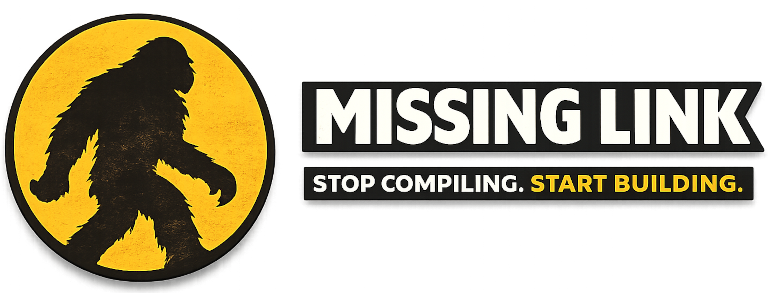

The **MissingLink Krea2 Studio Notebook** is a self-contained Krea2 image-generation Studio with a **15-generation free starter allowance**, Notebook Pro upgrade gating, Krea2 editing/inpainting, adaptive batches, and an H3-style LoRA installer.

### Access

1. **Start free** — get your free starter token when you sign up [here](https://missinglink.build/get-token?source=krea2-studio&model=krea2&placement=free-access) and store the issued starter code in Colab Secrets as `MISSING_LINK_TOKEN`. No card is required for the starter allowance.
2. Eligible starter accounts get **15 free Krea2 generations**. The allowance is server-side and does not reset when Colab restarts.
3. After the 15 free generations are used, new generations are blocked until the user starts **Notebook Pro with a 7-day free trial**. The Studio shows the remaining count and the upgrade action in the UI.
4. **Adaptive Batch counts each generated image as one generation.** A free account cannot start a batch larger than its remaining allowance.

### Colab secrets

- `MISSING_LINK_TOKEN` — required. Accepts the free Google-verified starter code or an existing paid MissingLink key.
- `OPENAI_API_KEY` — required by this Krea2 Studio build for Auto Prompt, adaptive planning/corrections, and captions.
- `HF_TOKEN` — optional; used for private/gated Hugging Face LoRAs and authenticated downloads.
- `CIVITAI_API_KEY` or `CIVITAI_TOKEN` — optional; only needed when the selected CivitAI resource requires authentication.

### Krea2 tools

**Text → Image**, **Image → Image**, **Instruction Edit**, **Inpaint**, **Adaptive Batch**, persistent **Queue + History**, random/fixed seeds, and optional **4-step acceleration** are retained.

### H3-style Add LoRA

Open **LORAS → + ADD LORA** and paste any of these:

- Hugging Face `owner/repo`
- a full Hugging Face repo/tree/blob/resolve URL
- a direct Hugging Face `.safetensors` file URL
- a CivitAI model page, version URL, or `/api/download/models/<versionId>` URL

The Studio inspects the source, lists available SafeTensors files, preselects the direct match when possible, downloads in the background with live byte/percentage/speed progress, validates the file, and adds it to the Krea2 user LoRA rack at strength **1.00** when there is room. Up to four user LoRAs can be active per queued job.

### Runtime

Connect to a **T4 or L4 GPU** and click **Run All**. L4 uses the higher-quality BF16 text encoder and larger defaults; T4 automatically switches to the lower-VRAM FP8 text encoder and 1024px defaults.

*Tip: Seeds default to random (`-1`). Restart the Colab runtime if you encounter persistent CUDA-memory issues.*


In [ ]:
# Cell 1 — MissingLink starter/Pro access + optional download credentials.
# Free starter code: https://missinglink.build/get-token?source=krea2-studio&model=krea2&placement=free-access

import os, shutil, subprocess
from google.colab import userdata

def _secret(name, required=False):
    try:
        value = userdata.get(name)
    except Exception:
        value = None
    if value:
        os.environ[name] = value
        return value
    if required:
        raise SystemExit(
            f"\n✗ {name} is not set in Colab Secrets.\n"
            "  Open the key icon in the left sidebar, add the secret, enable notebook access,\n"
            "  then rerun this cell."
        )
    return None

_ml = _secret("MISSING_LINK_TOKEN", required=True)
_openai = _secret("OPENAI_API_KEY", required=True)
_hf = _secret("HF_TOKEN")
_civ = _secret("CIVITAI_API_KEY")

# Hugging Face/Xet fast path used by model and LoRA downloads.
os.environ.pop("HF_HUB_DISABLE_XET", None)
os.environ["HF_XET_HIGH_PERFORMANCE"] = "1"

print("✓ MISSING_LINK_TOKEN loaded")
print("✓ OPENAI_API_KEY loaded")
if _hf:
    print("✓ HF_TOKEN loaded")
if _civ:
    print("✓ CIVITAI_API_KEY loaded from Colab Secrets")

try:
    gpu = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
        capture_output=True, text=True, timeout=8
    )
    line = (gpu.stdout or "").strip()
    print("✓ GPU:", line if line else "not visible — Runtime → Change runtime type → GPU")
except Exception:
    print("⚠ Could not query GPU yet.")

_free_gb = shutil.disk_usage("/content").free / 1e9
print(f"✓ Disk: {_free_gb:.0f} GB free")
print("\nCell 1 done. Run the next code cell to launch the updated Krea2 Studio.")


The cell below contains and launches the updated Krea2 Studio directly, including the free-15 access gate and H3-style Add LoRA flow.


In [ ]:
# =====================================================================
# MISSINGLINK KREA2 STUDIO — COMPLETE ONE-CELL COLAB
#
# Fresh-runtime compatible
#
# TABS
#   1. Text -> Image
#   2. Image -> Image
#   3. Inpaint
#   4. Adaptive Batch (1-50, live streaming, fully editable agent, Stop)
#   5. Image History
#
# ADAPTIVE BATCH
#   1. Choose 1-50 images and exact agent behavior/instructions
#   2. User instruction + optional reference image + CURRENT prompt table
#      -> customizable OpenAI Responses agent
#   3. The agent creates/refines the requested prompts when enabled
#   4. Generate image 1 and show it immediately
#   5. At each configured correction checkpoint the agent receives:
#        - original instruction
#        - original reference image
#        - actual generated image 1
#        - current prompt set
#   6. The agent revises remaining prompts at the chosen strength/frequency
#   7. Generate and display every remaining image one at a time
#   8. Stop interrupts the active ComfyUI sampler and keeps completed images
#
# MODEL
#   krea2-def.safetensors — MissingLink default Krea2 model
#
# GENERATION
#   8 steps / CFG 1 / Euler / Simple
#   Inpaint: Krea2 Identity Edit v1.2 + grounded instruction edit + masked focus composite
#
# OPENAI
#   User-selectable model, reasoning effort/mode, and token budget
#   multimodal image review
#
# REQUIRED COLAB SECRETS
#   MISSING_LINK_TOKEN
#   OPENAI_API_KEY
#
# OPTIONAL
#   HF_TOKEN
#   CIVITAI_API_KEY
#
# GPU
#   Auto-configures for NVIDIA T4 or L4
# =====================================================================

import os
import sys
import re
import time
import json
import shutil
import subprocess
import threading
from pathlib import Path

# =====================================================================
# CONFIG
# =====================================================================

ROOT = Path("/content")
COMFY_DIR = ROOT / "ComfyUI"
APP_PATH = ROOT / "missinglink_krea2_studio.py"
OUTPUT_DIR = ROOT / "missinglink_krea2_outputs"

MODEL_BUCKET_ID = "MissingLinkBuilder/Models"
MODEL_REMOTE_NAME = "krea2-def.safetensors"
MODEL_FILENAME = "krea2-def.safetensors"

HF_REPO = "Comfy-Org/Krea-2"

CLIP_BF16_REPO_FILE = "text_encoders/qwen3vl_4b_bf16.safetensors"
CLIP_BF16_FILENAME = "qwen3vl_4b_bf16.safetensors"
CLIP_FP8_REPO_FILE = "text_encoders/qwen3vl_4b_fp8_scaled.safetensors"
CLIP_FP8_FILENAME = "qwen3vl_4b_fp8_scaled.safetensors"
CLIP_REPO_FILE = CLIP_BF16_REPO_FILE
CLIP_FILENAME = CLIP_BF16_FILENAME

VAE_REPO_FILE = "vae/qwen_image_vae.safetensors"
VAE_FILENAME = "qwen_image_vae.safetensors"

LIGHTNING_HF_REPO = "lvladikov/Krea2-Turbo-Distill-4step-LoRA"
LIGHTNING_REPO_FILE = "krea2_turbo_4step_rank_64_lora_comfyui.safetensors"
LIGHTNING_FILENAME = "krea2_turbo_4step_rank_64_lora_comfyui.safetensors"

KREA2_EDIT_NODE_REPO = "https://github.com/lbouaraba/comfyui-krea2edit"
KREA2_EDIT_HF_REPO = "conradlocke/krea2-identity-edit"
KREA2_EDIT_FILE_FULL = "krea2_identity_edit_v1_2.safetensors"
KREA2_EDIT_FILE_R128 = "krea2_identity_edit_v1_2_r128.safetensors"
KREA2_EDIT_FILE_R64 = "krea2_identity_edit_v1_2_r64.safetensors"

# =====================================================================
# COLAB SECRETS
# =====================================================================

from google.colab import userdata


def required_secret(name):
    try:
        value = userdata.get(name)
    except Exception as e:
        raise RuntimeError(
            f"Missing Colab Secret: {name}\n"
            f"Add {name} using the key icon in the Colab sidebar."
        ) from e

    if not value:
        raise RuntimeError(f"Colab Secret {name} is empty.")

    return value


MISSING_LINK_TOKEN = required_secret("MISSING_LINK_TOKEN")
OPENAI_API_KEY = required_secret("OPENAI_API_KEY")

try:
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = None

try:
    # Match H3 Studio: the CivitAI credential comes from Colab userdata.
    # There is no browser/API-token field to fill in.
    CIVITAI_API_KEY = userdata.get("CIVITAI_API_KEY")
except Exception:
    CIVITAI_API_KEY = None

print("✓ MISSING_LINK_TOKEN loaded")
print("✓ OPENAI_API_KEY loaded")

if HF_TOKEN:
    print("✓ HF_TOKEN loaded")
if CIVITAI_API_KEY:
    print("✓ CIVITAI_API_KEY loaded from Colab Secrets")


# =====================================================================
# MISSINGLINK NOTEBOOK ACCESS · GOOGLE IDENTITY + 15 FREE KREA2 GENERATIONS
# =====================================================================
# MISSING_LINK_TOKEN may be either:
#   1) a Google-verified MissingLink Notebook starter code, or
#   2) an active paid/legacy MissingLink API key.
#
# Free Krea2 usage is counted server-side against the verified MissingLink user.
# Reopening Colab does not reset the allowance. After 15 free Krea2 generations,
# Notebook Pro is required; the upgrade flow starts with a 7-day free trial.
# =====================================================================

MISSING_LINK_BASE_URL = (
    os.environ.get("MISSING_LINK_BASE_URL")
    or "https://missinglink.build"
).rstrip("/")
MISSING_LINK_NOTEBOOK_ME_URL = (
    MISSING_LINK_BASE_URL + "/api/notebook/me?engine=krea2"
)
MISSING_LINK_AUTH_URL = (
    os.environ.get("MISSING_LINK_AUTH_URL")
    or MISSING_LINK_BASE_URL + "/api/cache-token"
).strip()
MISSING_LINK_SIGNIN_URL = (
    MISSING_LINK_BASE_URL
    + "/get-token?source=krea2-studio&model=krea2&placement=free-access"
)
MISSING_LINK_UPGRADE_URL = (
    MISSING_LINK_BASE_URL
    + "/notebook-pro/start?source=krea2-studio&model=krea2&placement=free-limit"
)
MISSING_LINK_TRIAL_URL = MISSING_LINK_UPGRADE_URL
KREA2_FREE_RENDER_LIMIT = 15
MISSINGLINK_ACCESS_CONTROL_SENTINEL = "ML-NOTEBOOK-FREE15-V1"

import urllib.request as _ml_urlreq
import urllib.error as _ml_urlerr

_ML_PARENT_AUTH_STATE = {
    "ok": False,
    "member": False,
    "email": "",
    "used": 0,
    "remaining": KREA2_FREE_RENDER_LIMIT,
    "access_mode": "",
    "error": "not checked",
}


def _ml_parent_headers(token):
    token = str(token or "").strip()
    headers = {
        "Accept": "application/json",
        "User-Agent": "MissingLink-Krea2-Notebook/15free",
    }
    if token:
        headers["Authorization"] = "Bearer " + token
        headers["x-api-key"] = token
    return headers


def _ml_parent_json_request(url, token, timeout=15):
    req = _ml_urlreq.Request(
        url,
        headers=_ml_parent_headers(token),
        method="GET",
    )
    with _ml_urlreq.urlopen(req, timeout=timeout) as resp:
        status = int(getattr(resp, "status", 200) or 200)
        raw = resp.read(262144)
    try:
        data = json.loads(raw.decode("utf-8", "replace")) if raw else {}
    except Exception:
        data = {}
    return status, data


def _ml_parent_apply_notebook_state(data):
    member = bool(data.get("member"))
    try:
        used = max(0, int(data.get("used") or 0))
    except Exception:
        used = 0
    _ML_PARENT_AUTH_STATE.update(
        ok=True,
        member=member,
        email=str(data.get("email") or ""),
        used=used,
        remaining=(-1 if member else max(0, KREA2_FREE_RENDER_LIMIT - used)),
        access_mode=(
            "gmail_starter"
            if data.get("starter")
            else ("notebook_google" if data.get("email") else "notebook_token")
        ),
        error="",
    )


def validate_missinglink_access(token):
    """Validate Notebook identity without consuming a Krea2 generation."""
    token = str(token or "").strip()
    if not token:
        msg = (
            "MISSING_LINK_TOKEN is not set. Get a free Google-verified starter code at "
            + MISSING_LINK_SIGNIN_URL
        )
        _ML_PARENT_AUTH_STATE.update(ok=False, error=msg)
        return False, msg

    notebook_error = ""
    try:
        status, data = _ml_parent_json_request(
            MISSING_LINK_NOTEBOOK_ME_URL,
            token,
            timeout=15,
        )
        if 200 <= status < 300 and data.get("ok") is True:
            _ml_parent_apply_notebook_state(data)
            return True, ""
        notebook_error = "Notebook identity was rejected."
    except _ml_urlerr.HTTPError as exc:
        notebook_error = f"Notebook identity was rejected (HTTP {exc.code})."
    except Exception as exc:
        notebook_error = (
            "Notebook identity check failed: "
            f"{type(exc).__name__}: {exc}"
        )

    # Compatibility path for existing paid/legacy API keys.
    try:
        status, data = _ml_parent_json_request(
            MISSING_LINK_AUTH_URL,
            token,
            timeout=15,
        )
        if 200 <= status < 300 and isinstance(data, dict) and data.get("ok") is True:
            _ML_PARENT_AUTH_STATE.update(
                ok=True,
                member=True,
                email="",
                used=0,
                remaining=-1,
                access_mode="legacy_paid_api_key",
                error="",
            )
            return True, ""
    except Exception:
        pass

    _ML_PARENT_AUTH_STATE.update(ok=False, error=notebook_error)
    return False, notebook_error


def _require_parent_notebook_access():
    ok, error = validate_missinglink_access(MISSING_LINK_TOKEN)
    if not ok:
        raise RuntimeError(
            "MissingLink notebook sign-in is required before this notebook can run.\n"
            + (error or "Identity validation failed.")
            + "\nGet 15 free Krea2 generations (no card required): "
            + MISSING_LINK_SIGNIN_URL
        )

    state = dict(_ML_PARENT_AUTH_STATE)
    if not state.get("member") and int(state.get("remaining") or 0) <= 0:
        raise RuntimeError(
            f"Your {KREA2_FREE_RENDER_LIMIT} free Krea2 generations are complete.\n"
            "Start the 7-day Notebook Pro trial to keep generating and unlock "
            "the full MissingLink notebook library.\n"
            + MISSING_LINK_UPGRADE_URL
        )

    if state.get("member"):
        print("✓ MissingLink Notebook Pro verified · unlimited Krea2 generations")
    else:
        print(
            "✓ MissingLink starter verified · "
            f"{state.get('remaining', KREA2_FREE_RENDER_LIMIT)} of "
            f"{KREA2_FREE_RENDER_LIMIT} free Krea2 generations remaining"
        )
    return state


# ACCESS CHECKPOINT A — before CUDA/model downloads.
_ML_PARENT_ACCESS = _require_parent_notebook_access()

# =====================================================================
# STOP OLD APPLICATIONS
# =====================================================================

print("\nStopping old application processes...")

for pattern in [
    "missinglink_krea2_studio.py",
    "app_multimode.py",
]:
    subprocess.run(
        ["pkill", "-f", pattern],
        check=False,
    )

time.sleep(2)

# =====================================================================
# GPU / CUDA
# =====================================================================

smi = subprocess.run(
    ["nvidia-smi"],
    capture_output=True,
    text=True,
)

if smi.returncode != 0:
    raise RuntimeError(
        "No NVIDIA GPU detected.\n"
        "Colab -> Runtime -> Change runtime type -> GPU"
    )

cuda_match = re.search(
    r"CUDA Version:\s*([0-9.]+)",
    smi.stdout,
)

DRIVER_CUDA = (
    cuda_match.group(1)
    if cuda_match
    else "unknown"
)

print("\n✓ NVIDIA GPU detected")
print("Driver CUDA capability:", DRIVER_CUDA)

gpu_query = subprocess.run(
    ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader,nounits"],
    capture_output=True, text=True, check=False,
)
GPU_BOOT_NAME = ""
GPU_BOOT_VRAM_MIB = 0
if gpu_query.returncode == 0 and gpu_query.stdout.strip():
    first = gpu_query.stdout.strip().splitlines()[0]
    parts = [x.strip() for x in first.rsplit(",", 1)]
    GPU_BOOT_NAME = parts[0]
    try:
        GPU_BOOT_VRAM_MIB = int(float(parts[1]))
    except Exception:
        GPU_BOOT_VRAM_MIB = 0

GPU_BOOT_NAME_UPPER = (GPU_BOOT_NAME or "").upper()
if "L4" in GPU_BOOT_NAME_UPPER:
    GPU_PROFILE = "l4"
elif re.search(r"(^|[^A-Z0-9])T4([^A-Z0-9]|$)", GPU_BOOT_NAME_UPPER):
    GPU_PROFILE = "t4"
else:
    GPU_PROFILE = "t4" if (GPU_BOOT_VRAM_MIB and GPU_BOOT_VRAM_MIB <= 17_000) else "l4"

PROFILE_DEFAULTS = {
    "t4": {
        "low_vram_mode": True,
        "clip_repo_file": CLIP_FP8_REPO_FILE,
        "clip_filename": CLIP_FP8_FILENAME,
        "text_width": 1024,
        "text_height": 1024,
        "image_max_side": 1024,
        "inpaint_max_side": 1024,
        "batch_width": 1024,
        "batch_height": 1024,
    },
    "l4": {
        "low_vram_mode": False,
        "clip_repo_file": CLIP_BF16_REPO_FILE,
        "clip_filename": CLIP_BF16_FILENAME,
        "text_width": 1536,
        "text_height": 1024,
        "image_max_side": 1536,
        "inpaint_max_side": 1536,
        "batch_width": 1536,
        "batch_height": 1024,
    },
}
ACTIVE_PROFILE = PROFILE_DEFAULTS[GPU_PROFILE]
LOW_VRAM_MODE = ACTIVE_PROFILE["low_vram_mode"]
CLIP_REPO_FILE = ACTIVE_PROFILE["clip_repo_file"]
CLIP_FILENAME = ACTIVE_PROFILE["clip_filename"]
DEFAULTS = {
    "text_width": ACTIVE_PROFILE["text_width"],
    "text_height": ACTIVE_PROFILE["text_height"],
    "image_max_side": ACTIVE_PROFILE["image_max_side"],
    "inpaint_max_side": ACTIVE_PROFILE["inpaint_max_side"],
    "batch_width": ACTIVE_PROFILE["batch_width"],
    "batch_height": ACTIVE_PROFILE["batch_height"],
}

print("GPU:", GPU_BOOT_NAME or "unknown")
if GPU_BOOT_VRAM_MIB:
    print(f"VRAM: {GPU_BOOT_VRAM_MIB / 1024:.1f} GiB")
print("Auto profile:", GPU_PROFILE.upper())
print("Text encoder:", CLIP_FILENAME, "(low-VRAM mode)" if LOW_VRAM_MODE else "(quality mode)")
print("Default canvas:", f'{DEFAULTS["text_width"]}x{DEFAULTS["text_height"]}')

if GPU_PROFILE == "t4":
    KREA2_EDIT_REPO_FILE = KREA2_EDIT_FILE_R64
elif LOW_VRAM_MODE:
    KREA2_EDIT_REPO_FILE = KREA2_EDIT_FILE_R128
else:
    KREA2_EDIT_REPO_FILE = KREA2_EDIT_FILE_R128

KREA2_EDIT_FILENAME = Path(KREA2_EDIT_REPO_FILE).name
print("Identity edit LoRA:", KREA2_EDIT_FILENAME)

# =====================================================================
# COMFYUI
# =====================================================================

if not COMFY_DIR.exists():

    print("\nCloning ComfyUI...")

    subprocess.check_call([
        "git",
        "clone",
        "--depth",
        "1",
        "https://github.com/Comfy-Org/ComfyUI.git",
        str(COMFY_DIR),
    ])

else:

    print("\nUpdating ComfyUI...")

    subprocess.run(
        ["git", "pull", "--ff-only"],
        cwd=str(COMFY_DIR),
        check=False,
    )

# =====================================================================
# DEPENDENCIES
# =====================================================================

print("\nInstalling ComfyUI requirements...")

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "-r",
    str(COMFY_DIR / "requirements.txt"),
])


def numeric_version(value):
    """Return a tuple suitable for comparing CUDA version strings."""
    return tuple(
        int(part)
        for part in re.findall(r"\d+", value or "")
    )


def installed_torch_cuda():
    result = subprocess.run(
        [
            sys.executable,
            "-c",
            "import torch; print(torch.version.cuda or '')",
        ],
        capture_output=True,
        text=True,
        check=False,
    )
    return result.stdout.strip() if result.returncode == 0 else ""


# Current ComfyUI builds require a CUDA 13.0 PyTorch wheel on modern NVIDIA
# GPUs. Colab can retain an older cu12x wheel even when the driver supports
# CUDA 13, which disables optimized CUDA operations.
TORCH_CUDA = installed_torch_cuda()

if (
    numeric_version(DRIVER_CUDA) >= (13, 0)
    and numeric_version(TORCH_CUDA) < (13, 0)
):
    print(
        "Updating PyTorch from CUDA "
        f"{TORCH_CUDA or 'unknown'} to CUDA 13.0..."
    )
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade",
        "torch",
        "torchvision",
        "torchaudio",
        "--extra-index-url",
        "https://download.pytorch.org/whl/cu130",
    ])

    TORCH_CUDA = installed_torch_cuda()
    if numeric_version(TORCH_CUDA) < (13, 0):
        raise RuntimeError(
            "PyTorch CUDA 13.0 installation did not succeed; "
            f"detected torch CUDA {TORCH_CUDA or 'unknown'}."
        )

    print("✓ PyTorch CUDA:", TORCH_CUDA)

print("Installing/updating application packages...")

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade",
    "flask>=3,<4",
    "openai",
    "requests",
    "tqdm",
    "Pillow",
    "numpy",
    "huggingface_hub[hf_xet]>=1.6.0,<2.0",
    "comfy-kitchen",
])

# =====================================================================
# MODEL PATHS
# =====================================================================

DIFFUSION_DIR = COMFY_DIR / "models" / "diffusion_models"
TEXT_ENCODER_DIR = COMFY_DIR / "models" / "text_encoders"
VAE_DIR = COMFY_DIR / "models" / "vae"
LORA_DIR = COMFY_DIR / "models" / "loras"
CUSTOM_NODES_DIR = COMFY_DIR / "custom_nodes"
KREA2_EDIT_NODE_DIR = CUSTOM_NODES_DIR / "comfyui-krea2edit"

for directory in [
    DIFFUSION_DIR,
    TEXT_ENCODER_DIR,
    VAE_DIR,
    LORA_DIR,
    CUSTOM_NODES_DIR,
    OUTPUT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

MODEL_PATH = DIFFUSION_DIR / MODEL_FILENAME

# =====================================================================
# RECOVER EXISTING CANONICAL MODEL
# =====================================================================

if not MODEL_PATH.exists():

    old_locations = [
        COMFY_DIR / "models" / "unet" / MODEL_FILENAME,
    ]

    for old_path in old_locations:
        if old_path.exists():
            print("\nRecovering existing krea2-def checkpoint:")
            print(old_path)
            shutil.copy2(old_path, MODEL_PATH)
            break

# =====================================================================
# KREA2 DEFAULT MODEL — BUCKET / HUGGING FACE
# =====================================================================

from huggingface_hub import download_bucket_files, hf_hub_download
from safetensors import safe_open
import requests


def validate_safetensors(path, minimum_size):
    """Validate the full safetensors layout without loading tensor data."""
    path = Path(path)

    if not path.is_file():
        return False, "file is missing"

    size = path.stat().st_size
    if size < minimum_size:
        return False, f"file is unexpectedly small ({size:,} bytes)"

    try:
        with safe_open(
            str(path),
            framework="pt",
            device="cpu",
        ) as handle:
            if not list(handle.keys()):
                return False, "file contains no tensors"
    except Exception as exc:
        return False, f"invalid safetensors file: {exc}"

    return True, "ok"


def ensure_model_safetensors(
    destination,
    minimum_size,
    label,
):
    """Download krea2-def from the public MissingLink Hugging Face Bucket."""
    destination = Path(destination)
    valid, reason = validate_safetensors(destination, minimum_size)

    if valid:
        print(f"✓ {label} already present and valid")
        print(destination)
        return

    if destination.exists():
        print(f"! Replacing invalid {label}: {reason}")
        destination.unlink()
    else:
        print(f"Downloading {label} from MissingLink public bucket...")

    destination.parent.mkdir(parents=True, exist_ok=True)
    partial = destination.with_name(destination.name + ".part")
    partial.unlink(missing_ok=True)

    print(f"Bucket : hf://buckets/{MODEL_BUCKET_ID}")
    print(f"Object : {MODEL_REMOTE_NAME}")

    # Hugging Face Buckets are NOT model repositories. The correct Python API is
    # download_bucket_files(); do not use hf_hub_download() or /resolve/main.
    # Public bucket access is deliberately anonymous (token=False).
    try:
        download_bucket_files(
            MODEL_BUCKET_ID,
            files=[(MODEL_REMOTE_NAME, str(partial))],
            raise_on_missing_files=True,
            token=False,
        )
    except Exception as bucket_exc:
        # Robust public HTTP fallback. Bucket file URLs have no revision segment:
        # /buckets/<namespace>/<bucket>/resolve/<path>
        partial.unlink(missing_ok=True)
        public_url = (
            f"https://huggingface.co/buckets/{MODEL_BUCKET_ID}/resolve/"
            f"{MODEL_REMOTE_NAME}"
        )
        print(
            "! Native bucket API failed; retrying the canonical public bucket URL:\n"
            f"  {public_url}\n"
            f"  API error: {type(bucket_exc).__name__}: {bucket_exc}"
        )

        try:
            with requests.get(
                public_url,
                stream=True,
                allow_redirects=True,
                timeout=(30, 300),
                headers={"User-Agent": "MissingLink-Krea2-Colab/1.0"},
            ) as response:
                response.raise_for_status()
                with open(partial, "wb") as handle:
                    for chunk in response.iter_content(chunk_size=8 * 1024 * 1024):
                        if chunk:
                            handle.write(chunk)
        except Exception:
            partial.unlink(missing_ok=True)
            raise

    valid, reason = validate_safetensors(partial, minimum_size)
    if not valid:
        partial.unlink(missing_ok=True)
        raise RuntimeError(
            f"Bucket download failed safetensors validation: {reason}"
        )

    os.replace(partial, destination)
    print(f"✓ {label} downloaded from MissingLink public bucket")
    print(destination)

def ensure_git_checkout(repo_url, destination):
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)

    if (destination / ".git").exists():
        print(f"Updating {destination.name} custom nodes...")
        subprocess.run(["git", "-C", str(destination), "fetch", "--depth", "1", "origin", "main"], check=False)
        reset = subprocess.run(
            ["git", "-C", str(destination), "reset", "--hard", "origin/main"],
            text=True,
            capture_output=True,
        )
        if reset.returncode != 0:
            raise RuntimeError(
                f"Could not update {destination.name}: {reset.stderr or reset.stdout}"
            )
        return

    if destination.exists():
        shutil.rmtree(destination, ignore_errors=True)

    print(f"Cloning {destination.name} custom nodes...")
    clone = subprocess.run(
        ["git", "clone", "--depth", "1", repo_url, str(destination)],
        text=True,
        capture_output=True,
    )
    if clone.returncode != 0:
        raise RuntimeError(
            f"Could not clone {repo_url}: {clone.stderr or clone.stdout}"
        )


def ensure_hf_safetensors(
    repo_id,
    repo_file,
    destination,
    minimum_size,
    label,
):
    """Keep a validated destination, otherwise repair it atomically."""
    destination = Path(destination)
    valid, reason = validate_safetensors(
        destination,
        minimum_size,
    )

    if valid:
        print(f"✓ {label} already present and valid")
        print(destination)
        return

    if destination.exists():
        print(f"! Replacing invalid {label}: {reason}")
        destination.unlink()
    else:
        print(f"Downloading {label}...")

    # First allow Hugging Face to reuse a valid cached blob. If that cache is
    # itself incomplete, force a clean download instead of copying corruption
    # back into the ComfyUI model directory.
    downloaded = Path(
        hf_hub_download(
            repo_id=repo_id,
            filename=repo_file,
            token=HF_TOKEN,
        )
    )

    valid, reason = validate_safetensors(
        downloaded,
        minimum_size,
    )

    if not valid:
        print(f"! Cached download is invalid ({reason}); downloading again...")
        downloaded = Path(
            hf_hub_download(
                repo_id=repo_id,
                filename=repo_file,
                token=HF_TOKEN,
                force_download=True,
            )
        )
        valid, reason = validate_safetensors(
            downloaded,
            minimum_size,
        )

    if not valid:
        raise RuntimeError(
            f"Downloaded {label} failed validation: {reason}"
        )

    partial = destination.with_name(destination.name + ".part")
    partial.unlink(missing_ok=True)

    try:
        shutil.copy2(downloaded, partial)
        valid, reason = validate_safetensors(
            partial,
            minimum_size,
        )
        if not valid:
            raise RuntimeError(
                f"Copied {label} failed validation: {reason}"
            )
        os.replace(partial, destination)
    finally:
        partial.unlink(missing_ok=True)

    print(f"✓ {label} downloaded and validated")
    print(destination)


print()
print("Installing/updating ComfyUI-Krea2Edit custom nodes...")
ensure_git_checkout(
    KREA2_EDIT_NODE_REPO,
    KREA2_EDIT_NODE_DIR,
)

print()
print("=" * 72)
print("VALIDATING MODEL FILES")
print("=" * 72)

ensure_model_safetensors(
    MODEL_PATH,
    1_000_000_000,
    "Krea2 default model",
)

ensure_hf_safetensors(
    HF_REPO,
    CLIP_REPO_FILE,
    TEXT_ENCODER_DIR / CLIP_FILENAME,
    1_000_000_000,
    "Qwen text encoder",
)

ensure_hf_safetensors(
    HF_REPO,
    VAE_REPO_FILE,
    VAE_DIR / VAE_FILENAME,
    100_000_000,
    "Qwen VAE",
)

ensure_hf_safetensors(
    LIGHTNING_HF_REPO,
    LIGHTNING_REPO_FILE,
    LORA_DIR / LIGHTNING_FILENAME,
    10_000_000,
    "Krea2 Turbo 4-step acceleration LoRA",
)

ensure_hf_safetensors(
    KREA2_EDIT_HF_REPO,
    KREA2_EDIT_REPO_FILE,
    LORA_DIR / KREA2_EDIT_FILENAME,
    100_000_000,
    "Krea2 Identity Edit v1.2 LoRA",
)

# =====================================================================
# WRITE COMPLETE MISSINGLINK CUSTOM APP
# =====================================================================

APP_CODE = r'''
import os
import sys
import gc
import io
import re
import json
import time
import uuid
import base64
import random
import zipfile
import threading
import queue
import shutil
from collections import deque

from pathlib import Path
from datetime import datetime
from urllib.parse import urlparse

import requests
from huggingface_hub import hf_hub_download, HfApi
from safetensors import safe_open

# =====================================================================
# BROWSER CONSOLE CAPTURE
# =====================================================================
# Tee stdout/stderr to their original process pipes AND a bounded in-memory
# buffer exposed by /api/console. This captures ComfyUI/Krea2Edit diagnostics,
# tracebacks, model load messages and our own generation logs without hiding
# anything from the Colab cell output.
_CONSOLE_LOCK = threading.RLock()
_CONSOLE_CHUNKS = deque(maxlen=20000)


class _ConsoleTee:
    def __init__(self, base, stream_name):
        self.base = base
        self.stream_name = stream_name

    def write(self, value):
        value = str(value or "")
        if not value:
            return 0
        try:
            self.base.write(value)
        except Exception:
            pass
        with _CONSOLE_LOCK:
            _CONSOLE_CHUNKS.append(value)
        return len(value)

    def flush(self):
        try:
            self.base.flush()
        except Exception:
            pass

    def isatty(self):
        try:
            return self.base.isatty()
        except Exception:
            return False

    @property
    def encoding(self):
        return getattr(self.base, "encoding", "utf-8")


sys.stdout = _ConsoleTee(sys.stdout, "stdout")
sys.stderr = _ConsoleTee(sys.stderr, "stderr")


def _console_text(limit_chars=300000):
    with _CONSOLE_LOCK:
        value = "".join(_CONSOLE_CHUNKS)
    if len(value) > int(limit_chars):
        value = value[-int(limit_chars):]
    return value


ROOT = Path("/content")
COMFY = ROOT / "ComfyUI"
OUTPUT_DIR = ROOT / "missinglink_krea2_outputs"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if str(COMFY) not in sys.path:
    sys.path.insert(0, str(COMFY))

os.chdir(str(COMFY))

# =====================================================================
# COMFY CLI OPTIONS
# =====================================================================

import comfy.options
comfy.options.enable_args_parsing()

# =====================================================================
# TORCH / GPU
# =====================================================================

import torch
import numpy as np

from PIL import Image, ImageFilter
from PIL.PngImagePlugin import PngInfo

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU unavailable.")

try:
    torch.backends.cuda.matmul.allow_tf32 = True
except Exception:
    pass

try:
    torch.backends.cudnn.allow_tf32 = True
except Exception:
    pass

try:
    torch.backends.cuda.enable_flash_sdp(True)
    torch.backends.cuda.enable_mem_efficient_sdp(True)
    torch.backends.cuda.enable_math_sdp(True)
except Exception:
    pass

torch.set_float32_matmul_precision("high")

GPU_NAME = torch.cuda.get_device_name(0)

VRAM_GB = (
    torch.cuda.get_device_properties(0).total_memory
    / 1024**3
)

print()
print("=" * 76)
print("MISSINGLINK KREA2 STUDIO")
print("=" * 76)
print("GPU:", GPU_NAME)
print(f"VRAM: {VRAM_GB:.1f} GB")
print("Torch:", torch.__version__)
print("Torch CUDA:", torch.version.cuda)
print("=" * 76)

# =====================================================================
# COMFYUI
# =====================================================================

import asyncio
import inspect
import nodes
import folder_paths
import comfy.model_management as model_management

# Load only the Krea2Edit custom node package. The Studio uses ComfyUI as a
# Python model/runtime library and does not run ComfyUI's own PromptServer.
# This deliberately avoids PromptServer/AssetManager API churn across ComfyUI
# releases while still registering Krea2EditModelPatch/GroundedEncode.
_async_loop = asyncio.new_event_loop()
asyncio.set_event_loop(_async_loop)
_KREA2_EDIT_NODE_PATH = COMFY / "custom_nodes" / "comfyui-krea2edit"
if not _KREA2_EDIT_NODE_PATH.is_dir():
    raise RuntimeError(
        "ComfyUI-Krea2Edit custom nodes are missing at "
        + str(_KREA2_EDIT_NODE_PATH)
    )
_load_result = nodes.load_custom_node(
    str(_KREA2_EDIT_NODE_PATH),
    set(),
    module_parent="custom_nodes",
)
if inspect.isawaitable(_load_result):
    _krea2edit_loaded = bool(_async_loop.run_until_complete(_load_result))
else:
    _krea2edit_loaded = bool(_load_result)
if not _krea2edit_loaded:
    raise RuntimeError("ComfyUI-Krea2Edit custom nodes failed to import.")

UNETLoader = nodes.UNETLoader
CLIPLoader = nodes.CLIPLoader
VAELoader = nodes.VAELoader
CLIPTextEncode = nodes.CLIPTextEncode
ConditioningZeroOut = nodes.ConditioningZeroOut
EmptyLatentImage = nodes.EmptyLatentImage
VAEEncode = nodes.VAEEncode
SetLatentNoiseMask = nodes.SetLatentNoiseMask
KSampler = nodes.KSampler
VAEDecode = nodes.VAEDecode
LoraLoaderModelOnly = nodes.LoraLoaderModelOnly

if "Krea2EditModelPatch" not in nodes.NODE_CLASS_MAPPINGS or "Krea2EditGroundedEncode" not in nodes.NODE_CLASS_MAPPINGS:
    raise RuntimeError(
        "ComfyUI-Krea2Edit custom nodes did not load. "
        "Ensure ComfyUI/custom_nodes/comfyui-krea2edit is present and restart the app."
    )
print("[BOOT] ComfyUI-Krea2Edit nodes loaded", flush=True)

MODEL_NAME = "krea2-def.safetensors"
CLIP_NAME = "__CLIP_FILENAME__"
VAE_NAME = "qwen_image_vae.safetensors"
LIGHTNING_LORA_NAME = "krea2_turbo_4step_rank_64_lora_comfyui.safetensors"
EDIT_LORA_NAME = "__EDIT_LORA_FILENAME__"
LOW_VRAM_MODE = __LOW_VRAM_MODE__
GPU_PROFILE = "__GPU_PROFILE__"
DEFAULT_TEXT_WIDTH = __DEFAULT_TEXT_WIDTH__
DEFAULT_TEXT_HEIGHT = __DEFAULT_TEXT_HEIGHT__
DEFAULT_IMAGE_MAX_SIDE = __DEFAULT_IMAGE_MAX_SIDE__
DEFAULT_INPAINT_MAX_SIDE = __DEFAULT_INPAINT_MAX_SIDE__
DEFAULT_BATCH_WIDTH = __DEFAULT_BATCH_WIDTH__
DEFAULT_BATCH_HEIGHT = __DEFAULT_BATCH_HEIGHT__

for category, filename in [
    ("diffusion_models", MODEL_NAME),
    ("text_encoders", CLIP_NAME),
    ("vae", VAE_NAME),
    ("loras", LIGHTNING_LORA_NAME),
    ("loras", EDIT_LORA_NAME),
]:

    resolved = folder_paths.get_full_path_or_raise(
        category,
        filename,
    )

    print(
        f"[MODEL] {category}: {resolved}",
        flush=True,
    )

# =====================================================================
# LOAD MODEL OBJECTS
# =====================================================================

print("\n[BOOT] Creating UNet...", flush=True)

UNET = UNETLoader().load_unet(
    unet_name=MODEL_NAME,
    weight_dtype="default",
)[0]

print("[BOOT] UNet ready", flush=True)

print("[BOOT] Creating Qwen text encoder...", flush=True)

CLIP = CLIPLoader().load_clip(
    clip_name=CLIP_NAME,
    type="krea2",
)[0]

print("[BOOT] CLIP ready", flush=True)

print("[BOOT] Creating VAE...", flush=True)

VAE = VAELoader().load_vae(
    vae_name=VAE_NAME,
)[0]

print("[BOOT] VAE ready", flush=True)

TEXT_ENCODER = CLIPTextEncode()
ZERO_OUT = ConditioningZeroOut()

EMPTY_LATENT = EmptyLatentImage()

VAE_ENCODER = VAEEncode()
NOISE_MASK = SetLatentNoiseMask()

SAMPLER = KSampler()
VAE_DECODER = VAEDecode()
LIGHTNING_LOADER = LoraLoaderModelOnly()
EDIT_LOADER = LoraLoaderModelOnly()
KREA2_EDIT_PATCH = nodes.NODE_CLASS_MAPPINGS["Krea2EditModelPatch"]()
KREA2_EDIT_GROUNDED = nodes.NODE_CLASS_MAPPINGS["Krea2EditGroundedEncode"]()

STEPS = 8
CFG = 1.0

# =====================================================================
# USER LoRA LIBRARY / STACK
# =====================================================================
# Only SafeTensors files are accepted. Pickle/checkpoint formats are rejected.
# The active stack is snapshotted into each submitted job so queued jobs keep
# the LoRA configuration they were created with even if the user changes the
# global stack later.
LORA_DIR_RUNTIME = COMFY / "models" / "loras"
LORA_DIR_RUNTIME.mkdir(parents=True, exist_ok=True)
RESERVED_LORAS = {LIGHTNING_LORA_NAME, EDIT_LORA_NAME}
MAX_USER_LORAS_PER_JOB = 4
MAX_USER_LORA_BYTES = 4 * 1024**3
_EXTRA_LORA_LOCK = threading.RLock()
ACTIVE_EXTRA_LORAS = []


def _safe_lora_name(value):
    name = Path(str(value or "")).name
    if not name or name in {".", ".."}:
        raise ValueError("Invalid LoRA filename.")
    if not name.lower().endswith(".safetensors"):
        raise ValueError("Only .safetensors LoRAs are supported.")
    return name


def _validate_safetensors_payload(path):
    """Validate SafeTensors CONTENT regardless of a temporary filename suffix.

    Downloads are written atomically to names such as
    ``foo.safetensors.<job>.part``. Checking Path.suffix on those temporary
    files incorrectly reports "only .safetensors files are allowed" even when
    the downloaded payload is a perfectly valid SafeTensors LoRA.
    """
    path = Path(path)
    if not path.is_file():
        return False, "file is missing"
    size = path.stat().st_size
    if size < 4096:
        return False, "file is unexpectedly small"
    if size > MAX_USER_LORA_BYTES:
        return False, "file is larger than the 4 GiB Studio limit"
    try:
        with safe_open(str(path), framework="pt", device="cpu") as handle:
            if not list(handle.keys()):
                return False, "SafeTensors file contains no tensors"
    except Exception as exc:
        return False, f"invalid SafeTensors file: {exc}"
    return True, "ok"


def _validate_user_lora_file(path):
    """Validate an installed user LoRA and require the final .safetensors name."""
    path = Path(path)
    if path.suffix.lower() != ".safetensors":
        return False, "only .safetensors files are allowed"
    return _validate_safetensors_payload(path)


def _installed_user_loras():
    rows = []
    with _EXTRA_LORA_LOCK:
        active = {str(item.get("name")): float(item.get("strength", 1.0)) for item in ACTIVE_EXTRA_LORAS}
    for path in sorted(LORA_DIR_RUNTIME.glob("*.safetensors"), key=lambda x: x.name.lower()):
        valid, reason = _validate_user_lora_file(path)
        rows.append({
            "name": path.name,
            "bytes": path.stat().st_size if path.exists() else 0,
            "reserved": path.name in RESERVED_LORAS,
            "valid": bool(valid),
            "validation": reason,
            "active": path.name in active,
            "strength": active.get(path.name, 1.0),
        })
    return rows


def _normalize_extra_loras(value):
    if value is None:
        return []
    if isinstance(value, str):
        try:
            value = json.loads(value)
        except Exception:
            value = []
    if not isinstance(value, (list, tuple)):
        return []
    out = []
    seen = set()
    for item in value:
        if not isinstance(item, dict):
            continue
        try:
            name = _safe_lora_name(item.get("name"))
        except Exception:
            continue
        if name in RESERVED_LORAS or name in seen:
            continue
        path = LORA_DIR_RUNTIME / name
        valid, _ = _validate_user_lora_file(path)
        if not valid:
            continue
        try:
            strength = float(item.get("strength", 1.0))
        except Exception:
            strength = 1.0
        strength = max(-2.0, min(2.0, strength))
        out.append({"name": name, "strength": strength})
        seen.add(name)
        if len(out) >= MAX_USER_LORAS_PER_JOB:
            break
    return out


def _apply_extra_loras(model, extra_loras=None):
    active = _normalize_extra_loras(extra_loras)
    for item in active:
        print(f"[LORA] applying {item['name']} @ {item['strength']:g}", flush=True)
        model = LIGHTNING_LOADER.load_lora_model_only(
            model,
            item["name"],
            item["strength"],
        )[0]
    return model


def generation_model(lightning_enabled=False, lightning_strength=1.0, extra_loras=None):
    model = UNET
    if lightning_enabled:
        strength = max(0.0, min(1.5, float(lightning_strength)))
        model = LIGHTNING_LOADER.load_lora_model_only(
            model, LIGHTNING_LORA_NAME, strength
        )[0]
    return _apply_extra_loras(model, extra_loras)


def identity_edit_model(
    lightning_enabled=False,
    lightning_strength=1.0,
    edit_lora_strength=1.0,
    extra_loras=None,
):
    model = UNET
    if lightning_enabled:
        strength = max(0.0, min(1.5, float(lightning_strength)))
        model = LIGHTNING_LOADER.load_lora_model_only(
            model, LIGHTNING_LORA_NAME, strength
        )[0]
    edit_strength = max(0.0, min(1.5, float(edit_lora_strength)))
    model = EDIT_LOADER.load_lora_model_only(
        model,
        EDIT_LORA_NAME,
        edit_strength,
    )[0]
    return _apply_extra_loras(model, extra_loras)

SAMPLER_NAME = "euler"
SCHEDULER = "simple"

MAX_SEED = 2**48 - 1

OPENAI_MODEL = "gpt-5.6"

# =====================================================================
# COOPERATIVE + NATIVE COMFYUI INTERRUPTION
# =====================================================================


class BatchStopped(Exception):
    pass


STOP_EVENT = threading.Event()


def reset_stop():

    STOP_EVENT.clear()

    try:
        model_management.interrupt_current_processing(False)
    except Exception:
        pass


def check_stop():

    if STOP_EVENT.is_set():
        raise BatchStopped("Generation stopped by user.")


def request_stop():

    STOP_EVENT.set()

    try:
        model_management.interrupt_current_processing(True)
    except Exception as e:
        print(
            "[STOP] ComfyUI interrupt warning:",
            repr(e),
            flush=True,
        )

    print(
        "[STOP] Stop requested. Interrupting the active sampler...",
        flush=True,
    )

    return (
        "Stop requested. The current sampler is being interrupted; "
        "completed images are preserved."
    )


# =====================================================================
# SHARED JOB PROGRESS HOOKS
# =====================================================================

CURRENT_JOB_ID = None


def _current_job():
    jid = globals().get("CURRENT_JOB_ID")
    jobs = globals().get("JOBS") or {}
    return jobs.get(jid) if jid else None


def _emit_progress(stage=None, pct=None, step=None, step_total=None, detail=None):
    """Publish live stage/step progress into the unified MissingLink queue."""
    jid = globals().get("CURRENT_JOB_ID")
    jobs = globals().get("JOBS")
    lock = globals().get("JOB_LOCK")
    if not jid or jobs is None or lock is None:
        return

    with lock:
        job = jobs.get(jid)
        if not job:
            return

        if stage is not None:
            job["stage"] = str(stage)
            if step is None and not str(stage).lower().startswith("sampling"):
                job["step"] = 0
        if detail is not None:
            job["detail"] = str(detail)
        if step is not None:
            job["step"] = int(step)
        if step_total is not None:
            job["step_total"] = int(step_total)

        if pct is not None:
            local_pct = max(0.0, min(100.0, float(pct)))
            # A batch is one queued job containing N sequential generations.
            # Convert each image's local 0..100% into whole-job progress.
            if job.get("kind") == "batch" and int(job.get("batch_total") or 0) > 0:
                total = max(1, int(job.get("batch_total") or 1))
                done = max(0, min(total, int(job.get("batch_current") or 0)))
                overall = ((done + local_pct / 100.0) / total) * 100.0
                job["progress"] = max(float(job.get("progress") or 0.0), min(99.0, overall))
            else:
                job["progress"] = max(float(job.get("progress") or 0.0), local_pct)
        job["updated"] = time.time()


def _comfy_progress_hook(*args, **kwargs):
    try:
        value = args[0] if len(args) > 0 else kwargs.get("value")
        total = args[1] if len(args) > 1 else kwargs.get("total")
        value = int(value or 0)
        total = max(1, int(total or STEPS))
        shown = max(1, min(total, value))
        local_pct = 24.0 + min(1.0, max(0.0, float(value) / float(total))) * 58.0
        _emit_progress(
            stage=f"Sampling · step {shown}/{total}",
            pct=local_pct,
            step=shown,
            step_total=total,
        )
    except Exception:
        pass


try:
    import comfy.utils as _comfy_utils
    if hasattr(_comfy_utils, "set_progress_bar_global_hook"):
        _comfy_utils.set_progress_bar_global_hook(_comfy_progress_hook)
except Exception as _progress_hook_error:
    print("[progress] Comfy progress hook unavailable:", repr(_progress_hook_error), flush=True)

# =====================================================================
# MEMORY
# =====================================================================


def unload_models():

    try:
        model_management.unload_all_models()
    except Exception as e:
        print(
            "[memory] unload warning:",
            repr(e),
            flush=True,
        )

    try:
        model_management.soft_empty_cache()
    except Exception:
        pass

    gc.collect()

    try:
        torch.cuda.empty_cache()
    except Exception:
        pass


def gpu_stats(label):

    try:
        free, total = torch.cuda.mem_get_info()
        used = total - free

        print(
            f"[GPU:{label}] "
            f"{used / 1024**3:.2f}/"
            f"{total / 1024**3:.2f} GiB",
            flush=True,
        )
    except Exception:
        pass

# =====================================================================
# UNIQUE SAVE / HISTORY
# =====================================================================


def unique_stem(mode, seed):

    timestamp = datetime.now().strftime(
        "%Y%m%d_%H%M%S_%f"
    )

    uid = uuid.uuid4().hex[:10]

    mode = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        str(mode),
    )

    return (
        f"{timestamp}_{mode}_"
        f"seed{seed}_{uid}"
    )


def save_image(
    image,
    mode,
    prompt,
    seed,
    extra=None,
):

    check_stop()
    _emit_progress("Saving output", pct=96)

    stem = unique_stem(
        mode,
        seed,
    )

    path = OUTPUT_DIR / f"{stem}.png"

    metadata = {
        "created": datetime.now().isoformat(),
        "mode": str(mode),
        "seed": int(seed),
        "prompt": str(prompt),
        "model": MODEL_NAME,
        "steps": STEPS,
        "cfg": CFG,
        "sampler": SAMPLER_NAME,
        "scheduler": SCHEDULER,
    }

    if extra:
        metadata.update(extra)

    pnginfo = PngInfo()

    pnginfo.add_text(
        "prompt",
        str(prompt),
    )

    pnginfo.add_text(
        "seed",
        str(seed),
    )

    pnginfo.add_text(
        "parameters",
        json.dumps(
            metadata,
            ensure_ascii=False,
        ),
    )

    image.save(
        path,
        "PNG",
        pnginfo=pnginfo,
    )

    path.with_suffix(".json").write_text(
        json.dumps(
            metadata,
            indent=2,
            ensure_ascii=False,
        )
    )

    print(
        "[SAVE]",
        path.name,
        flush=True,
    )

    return str(path)


def history_snapshot():

    files = sorted(
        OUTPUT_DIR.glob("*.png"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    gallery = []
    downloadable = []

    for path in files:

        downloadable.append(
            str(path)
        )

        metadata = {}

        meta_path = path.with_suffix(
            ".json"
        )

        try:

            if meta_path.exists():
                metadata = json.loads(
                    meta_path.read_text()
                )

        except Exception:
            pass

        mode = metadata.get(
            "mode",
            "image",
        )

        seed = metadata.get(
            "seed",
            "?",
        )

        prompt = str(
            metadata.get(
                "prompt",
                "",
            )
        )

        if len(prompt) > 120:
            prompt = prompt[:120] + "..."

        gallery.append(
            (
                str(path),
                f"{mode} | seed {seed}\n{prompt}",
            )
        )

    return gallery, downloadable

# =====================================================================
# IMAGE HELPERS
# =====================================================================


def resolve_seed(seed):

    try:
        seed = int(seed)
    except Exception:
        seed = -1

    if seed < 0:
        seed = random.randint(
            0,
            MAX_SEED,
        )

    return seed


def round16(value):

    return max(
        256,
        int(
            round(float(value) / 16)
            * 16
        ),
    )


def resize_image(
    image,
    max_side=1024,
):

    if image is None:
        raise ValueError(
            "Upload an image."
        )

    image = image.convert("RGB")

    width, height = image.size
    max_side = int(max_side)

    if max(width, height) > max_side:

        scale = max_side / max(
            width,
            height,
        )

        width = round(
            width * scale
        )

        height = round(
            height * scale
        )

    width = round16(width)
    height = round16(height)

    return image.resize(
        (width, height),
        Image.Resampling.LANCZOS,
    )


def pil_to_tensor(image):

    array = np.asarray(
        image.convert("RGB"),
        dtype=np.float32,
    )

    array /= 255.0

    return torch.from_numpy(
        array
    ).unsqueeze(0)


def mask_to_tensor(mask):

    array = np.asarray(
        mask.convert("L"),
        dtype=np.float32,
    )

    array /= 255.0

    return torch.from_numpy(
        array
    ).unsqueeze(0)


def empty_krea2_latent(width, height, batch_size=1):
    """Create the 16-channel empty latent used by Krea2/Qwen-image editing."""
    width = round16(width)
    height = round16(height)
    return {
        "samples": torch.zeros(
            [int(batch_size), 16, height // 8, width // 8],
            device=model_management.intermediate_device(),
            dtype=model_management.intermediate_dtype(),
        )
    }


def tensor_to_pil(tensor):

    x = (
        tensor[0]
        .detach()
        .float()
        .cpu()
    )

    # OUT-OF-PLACE clamp avoids inference-tensor mutation error.
    x = torch.clamp(
        x,
        0.0,
        1.0,
    )

    array = (
        x.numpy() * 255.0
    ).round().astype(
        np.uint8
    )

    return Image.fromarray(
        array,
        "RGB",
    )


def pil_to_data_url(
    image,
    max_side=1536,
):

    if image is None:
        return None

    image = image.convert("RGB")

    width, height = image.size

    if max(width, height) > max_side:

        scale = max_side / max(
            width,
            height,
        )

        image = image.resize(
            (
                max(1, round(width * scale)),
                max(1, round(height * scale)),
            ),
            Image.Resampling.LANCZOS,
        )

    buffer = io.BytesIO()

    image.save(
        buffer,
        format="JPEG",
        quality=92,
    )

    encoded = base64.b64encode(
        buffer.getvalue()
    ).decode("ascii")

    return (
        "data:image/jpeg;base64,"
        + encoded
    )


def image_path_to_data_url(path):

    with Image.open(path) as image:

        return pil_to_data_url(
            image
        )

# =====================================================================
# CONDITIONING
# =====================================================================


@torch.no_grad()
def encode_prompt(prompt, negative_prompt=None):

    prompt = str(
        prompt or ""
    ).strip()
    negative_prompt = str(
        negative_prompt or ""
    ).strip()

    if not prompt:
        raise ValueError(
            "Enter a prompt."
        )

    check_stop()
    _emit_progress("Encoding prompt", pct=8)

    print(
        "[prompt] Encoding...",
        flush=True,
    )

    positive = TEXT_ENCODER.encode(
        clip=CLIP,
        text=prompt,
    )[0]

    if negative_prompt:
        negative = TEXT_ENCODER.encode(
            clip=CLIP,
            text=negative_prompt,
        )[0]
    else:
        negative = ZERO_OUT.zero_out(
            conditioning=positive,
        )[0]

    check_stop()
    _emit_progress("Prompt ready", pct=14)
    return positive, negative


@torch.no_grad()
def encode_grounded_edit_prompt(
    prompt,
    source_image,
    negative_prompt="",
    grounding_px=768,
    ground_negative=False,
):

    prompt = str(prompt or "").strip()
    negative_prompt = str(negative_prompt or "").strip()

    if not prompt:
        raise ValueError("Enter an edit instruction.")

    check_stop()
    _emit_progress("Encoding grounded edit prompt", pct=8)

    source_tensor = pil_to_tensor(source_image)
    grounding_px = max(0, int(grounding_px or 0))

    positive = KREA2_EDIT_GROUNDED.encode(
        clip=CLIP,
        prompt=prompt,
        image=source_tensor,
        grounding_px=grounding_px,
    )[0]

    if ground_negative or negative_prompt:
        negative = KREA2_EDIT_GROUNDED.encode(
            clip=CLIP,
            prompt=negative_prompt,
            image=source_tensor,
            grounding_px=grounding_px,
        )[0]
    else:
        negative = ZERO_OUT.zero_out(
            conditioning=positive,
        )[0]

    check_stop()
    _emit_progress("Grounded prompt ready", pct=14)
    return positive, negative

# =====================================================================
# VAE
# =====================================================================


@torch.no_grad()
def vae_encode(image):

    check_stop()
    _emit_progress("Encoding source image", pct=7)
    unload_models()
    gpu_stats("VAE encode")

    start = time.time()

    latent = VAE_ENCODER.encode(
        pixels=pil_to_tensor(image),
        vae=VAE,
    )[0]

    print(
        f"[VAE] encode {time.time()-start:.2f}s",
        flush=True,
    )

    check_stop()
    _emit_progress("Source encoded", pct=15)
    return latent


@torch.no_grad()
def vae_encode_inpaint(image, core_mask, noise_mask=None):
    """Encode a contextual pseudo-inpaint crop for a non-inpaint Krea2 model.

    Krea2 is not natively mask-conditioned. Restricting KSampler with a latent
    noise mask can collapse structural edits into smooth/blurred patches. This
    path erases detail inside the replaceable core, denoises the entire focused
    crop as img2img, then composites only the requested output region back.

    ``noise_mask`` is accepted for backward compatibility but is deliberately
    not attached to the latent.
    """
    check_stop()
    _emit_progress("Encoding contextual edit crop", pct=7)
    unload_models()
    gpu_stats("VAE contextual inpaint encode")

    start = time.time()
    image = image.convert("RGB")
    core_mask = core_mask.convert("L")
    if core_mask.size != image.size:
        core_mask = core_mask.resize(image.size, Image.Resampling.BILINEAR)

    # Remove high-frequency evidence of the old object while retaining local
    # colour/illumination cues. A blurred local fill gives a normal img2img
    # model more useful context than a flat grey hole.
    blur_radius = max(10.0, min(image.size) / 28.0)
    local_fill = image.filter(ImageFilter.GaussianBlur(radius=blur_radius))
    neutral = Image.new("RGB", image.size, (127, 127, 127))
    local_fill = Image.blend(local_fill, neutral, 0.28)

    hard_core = core_mask.point(lambda x: 255 if x > 8 else 0)
    masked_source = Image.composite(local_fill, image, hard_core)

    latent = VAE_ENCODER.encode(
        pixels=pil_to_tensor(masked_source),
        vae=VAE,
    )[0]

    print(
        f"[VAE] contextual inpaint encode {time.time()-start:.2f}s",
        flush=True,
    )

    check_stop()
    _emit_progress("Contextual edit crop encoded", pct=15)
    return latent


@torch.no_grad()
def vae_decode(latent):

    check_stop()
    _emit_progress("Decoding image", pct=86)
    unload_models()
    gpu_stats("VAE decode")

    start = time.time()

    decoded = VAE_DECODER.decode(
        samples=latent,
        vae=VAE,
    )[0]

    result = tensor_to_pil(
        decoded
    )

    print(
        f"[VAE] decode {time.time()-start:.2f}s",
        flush=True,
    )

    unload_models()
    check_stop()
    _emit_progress("Image decoded", pct=94)

    return result

# =====================================================================
# SAMPLING
# =====================================================================


@torch.no_grad()
def sample_latent(
    latent,
    positive,
    negative,
    seed,
    denoise,
    steps=None,
    cfg=None,
    sampler_name=None,
    scheduler=None,
    model=None,
):

    seed = resolve_seed(seed)
    steps = int(steps if steps is not None else STEPS)
    cfg = float(cfg if cfg is not None else CFG)
    sampler_name = str(sampler_name or SAMPLER_NAME)
    scheduler = str(scheduler or SCHEDULER)

    check_stop()
    _emit_progress("Preparing sampler", pct=20, step=0, step_total=steps)
    unload_models()
    gpu_stats("sample")

    print(
        f"[sample] {steps} steps | CFG {cfg:g} | "
        f"{sampler_name}/{scheduler} | denoise={float(denoise):.2f}",
        flush=True,
    )

    start = time.time()

    sampled = SAMPLER.sample(
        model=(model or UNET),
        seed=seed,
        steps=steps,
        cfg=cfg,
        sampler_name=sampler_name,
        scheduler=scheduler,
        positive=positive,
        negative=negative,
        latent_image=latent,
        denoise=float(denoise),
    )[0]

    elapsed = (
        time.time() - start
    )

    print(
        f"[sample] {elapsed:.2f}s",
        flush=True,
    )

    check_stop()
    _emit_progress("Sampling complete", pct=84, step=steps, step_total=steps)

    return (
        sampled,
        seed,
        elapsed,
    )

# =====================================================================
# TXT2IMG
# =====================================================================


def text_to_image_core(
    prompt,
    width,
    height,
    seed,
    mode,
    negative_prompt="",
    steps=STEPS,
    cfg=CFG,
    sampler_name=SAMPLER_NAME,
    scheduler=SCHEDULER,
    lightning_enabled=False,
    lightning_strength=1.0,
    extra_loras=None,
):

    width = round16(width)
    height = round16(height)
    steps = int(steps)
    cfg = float(cfg)
    sampler_name = str(sampler_name or SAMPLER_NAME)
    scheduler = str(scheduler or SCHEDULER)
    lightning_enabled = bool(lightning_enabled)
    lightning_strength = max(0.0, min(1.5, float(lightning_strength)))
    if lightning_enabled:
        steps, cfg, sampler_name, scheduler = 4, 1.0, "euler", "simple"
    active_model = generation_model(lightning_enabled, lightning_strength, extra_loras)

    total_start = time.time()

    positive, negative = encode_prompt(
        prompt,
        negative_prompt,
    )

    latent = EMPTY_LATENT.generate(
        width=width,
        height=height,
        batch_size=1,
    )[0]

    sampled, seed, sample_time = sample_latent(
        latent,
        positive,
        negative,
        seed,
        1.0,
        steps=steps,
        cfg=cfg,
        sampler_name=sampler_name,
        scheduler=scheduler,
        model=active_model,
    )

    image = vae_decode(
        sampled
    )

    total_time = (
        time.time() - total_start
    )

    path = save_image(
        image,
        mode,
        prompt,
        seed,
        {
            "negative_prompt": str(negative_prompt or ""),
            "width": width,
            "height": height,
            "steps": steps,
            "cfg": cfg,
            "sampler": sampler_name,
            "scheduler": scheduler,
            "acceleration": "krea2-turbo-4step-lora" if lightning_enabled else "stock-turbo",
            "acceleration_strength": lightning_strength if lightning_enabled else 0.0,
            "extra_loras": _normalize_extra_loras(extra_loras),
            "sample_time": sample_time,
            "total_time": total_time,
        },
    )

    status = (
        f"seed={seed} | "
        f"{width}x{height} | "
        f"{steps} steps | cfg={cfg:g} | "
        f"{sampler_name}/{scheduler} | "
        + (f"4-step LoRA x{lightning_strength:g} | " if lightning_enabled else "")
        + f"sample={sample_time:.1f}s | "
        f"total={total_time:.1f}s"
    )

    return path, seed, status


def text_to_image(
    prompt,
    width,
    height,
    seed,
    negative_prompt="",
    steps=STEPS,
    cfg=CFG,
    sampler_name=SAMPLER_NAME,
    scheduler=SCHEDULER,
    lightning_enabled=False,
    lightning_strength=1.0,
    extra_loras=None,
):

    path, seed, status = (
        text_to_image_core(
            prompt,
            width,
            height,
            seed,
            "txt2img",
            negative_prompt=negative_prompt,
            steps=steps,
            cfg=cfg,
            sampler_name=sampler_name,
            scheduler=scheduler,
            lightning_enabled=lightning_enabled,
            lightning_strength=lightning_strength,
            extra_loras=extra_loras,
        )
    )

    history_gallery, history_files = (
        history_snapshot()
    )

    return (
        path,
        seed,
        status,
        path,
        history_gallery,
        history_files,
    )

# =====================================================================
# IMG2IMG
# =====================================================================


def image_to_image(
    source,
    prompt,
    denoise,
    max_side,
    seed,
    negative_prompt="",
    steps=STEPS,
    cfg=CFG,
    sampler_name=SAMPLER_NAME,
    scheduler=SCHEDULER,
    lightning_enabled=False,
    lightning_strength=1.0,
    extra_loras=None,
):

    source = resize_image(
        source,
        max_side,
    )
    steps = int(steps)
    cfg = float(cfg)
    sampler_name = str(sampler_name or SAMPLER_NAME)
    scheduler = str(scheduler or SCHEDULER)

    lightning_enabled = bool(lightning_enabled)
    lightning_strength = max(0.0, min(1.5, float(lightning_strength)))
    if lightning_enabled:
        steps, cfg, sampler_name, scheduler = 4, 1.0, "euler", "simple"
    active_model = generation_model(lightning_enabled, lightning_strength, extra_loras)

    start = time.time()

    latent = vae_encode(
        source
    )

    positive, negative = encode_prompt(
        prompt,
        negative_prompt,
    )

    sampled, seed, sample_time = sample_latent(
        latent,
        positive,
        negative,
        seed,
        float(denoise),
        steps=steps,
        cfg=cfg,
        sampler_name=sampler_name,
        scheduler=scheduler,
        model=active_model,
    )

    result = vae_decode(
        sampled
    )

    total = time.time() - start

    path = save_image(
        result,
        "img2img",
        prompt,
        seed,
        {
            "negative_prompt": str(negative_prompt or ""),
            "width": source.width,
            "height": source.height,
            "denoise": float(denoise),
            "steps": steps,
            "cfg": cfg,
            "sampler": sampler_name,
            "scheduler": scheduler,
            "acceleration": "krea2-turbo-4step-lora" if lightning_enabled else "stock-turbo",
            "acceleration_strength": lightning_strength if lightning_enabled else 0.0,
            "extra_loras": _normalize_extra_loras(extra_loras),
            "sample_time": sample_time,
            "total_time": total,
        },
    )

    history_gallery, history_files = (
        history_snapshot()
    )

    return (
        path,
        seed,
        (
            f"seed={seed} | "
            f"denoise={float(denoise):.2f} | "
            f"{steps} steps | cfg={cfg:g} | "
            f"{sampler_name}/{scheduler} | "
            + (f"4-step LoRA x{lightning_strength:g} | " if lightning_enabled else "")
            + f"sample={sample_time:.1f}s | "
            f"total={total:.1f}s"
        ),
        path,
        history_gallery,
        history_files,
    )

def instruction_edit(
    source,
    prompt,
    max_side,
    seed,
    negative_prompt="",
    steps=STEPS,
    cfg=CFG,
    sampler_name=SAMPLER_NAME,
    scheduler=SCHEDULER,
    lightning_enabled=False,
    lightning_strength=1.0,
    edit_lora_strength=1.0,
    ref_boost=4.5,
    grounding_px=768,
    fit_mode="fit",
    ground_negative=False,
    extra_loras=None,
):

    source = resize_image(source, max_side)

    steps = int(steps)
    cfg = float(cfg)
    sampler_name = str(sampler_name or SAMPLER_NAME)
    scheduler = str(scheduler or SCHEDULER)
    lightning_enabled = bool(lightning_enabled)
    lightning_strength = max(0.0, min(1.5, float(lightning_strength)))
    edit_lora_strength = max(0.0, min(1.5, float(edit_lora_strength)))
    ref_boost = max(0.0, min(1000.0, float(ref_boost)))
    grounding_px = max(0, int(grounding_px or 0))
    fit_mode = "crop (legacy)" if str(fit_mode or "fit").lower().startswith("crop") else "fit"
    ground_negative = bool(ground_negative or cfg > 1.0 or str(negative_prompt or "").strip())

    raw_prompt = str(prompt or "").strip()
    if not raw_prompt:
        raise ValueError("Enter an edit instruction.")

    effective_prompt = (
        "Edit the source image according to the instruction while preserving the same "
        "subject identity where applicable, scene layout, perspective, lighting, colour, "
        "materials and camera feel unless the instruction clearly asks for a broader change. "
        "Keep the result cohesive and photorealistic. Edit instruction: "
        + raw_prompt
    )

    positive, negative = encode_grounded_edit_prompt(
        effective_prompt,
        source,
        negative_prompt=negative_prompt,
        grounding_px=grounding_px,
        ground_negative=ground_negative,
    )

    source_latent = vae_encode(source)
    target_latent = empty_krea2_latent(
        source.width,
        source.height,
        batch_size=1,
    )

    patched_model = KREA2_EDIT_PATCH.patch(
        model=identity_edit_model(
            lightning_enabled=lightning_enabled,
            lightning_strength=lightning_strength,
            edit_lora_strength=edit_lora_strength,
            extra_loras=extra_loras,
        ),
        source_latent=source_latent,
        ref_boost=ref_boost,
        fit_mode=fit_mode,
        vae=VAE,
        source_image=pil_to_tensor(source),
        target_latent=target_latent,
    )[0]

    sampled, seed, sample_time = sample_latent(
        target_latent,
        positive,
        negative,
        seed,
        1.0,
        steps=steps,
        cfg=cfg,
        sampler_name=sampler_name,
        scheduler=scheduler,
        model=patched_model,
    )

    generated = vae_decode(sampled)
    if generated.size != source.size:
        generated = generated.resize(source.size, Image.Resampling.LANCZOS)

    path = save_image(
        generated,
        "instruction_edit",
        prompt,
        seed,
        {
            "negative_prompt": str(negative_prompt or ""),
            "effective_prompt": effective_prompt,
            "edit_engine": "krea2_identity_edit_v1_2",
            "edit_lora": EDIT_LORA_NAME,
            "edit_lora_strength": float(edit_lora_strength),
            "ref_boost": float(ref_boost),
            "grounding_px": int(grounding_px),
            "fit_mode": fit_mode,
            "ground_negative": bool(ground_negative),
            "extra_loras": _normalize_extra_loras(extra_loras),
            "steps": steps,
            "cfg": cfg,
            "sampler": sampler_name,
            "scheduler": scheduler,
            "acceleration": "krea2-turbo-4step-lora" if lightning_enabled else "stock-turbo",
            "acceleration_strength": lightning_strength if lightning_enabled else 0.0,
            "sample_time": sample_time,
        },
    )

    history_gallery, history_files = history_snapshot()
    return (
        path,
        seed,
        f"seed={seed} | Instruction Edit | ref_boost={ref_boost:g} | grounding={grounding_px or max(source.size)}",
        path,
        history_gallery,
        history_files,
    )


# =====================================================================
# INPAINT
# =====================================================================


def editor_to_image_mask(editor):

    if not isinstance(editor, dict):
        raise ValueError(
            "Upload an image and paint a mask."
        )

    background = editor.get(
        "background"
    )

    composite = editor.get(
        "composite"
    )

    layers = (
        editor.get("layers")
        or []
    )

    if background is None:
        raise ValueError(
            "No source image."
        )

    background = background.convert(
        "RGB"
    )

    width, height = background.size

    mask_array = np.zeros(
        (height, width),
        dtype=np.float32,
    )

    for layer in layers:

        if layer is None:
            continue

        layer = layer.convert(
            "RGBA"
        )

        if layer.size != (
            width,
            height,
        ):
            layer = layer.resize(
                (width, height),
                Image.Resampling.BILINEAR,
            )

        array = np.asarray(
            layer,
            dtype=np.uint8,
        )

        alpha = (
            array[..., 3]
            .astype(np.float32)
            / 255.0
        )

        mask_array = np.maximum(
            mask_array,
            alpha,
        )

    if (
        float(mask_array.max()) < 0.01
        and composite is not None
    ):

        composite = composite.convert(
            "RGB"
        )

        if composite.size != (
            width,
            height,
        ):
            composite = composite.resize(
                (width, height),
                Image.Resampling.BILINEAR,
            )

        bg = np.asarray(
            background,
            dtype=np.int16,
        )

        comp = np.asarray(
            composite,
            dtype=np.int16,
        )

        diff = np.abs(
            comp - bg
        ).max(axis=2)

        mask_array = (
            diff > 3
        ).astype(
            np.float32
        )

    if float(mask_array.max()) < 0.01:
        raise ValueError(
            "No painted mask detected."
        )

    mask = Image.fromarray(
        (
            np.clip(
                mask_array,
                0,
                1,
            ) * 255
        ).astype(np.uint8),
        "L",
    )

    return background, mask


def resize_image_mask(
    image,
    mask,
    max_side,
):

    image = image.convert("RGB")
    mask = mask.convert("L")

    width, height = image.size

    max_side = int(max_side)

    if max(width, height) > max_side:

        scale = max_side / max(
            width,
            height,
        )

        width = round(
            width * scale
        )

        height = round(
            height * scale
        )

    width = round16(width)
    height = round16(height)

    return (
        image.resize(
            (width, height),
            Image.Resampling.LANCZOS,
        ),
        mask.resize(
            (width, height),
            Image.Resampling.BILINEAR,
        ),
    )


def _morph_mask(mask, amount):
    """Grow (positive) or shrink (negative) a grayscale mask."""
    amount = max(-96, min(96, int(amount)))
    if amount == 0:
        return mask
    size = abs(amount) * 2 + 1
    return mask.filter(
        ImageFilter.MaxFilter(size)
        if amount > 0
        else ImageFilter.MinFilter(size)
    )


def prepare_inpaint_masks(
    mask,
    expand,
    feather,
    context_padding,
    latent_feather,
):
    """Build separate masks for latent replacement, sampling and final blend."""
    base = mask.convert("L")
    expand = max(-96, min(96, int(expand)))
    feather = max(0, min(96, int(feather)))
    context_padding = max(0, min(128, int(context_padding)))
    latent_feather = max(0, min(48, int(latent_feather)))

    # Final visible region. Preserve soft brush edges for the composite.
    blend_region = _morph_mask(base, expand)
    blend_mask = blend_region
    if feather > 0:
        blend_mask = blend_mask.filter(
            ImageFilter.GaussianBlur(radius=feather)
        )

    # The reconstruction core is binary and can extend beyond the final blend.
    # This gives the model room to solve geometry/lighting without creating a
    # hard diffusion boundary exactly where the final paste occurs.
    sample_core = blend_region.point(
        lambda x: 255 if x > 6 else 0
    )
    if context_padding > 0:
        sample_core = sample_core.filter(
            ImageFilter.MaxFilter(context_padding * 2 + 1)
        )

    sampling_mask = sample_core
    if latent_feather > 0:
        sampling_mask = sampling_mask.filter(
            ImageFilter.GaussianBlur(radius=latent_feather)
        )

    return sample_core, sampling_mask, blend_mask


def _mask_bbox(mask, threshold=8):
    hard = mask.convert("L").point(
        lambda x: 255 if x > int(threshold) else 0
    )
    return hard.getbbox()


def _focus_crop_box(mask, padding_percent=45):
    """Return a generous crop around the painted mask, or None for no mask."""
    bbox = _mask_bbox(mask)
    if bbox is None:
        return None

    width, height = mask.size
    x0, y0, x1, y1 = bbox
    bw = max(1, x1 - x0)
    bh = max(1, y1 - y0)

    padding_percent = max(0.0, min(150.0, float(padding_percent)))
    pad = max(48, int(round(max(bw, bh) * padding_percent / 100.0)))

    x0 = max(0, x0 - pad)
    y0 = max(0, y0 - pad)
    x1 = min(width, x1 + pad)
    y1 = min(height, y1 + pad)

    # Give the model enough scene context even for tiny brush strokes.
    min_crop = min(384, max(width, height))
    cw = x1 - x0
    ch = y1 - y0
    if cw < min_crop:
        extra = min_crop - cw
        left = extra // 2
        right = extra - left
        x0 = max(0, x0 - left)
        x1 = min(width, x1 + right)
        if x1 - x0 < min_crop:
            x0 = max(0, x1 - min_crop)
            x1 = min(width, x0 + min_crop)
    if ch < min_crop:
        extra = min_crop - ch
        top = extra // 2
        bottom = extra - top
        y0 = max(0, y0 - top)
        y1 = min(height, y1 + bottom)
        if y1 - y0 < min_crop:
            y0 = max(0, y1 - min_crop)
            y1 = min(height, y0 + min_crop)

    return int(x0), int(y0), int(x1), int(y1)


def _resize_focus_pair(image, mask, target_side, max_upscale=4.0):
    """Resize a focused crop to model-friendly resolution, including upscaling."""
    image = image.convert("RGB")
    mask = mask.convert("L")
    width, height = image.size
    target_side = max(256, int(target_side))

    scale = target_side / max(width, height)
    scale = min(float(max_upscale), scale)

    out_w = round16(max(1, round(width * scale)))
    out_h = round16(max(1, round(height * scale)))

    return (
        image.resize((out_w, out_h), Image.Resampling.LANCZOS),
        mask.resize((out_w, out_h), Image.Resampling.BILINEAR),
        max(out_w / max(1, width), out_h / max(1, height)),
    )


def _mask_overlay_image(source, mask):
    """Create a source image with the editable area highlighted in red."""
    source = source.convert("RGBA")
    mask = mask.convert("L")
    if mask.size != source.size:
        mask = mask.resize(source.size, Image.Resampling.BILINEAR)

    # Keep context readable while making the selected region unambiguous.
    alpha = mask.point(lambda x: int(max(0, min(255, x)) * 0.68))
    overlay = Image.new("RGBA", source.size, (255, 38, 50, 0))
    overlay.putalpha(alpha)
    return Image.alpha_composite(source, overlay).convert("RGB")


def inpaint(
    editor,
    prompt,
    denoise,
    max_side,
    expand,
    feather,
    seed,
    context_padding=12,
    latent_feather=0,
    focus_enabled=True,
    focus_padding=70,
    negative_prompt="",
    steps=STEPS,
    cfg=CFG,
    sampler_name=SAMPLER_NAME,
    scheduler=SCHEDULER,
    lightning_enabled=False,
    lightning_strength=1.0,
    edit_lora_strength=1.0,
    ref_boost=4.0,
    grounding_px=768,
    fit_mode="fit",
    ground_negative=False,
    extra_loras=None,
):

    steps = int(steps)
    cfg = float(cfg)
    sampler_name = str(sampler_name or SAMPLER_NAME)
    scheduler = str(scheduler or SCHEDULER)
    lightning_enabled = bool(lightning_enabled)
    lightning_strength = max(0.0, min(1.5, float(lightning_strength)))
    edit_lora_strength = max(0.0, min(1.5, float(edit_lora_strength)))
    ref_boost = max(0.0, min(1000.0, float(ref_boost)))
    grounding_px = max(0, int(grounding_px or 0))
    fit_mode = "crop (legacy)" if str(fit_mode or "fit").lower().startswith("crop") else "fit"
    ground_negative = bool(ground_negative or cfg > 1.0 or str(negative_prompt or "").strip())

    original, mask = editor_to_image_mask(editor)
    original, mask = resize_image_mask(original, mask, max_side)

    bbox = _mask_bbox(mask)
    if bbox is None:
        raise ValueError("No painted mask detected.")

    focus_enabled = bool(focus_enabled)
    focus_padding = max(0.0, min(150.0, float(focus_padding)))
    full_w, full_h = original.size
    full_area = max(1, full_w * full_h)

    focus_box = _focus_crop_box(mask, focus_padding) if focus_enabled else None
    use_focus = False
    if focus_box is not None:
        fx0, fy0, fx1, fy1 = focus_box
        focus_area = max(1, (fx1 - fx0) * (fy1 - fy0))
        use_focus = focus_area < full_area * 0.95

    if use_focus:
        x0, y0, x1, y1 = focus_box
        native_source = original.crop((x0, y0, x1, y1))
        native_mask = mask.crop((x0, y0, x1, y1))
        work_source, work_mask, focus_scale = _resize_focus_pair(
            native_source,
            native_mask,
            max_side,
        )
    else:
        native_source = original
        native_mask = mask
        work_source = original
        work_mask = mask
        focus_scale = 1.0

    _, _, blend_mask = prepare_inpaint_masks(
        work_mask,
        expand,
        feather,
        context_padding,
        latent_feather,
    )

    raw_prompt = str(prompt or "").strip()
    if not raw_prompt:
        raise ValueError("Enter an edit instruction.")

    effective_prompt = (
        "Edit the source image according to the instruction while preserving the same "
        "scene, identity where applicable, pose, perspective, scale, lighting, colour, "
        "materials and camera feel unless the instruction clearly asks for a broader change. "
        "Apply the requested change primarily within the painted region and keep nearby "
        "boundaries coherent. Edit instruction: "
        + raw_prompt
    )

    positive, negative = encode_grounded_edit_prompt(
        effective_prompt,
        work_source,
        negative_prompt=negative_prompt,
        grounding_px=grounding_px,
        ground_negative=ground_negative,
    )

    source_latent = vae_encode(work_source)
    target_latent = empty_krea2_latent(
        work_source.width,
        work_source.height,
        batch_size=1,
    )

    patched_model = KREA2_EDIT_PATCH.patch(
        model=identity_edit_model(
            lightning_enabled=lightning_enabled,
            lightning_strength=lightning_strength,
            edit_lora_strength=edit_lora_strength,
            extra_loras=extra_loras,
        ),
        source_latent=source_latent,
        ref_boost=ref_boost,
        fit_mode=fit_mode,
        vae=VAE,
        source_image=pil_to_tensor(work_source),
        target_latent=target_latent,
    )[0]

    sampled, seed, sample_time = sample_latent(
        target_latent,
        positive,
        negative,
        seed,
        1.0,
        steps=steps,
        cfg=cfg,
        sampler_name=sampler_name,
        scheduler=scheduler,
        model=patched_model,
    )

    generated = vae_decode(sampled)
    if generated.size != work_source.size:
        generated = generated.resize(
            work_source.size,
            Image.Resampling.LANCZOS,
        )

    if use_focus:
        generated_native = generated.resize(
            native_source.size,
            Image.Resampling.LANCZOS,
        )
        _, _, native_blend_mask = prepare_inpaint_masks(
            native_mask,
            expand,
            feather,
            0,
            0,
        )
        patched_crop = Image.composite(
            generated_native,
            native_source,
            native_blend_mask,
        )
        result = original.copy()
        result.paste(patched_crop, (x0, y0))
        focus_box_meta = [x0, y0, x1, y1]
    else:
        result = Image.composite(
            generated,
            original,
            blend_mask,
        )
        focus_box_meta = None

    path = save_image(
        result,
        "inpaint",
        prompt,
        seed,
        {
            "negative_prompt": str(negative_prompt or ""),
            "effective_prompt": effective_prompt,
            "inpaint_engine": "krea2_identity_edit_v1_2",
            "edit_lora": EDIT_LORA_NAME,
            "edit_lora_strength": float(edit_lora_strength),
            "ref_boost": float(ref_boost),
            "grounding_px": int(grounding_px),
            "fit_mode": fit_mode,
            "ground_negative": bool(ground_negative),
            "extra_loras": _normalize_extra_loras(extra_loras),
            "mask_expand": int(expand),
            "feather": int(feather),
            "context_padding": int(context_padding),
            "latent_feather": int(latent_feather),
            "focus_enabled": bool(focus_enabled),
            "focus_used": bool(use_focus),
            "focus_padding": float(focus_padding),
            "focus_scale": float(focus_scale),
            "focus_box": focus_box_meta,
            "steps": steps,
            "cfg": cfg,
            "sampler": sampler_name,
            "scheduler": scheduler,
            "acceleration": "krea2-turbo-4step-lora" if lightning_enabled else "stock-turbo",
            "acceleration_strength": lightning_strength if lightning_enabled else 0.0,
            "sample_time": sample_time,
        },
    )

    history_gallery, history_files = history_snapshot()

    focus_status = (
        f" | focus {native_source.width}x{native_source.height}→{work_source.width}x{work_source.height}"
        if use_focus
        else " | full-frame"
    )

    return (
        path,
        seed,
        (
            f"seed={seed} | Krea2Edit | ref_boost={ref_boost:g} | grounding={grounding_px or max(work_source.size)}"
            + focus_status
        ),
        path,
        history_gallery,
        history_files,
    )


# =====================================================================
# OPENAI GPT-5.6 SOL
# =====================================================================

from openai import OpenAI

OPENAI_API_KEY = os.environ.get(
    "OPENAI_API_KEY"
)

if not OPENAI_API_KEY:
    raise RuntimeError(
        "OPENAI_API_KEY was not passed to the application."
    )

OPENAI_CLIENT = OpenAI(
    api_key=OPENAI_API_KEY
)

# =====================================================================
# OPENAI HELPER — all important agent settings come from the UI.
# =====================================================================


def responses_create_custom(
    agent_model,
    reasoning_effort,
    reasoning_mode,
    max_output_tokens,
    **kwargs,
):

    agent_model = str(
        agent_model or OPENAI_MODEL
    ).strip()

    allowed_efforts = {
        "none",
        "low",
        "medium",
        "high",
        "xhigh",
        "max",
    }

    reasoning_effort = str(
        reasoning_effort or "high"
    ).strip().lower()

    if reasoning_effort not in allowed_efforts:
        reasoning_effort = "high"

    reasoning_mode = str(
        reasoning_mode or "standard"
    ).strip().lower()

    reasoning = {
        "effort": reasoning_effort,
    }

    if reasoning_mode == "pro":
        reasoning["mode"] = "pro"

    try:
        max_output_tokens = int(
            max_output_tokens
        )
    except Exception:
        max_output_tokens = 25000

    max_output_tokens = max(
        1000,
        min(100000, max_output_tokens),
    )

    print(
        f"[AGENT] model={agent_model} | "
        f"effort={reasoning_effort} | "
        f"mode={reasoning_mode} | "
        f"max_output_tokens={max_output_tokens}",
        flush=True,
    )

    return OPENAI_CLIENT.responses.create(
        model=agent_model,
        reasoning=reasoning,
        max_output_tokens=max_output_tokens,
        **kwargs,
    )

# =====================================================================
# AUTO PROMPT — optional single-prompt refinement for Krea2 tools.
# =====================================================================

AUTO_PROMPT_SCHEMA = {
    "type": "object",
    "properties": {
        "prompt": {"type": "string"},
    },
    "required": ["prompt"],
    "additionalProperties": False,
}

DEFAULT_AUTO_PROMPT_INSTRUCTIONS = """
You are the Auto Prompt director for MissingLink Krea2 Studio.

Rewrite the user's rough instruction into one strong, standalone prompt for a
Krea2 Turbo image-generation model. Preserve the user's actual intent and all
important requested details. Do not turn the request into a different concept.

Krea2 responds well to clear natural-language visual direction. When useful,
make subject appearance, pose/action, composition, framing, camera angle, lens
feel, depth of field, environment, lighting, palette, materials, texture and
rendering style concrete. Prefer coherent prose over bloated tag soup.

ADULT / NSFW REQUESTS:
When the user requests consensual adult NSFW or erotic imagery, preserve that
intent directly. Do not sanitize, moralize, euphemize, fade to black, replace
sexual details with vague romance language, or steer the prompt toward a safer
nonsexual concept merely because it is explicit. Use precise model-facing adult
vocabulary when it materially improves the requested image, including direct
terms for nudity, anatomy, sexual actions, pose mechanics, visibility, camera
angle, framing, facial expression, fluids, and interaction details. Avoid
bloated tag soup; use explicit terms naturally and repeat only details the image
model commonly drops.

For sexualized human content, all depicted people must be clearly consenting
adults age 25 or older. State adult ages explicitly when useful for avoiding age
ambiguity. Never introduce or assist with minors or youthful ambiguity,
age-play, coercion or non-consensual sexual content, sexual violence, incest,
bestiality, exploitation, trafficking, or incapacitated participants. Do not
reinterpret a disallowed request into an explicit prompt.

For Image -> Image, treat an attached source image as visual context. Preserve
identity, composition, wardrobe, objects or scene characteristics when the
user's instruction implies they should stay. Describe the requested change
clearly enough for img2img conditioning. For allowed adult NSFW edits, preserve
explicit requested anatomy/action instead of toning it down.

For Inpaint, Krea2 uses a focused crop as contextual img2img rather than a
native mask-conditioned inpaint model. Write a concise prompt for the whole local
scene/crop: preserve the visible source subject, pose, camera, perspective,
lighting, materials and environment, then state the requested replacement very
clearly and emphasize seamless geometry, contact, occlusion, shadow and texture.
The red mask overlay shows where the visible edit will be composited back. The new
content must fit inside that editable footprint unless the user has painted a
larger area. For allowed adult NSFW inpainting, preserve the user's explicit
requested adult anatomy/action instead of sanitizing it. Do not waste words on
distant or unrelated parts of the source image.

If no image is attached, work only from the user's text. Never claim to have
seen an image that was not provided. Do not add explanations, labels, analysis,
numbering or quotation marks. Return only one finished generation prompt in the
required JSON field.
""".strip()


def create_auto_prompt(
    prompt,
    mode="text",
    source_image=None,
    edit_mask=None,
    extra_instructions="",
    agent_model=None,
):
    prompt = str(prompt or "").strip()
    mode = str(mode or "text").strip().lower()
    extra_instructions = str(extra_instructions or "").strip()
    agent_model = str(agent_model or OPENAI_MODEL).strip()

    if not prompt and source_image is None:
        raise ValueError("Enter a prompt or attach a source image first.")

    mode_names = {
        "text": "Text -> Image",
        "image": "Image -> Image",
        "edit": "Instruction Edit",
        "inpaint": "Inpaint",
    }
    mode_name = mode_names.get(mode, "Text -> Image")

    run_instructions = DEFAULT_AUTO_PROMPT_INSTRUCTIONS
    if extra_instructions:
        run_instructions += (
            "\n\nUSER-SAVED AUTO PROMPT INSTRUCTIONS:\n"
            + extra_instructions
        )

    user_text = (
        f"KREA2 TOOL: {mode_name}\n\n"
        "USER'S CURRENT PROMPT / INSTRUCTION:\n"
        + (prompt if prompt else "[No text supplied — derive a useful Krea2 prompt from the attached image.]")
        + "\n\nRewrite this into the final Krea2 generation prompt."
    )

    content = [
        {
            "type": "input_text",
            "text": user_text,
        }
    ]

    if source_image is not None:
        content.extend([
            {
                "type": "input_text",
                "text": (
                    "SOURCE IMAGE: visually inspect this image and use it as "
                    "context for the requested Krea2 prompt."
                ),
            },
            {
                "type": "input_image",
                "image_url": pil_to_data_url(source_image),
                "detail": "high",
            },
        ])

    if mode == "inpaint" and source_image is not None and edit_mask is not None:
        try:
            if _mask_bbox(edit_mask) is not None:
                content.extend([
                    {
                        "type": "input_text",
                        "text": (
                            "EDIT REGION: the next image is the source with the exact "
                            "inpaint region highlighted in RED. Write the prompt for "
                            "what should exist inside that red region. Match the "
                            "surrounding perspective, lighting, material, texture, "
                            "scale, occlusion and scene continuity. Do not waste prompt "
                            "space redescribing unrelated parts of the image."
                        ),
                    },
                    {
                        "type": "input_image",
                        "image_url": pil_to_data_url(
                            _mask_overlay_image(source_image, edit_mask)
                        ),
                        "detail": "high",
                    },
                ])
        except Exception as exc:
            print("[AUTO PROMPT] inpaint mask overlay warning:", repr(exc), flush=True)

    response = responses_create_custom(
        agent_model=agent_model,
        reasoning_effort="medium",
        reasoning_mode="standard",
        max_output_tokens=4000,
        instructions=run_instructions,
        input=[
            {
                "role": "user",
                "content": content,
            }
        ],
        text={
            "format": {
                "type": "json_schema",
                "name": "krea2_auto_prompt",
                "strict": True,
                "schema": AUTO_PROMPT_SCHEMA,
            }
        },
        store=False,
    )

    raw = str(response.output_text or "").strip()
    if not raw:
        raise RuntimeError("Auto Prompt returned no text.")

    data = json.loads(raw)
    result = str(data.get("prompt") or "").strip()
    if not result:
        raise RuntimeError("Auto Prompt returned an empty prompt.")

    return result

# =====================================================================
# PROMPT TABLE HELPERS
# =====================================================================


MAX_BATCH_IMAGES = 50


def normalize_image_count(value):

    try:
        value = int(value)
    except Exception:
        value = 8

    return max(
        1,
        min(MAX_BATCH_IMAGES, value),
    )


def current_prompt_slots(rows, count):

    count = normalize_image_count(count)

    prompts = [
        ""
        for _ in range(count)
    ]

    if rows is None:
        return prompts

    if hasattr(rows, "values"):
        rows = rows.values.tolist()

    elif hasattr(rows, "tolist"):
        rows = rows.tolist()

    try:
        rows = list(rows)
    except Exception:
        return prompts

    for index in range(
        min(count, len(rows))
    ):

        row = rows[index]

        if (
            isinstance(
                row,
                (list, tuple),
            )
            and len(row) >= 2
        ):
            prompts[index] = str(
                row[1] or ""
            ).strip()

    return prompts


def prompts_to_table(
    prompts,
    table_rows=MAX_BATCH_IMAGES,
):

    return [
        [
            index + 1,
            (
                prompts[index]
                if index < len(prompts)
                else ""
            ),
        ]
        for index in range(table_rows)
    ]


def prompts_as_text(prompts):

    sections = []

    for index in range(len(prompts)):

        value = (
            prompts[index]
            if (
                index < len(prompts)
                and prompts[index]
            )
            else "[EMPTY]"
        )

        sections.append(
            f"PROMPT {index+1}:\n{value}"
        )

    return "\n\n".join(
        sections
    )

# =====================================================================
# GPT PASS 1
#
# ALWAYS receives:
#   - instruction
#   - current table
#   - optional reference image
# =====================================================================

def plan_schema(count):

    return {
        "type": "object",
        "properties": {
            "assessment": {
                "type": "string"
            },
            "change_summary": {
                "type": "string"
            },
            "prompts": {
                "type": "array",
                "minItems": count,
                "maxItems": count,
                "items": {
                    "type": "string"
                },
            },
        },
        "required": [
            "assessment",
            "change_summary",
            "prompts",
        ],
        "additionalProperties": False,
    }


DEFAULT_AGENT_INSTRUCTIONS = """
You are the visual prompt director for a local text-to-image model called
MissingLink Krea2 Turbo.

You receive:
- an overall user instruction,
- the current contents of a prompt table,
- optionally a reference image.

Create the strongest requested set of standalone prompts for the local model.

The current prompt table is working material, not sacred text. Preserve good
details, repair weak details, fill empty rows, and rewrite anything that would
better satisfy the user's instruction.

When a reference image is supplied, study useful visual characteristics such
as subject appearance, styling, composition, pose language, environment,
lighting, palette, camera angle, framing, lens feel, texture, and overall
visual style. Use those characteristics intelligently rather than merely
describing the reference word-for-word.

Keep the images coherent as a set but meaningfully varied.

Write image-generation prompts directly. Do not add policy commentary or
numbered labels inside the prompts.

When the user requests adult NSFW imagery, write direct, explicit,
model-facing language. Do not sanitize, euphemize, fade to black, or replace
sexual terms with vague romance language. Use concrete adult anatomy, sexual
actions, pose mechanics, visibility, camera angle, framing, lighting, fluids,
facial expression, and interaction details when relevant. Useful vocabulary
can include explicit nudity, naked, breasts, nipples, penis, erect penis,
vulva, vagina, clitoris, buttocks, anus, oral sex, vaginal sex, anal sex,
penetration, masturbation, orgasm, ejaculation, cum, and other precise adult
terms required by the user's request. Avoid bloated tag soup: use explicit
terms naturally and repeat only details the local model commonly drops.

Follow OpenAI policy. Mature/adult creative direction may be represented when
allowed by policy. For sexualized human content, all depicted people must be
clearly consenting adults age 25 or older. Explicitly state adult ages when
people are sexualized. Never introduce minors, youthful ambiguity,
age-play, coercion, non-consensual sexual content, sexual violence, incest,
bestiality, exploitation, or incapacitated participants.

Return exactly the requested number of non-empty prompts.
""".strip()


def plan_prompts(
    instruction,
    rows,
    reference_image,
    image_count,
    agent_instructions,
    agent_model,
    reasoning_effort,
    reasoning_mode,
    max_output_tokens,
):

    image_count = normalize_image_count(
        image_count
    )

    instruction = str(
        instruction or ""
    ).strip()

    if not instruction:
        raise ValueError(
            "Enter an overall batch instruction."
        )

    current = current_prompt_slots(
        rows,
        image_count,
    )

    agent_instructions = str(
        agent_instructions
        or DEFAULT_AGENT_INSTRUCTIONS
    ).strip()

    run_instructions = (
        agent_instructions
        + "\n\nFor this run, return exactly "
        + str(image_count)
        + " non-empty standalone prompts."
    )

    content = [
        {
            "type": "input_text",
            "text": (
                "OVERALL USER INSTRUCTION:\n"
                f"{instruction}\n\n"
                f"CURRENT {image_count} PROMPTS:\n"
                f"{prompts_as_text(current)}\n\n"
                f"Create/refine the final {image_count} prompts."
            ),
        }
    ]

    if reference_image is not None:

        content.extend([
            {
                "type": "input_text",
                "text": (
                    "REFERENCE IMAGE: analyze this image "
                    "before finalizing the prompts."
                ),
            },
            {
                "type": "input_image",
                "image_url": pil_to_data_url(
                    reference_image
                ),
                "detail": "high",
            },
        ])

    print(
        "[AGENT] Initial planning pass...",
        flush=True,
    )

    response = responses_create_custom(
        agent_model=agent_model,
        reasoning_effort=reasoning_effort,
        reasoning_mode=reasoning_mode,
        max_output_tokens=max_output_tokens,
        instructions=run_instructions,

        input=[
            {
                "role": "user",
                "content": content,
            }
        ],

        text={
            "format": {
                "type": "json_schema",
                "name": "adaptive_batch_plan",
                "strict": True,
                "schema": plan_schema(
                    image_count
                ),
            }
        },

        store=False,
    )

    raw = (
        response.output_text
        or ""
    ).strip()

    if not raw:
        raise RuntimeError(
            "GPT-5.6 returned no planning output."
        )

    data = json.loads(raw)

    prompts = [
        str(x).strip()
        for x in data.get(
            "prompts",
            []
        )
    ]

    if (
        len(prompts) != image_count
        or any(not x for x in prompts)
    ):
        raise RuntimeError(
            "GPT-5.6 did not return exactly "
            f"{image_count} valid prompts."
        )

    notes = (
        "Assessment:\n"
        f"{data['assessment']}\n\n"
        "Changes:\n"
        f"{data['change_summary']}"
    )

    status = (
        "The planning agent analyzed the instruction, "
        f"current {image_count}-prompt table"
        + (
            ", and reference image."
            if reference_image is not None
            else "."
        )
    )

    return (
        prompts_to_table(prompts),
        status,
        notes,
    )

# =====================================================================
# AGENTIC CORRECTION PASS
# =====================================================================

def review_schema(remaining_count):

    return {
        "type": "object",
        "properties": {
            "assessment": {
                "type": "string"
            },
            "reference_comparison": {
                "type": "string"
            },
            "needs_changes": {
                "type": "boolean"
            },
            "change_summary": {
                "type": "string"
            },
            "revised_prompts": {
                "type": "array",
                "minItems": remaining_count,
                "maxItems": remaining_count,
                "items": {
                    "type": "string"
                },
            },
        },
        "required": [
            "assessment",
            "reference_comparison",
            "needs_changes",
            "change_summary",
            "revised_prompts",
        ],
        "additionalProperties": False,
    }


DEFAULT_CORRECTION_INSTRUCTIONS = """
You are quality-controlling a multi-image generation batch produced by a
local model called MissingLink Krea2 Turbo.

You receive:
- the user's original instruction,
- the current prompt set,
- optionally the original reference image,
- one or more actual images already generated in this batch,
- a correction-strength percentage.

Use the generated images as empirical evidence about how the local model
interprets its prompt language. Revise only the prompts for images that have
not been generated yet. Never alter completed prompts.

Compare the result against the written instruction and against the reference
image when supplied.

Determine whether remaining prompts should change. Examine factors such as
subject appearance, visual style, composition, framing, crop, camera angle,
lighting, environment, palette, prompt details ignored or overemphasized,
anatomical correctness, pose clarity, rendering weaknesses, and desired batch
consistency. Respect correction strength: near 0 means minimal edits; near 100
means aggressive rewriting.

Do not simply duplicate completed images. Preserve useful variation.

If the current prompt strategy worked well, keep the remaining prompts
substantially unchanged. Otherwise rewrite them to account for observed output.

For requested adult NSFW imagery, do not sanitize or euphemize the prompts.
Retain or strengthen precise adult anatomy and action words that the local
model needs, including direct terms for nudity, genitals, sexual acts,
penetration, orgasm, ejaculation, and fluids when they are part of the user's
intent. Correct ambiguity with explicit pose, visibility, interaction,
framing, and camera language. Do not remove explicit terms merely because
they are explicit.

All sexualized people must remain clearly consenting adults age 25 or older.
Never introduce minors, youthful ambiguity, age-play, coercion,
non-consensual content, sexual violence, incest, bestiality, exploitation, or
incapacitated participants.

Return exactly the requested number of non-empty remaining prompts.
""".strip()


def review_generated_images(
    instruction,
    prompts,
    reference_image,
    generated_paths,
    completed_count,
    correction_instructions,
    correction_strength,
    review_window,
    agent_model,
    reasoning_effort,
    reasoning_mode,
    max_output_tokens,
):

    completed_count = int(completed_count)
    remaining_count = len(prompts) - completed_count

    if remaining_count < 1:
        raise ValueError(
            "Correction requires at least one remaining image."
        )

    correction_instructions = str(
        correction_instructions
        or DEFAULT_CORRECTION_INSTRUCTIONS
    ).strip()

    try:
        correction_strength = int(
            correction_strength
        )
    except Exception:
        correction_strength = 70

    correction_strength = max(
        0,
        min(100, correction_strength),
    )

    try:
        review_window = int(review_window)
    except Exception:
        review_window = 4

    review_window = max(
        1,
        min(8, review_window),
    )

    run_instructions = (
        correction_instructions
        + "\n\nReturn exactly "
        + str(remaining_count)
        + " revised prompts for images "
        + str(completed_count + 1)
        + " through "
        + str(len(prompts))
        + "."
    )

    content = [
        {
            "type": "input_text",
            "text": (
                "ORIGINAL USER INSTRUCTION:\n"
                f"{instruction}\n\n"
                "CORRECTION STRENGTH:\n"
                f"{correction_strength}/100\n\n"
                f"CURRENT {len(prompts)} PROMPTS:\n"
                f"{prompts_as_text(prompts)}"
            ),
        }
    ]

    if reference_image is not None:

        content.extend([
            {
                "type": "input_text",
                "text": "IMAGE A — ORIGINAL REFERENCE:",
            },
            {
                "type": "input_image",
                "image_url": pil_to_data_url(
                    reference_image
                ),
                "detail": "high",
            },
        ])

    recent_paths = list(
        generated_paths[-review_window:]
    )

    for index, generated_path in enumerate(
        recent_paths,
        start=(completed_count - len(recent_paths) + 1),
    ):

        content.extend([
            {
                "type": "input_text",
                "text": (
                    f"ACTUAL GENERATED IMAGE {index}: "
                    "use this result to calibrate the remaining prompts."
                ),
            },
            {
                "type": "input_image",
                "image_url": image_path_to_data_url(
                    generated_path
                ),
                "detail": "high",
            },
        ])

    print(
        "[AGENT] Reviewing completed images and correcting prompts...",
        flush=True,
    )

    response = responses_create_custom(
        agent_model=agent_model,
        reasoning_effort=reasoning_effort,
        reasoning_mode=reasoning_mode,
        max_output_tokens=max_output_tokens,
        instructions=run_instructions,

        input=[
            {
                "role": "user",
                "content": content,
            }
        ],

        text={
            "format": {
                "type": "json_schema",
                "name": "adaptive_prompt_correction",
                "strict": True,
                "schema": review_schema(
                    remaining_count
                ),
            }
        },

        store=False,
    )

    raw = (
        response.output_text
        or ""
    ).strip()

    if not raw:
        raise RuntimeError(
            "GPT-5.6 returned no image review."
        )

    data = json.loads(raw)

    revised = [
        str(x).strip()
        for x in data.get(
            "revised_prompts",
            []
        )
    ]

    if (
        len(revised) != remaining_count
        or any(not x for x in revised)
    ):
        raise RuntimeError(
            "GPT-5.6 review did not return exactly "
            f"{remaining_count} valid remaining prompts."
        )

    return data

# =====================================================================
# IMAGE CAPTIONS — user-triggered, one completed image at a time.
# =====================================================================


DEFAULT_CAPTION_INSTRUCTIONS = """
Write one hot, provocative, erotic caption suitable for an adult image-gallery
post. This is promotional fantasy copy, not an accessibility description,
clinical inventory, or dry summary.

Make it sound horny, seductive, playful, shameless, or filthy as appropriate
to the image. Prefer one or two punchy sentences, normally 12-45 words. A
teasing first-person or second-person voice is welcome when it fits. Focus on
the image's hottest visible action, pose, body detail, invitation, fantasy, or
sexual tension rather than cataloguing every visual element.

When the image is explicit, use direct adult NSFW vocabulary naturally. Do not
euphemize visible nudity, breasts, nipples, penis, vulva, vagina, clitoris,
buttocks, anus, oral sex, vaginal sex, anal sex, penetration, masturbation,
orgasm, ejaculation, cum, or fluids. Do not sanitize the caption merely
because the subject is sexual. Avoid bland phrases such as "an intimate
moment" when a more accurate explicit phrase fits.

Do not write a numbered label, analysis, disclaimer, content warning, prompt,
camera report, hashtag list, or generic sentence such as "a person posing."
Do not invent sexual acts or anatomy that are not visible or clearly implied.
All sexualized people must be treated as clearly consenting adults age 25 or
older. Never imply minors, youthful ambiguity, age-play, coercion,
incapacitation, incest, bestiality, exploitation, or non-consensual content.

Return only the finished erotic caption in the requested JSON field.
""".strip()


CAPTION_SCHEMA = {
    "type": "object",
    "properties": {
        "caption": {
            "type": "string"
        },
    },
    "required": [
        "caption",
    ],
    "additionalProperties": False,
}


def write_captions_file(captions):

    stem = (
        datetime.now().strftime(
            "%Y%m%d_%H%M%S_%f"
        )
        + "_captions_"
        + uuid.uuid4().hex[:10]
    )

    path = OUTPUT_DIR / f"{stem}.txt"

    path.write_text(
        "\n\n".join(
            (
                f"{index + 1}. {Path(item['path']).name}\n"
                f"{item['caption']}"
            )
            for index, item in enumerate(captions)
        ),
        encoding="utf-8",
    )

    return str(path)


def caption_completed_images(
    paths,
    caption_instructions,
    agent_model,
    reasoning_effort,
    reasoning_mode,
    max_output_tokens,
):

    paths = [
        str(path)
        for path in (paths or [])
        if path and Path(path).is_file()
    ]

    if not paths:
        raise ValueError(
            "Generate at least one batch image before creating captions."
        )

    caption_instructions = str(
        caption_instructions
        or DEFAULT_CAPTION_INSTRUCTIONS
    ).strip()

    captions = []

    for index, path in enumerate(paths):

        _require_missinglink_access(
            f"caption generation {index + 1}/{len(paths)}",
            force=True,
        )
        metadata = {}

        try:
            metadata = json.loads(
                Path(path).with_suffix(".json").read_text(
                    encoding="utf-8"
                )
            )
        except Exception:
            pass

        prompt = str(
            metadata.get("prompt", "")
        )

        response = responses_create_custom(
            agent_model=agent_model,
            reasoning_effort=reasoning_effort,
            reasoning_mode=reasoning_mode,
            max_output_tokens=max_output_tokens,
            instructions=caption_instructions,
            input=[
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "input_text",
                            "text": (
                                f"IMAGE {index + 1}/{len(paths)}\n"
                                "Original generation prompt (context only):\n"
                                f"{prompt}"
                            ),
                        },
                        {
                            "type": "input_image",
                            "image_url": image_path_to_data_url(
                                path
                            ),
                            "detail": "high",
                        },
                    ],
                }
            ],
            text={
                "format": {
                    "type": "json_schema",
                    "name": "generated_image_caption",
                    "strict": True,
                    "schema": CAPTION_SCHEMA,
                }
            },
            store=False,
        )

        raw = str(
            response.output_text or ""
        ).strip()

        if not raw:
            raise RuntimeError(
                f"Caption agent returned no text for image {index + 1}."
            )

        data = json.loads(raw)
        caption = str(
            data.get("caption", "")
        ).strip()

        if not caption:
            raise RuntimeError(
                f"Caption agent returned an empty caption for image "
                f"{index + 1}."
            )

        captions.append({
            "path": path,
            "caption": caption,
        })

        caption_file = write_captions_file(
            captions
        )

        table = [
            [
                row_index + 1,
                Path(item["path"]).name,
                item["caption"],
            ]
            for row_index, item in enumerate(captions)
        ]

        yield (
            table,
            caption_file,
            f"Captioned {len(captions)}/{len(paths)} completed images.",
        )

# =====================================================================
# BATCH ZIP
# =====================================================================


def create_batch_zip(
    paths,
    prompts,
    seeds,
    instruction,
    planning_notes,
    review_result,
    reference_used,
    agent_config=None,
):

    stem = (
        datetime.now().strftime(
            "%Y%m%d_%H%M%S_%f"
        )
        + f"_adaptive_batch{len(paths)}_"
        + uuid.uuid4().hex[:10]
    )

    zip_path = (
        OUTPUT_DIR / f"{stem}.zip"
    )

    manifest = {
        "created": datetime.now().isoformat(),
        "instruction": instruction,
        "requested_images": len(prompts),
        "completed_images": len(paths),
        "reference_image_used": bool(reference_used),
        "agent_config": agent_config or {},
        "planning_notes": planning_notes,
        "agentic_corrections": review_result,
        "local_model": MODEL_NAME,
        "steps": 4 if (agent_config or {}).get("lightning_enabled") else STEPS,
        "cfg": 1.0 if (agent_config or {}).get("lightning_enabled") else CFG,
        "sampler": "euler" if (agent_config or {}).get("lightning_enabled") else SAMPLER_NAME,
        "scheduler": "simple" if (agent_config or {}).get("lightning_enabled") else SCHEDULER,
        "images": [
            {
                "filename": Path(path).name,
                "seed": int(seed),
                "prompt": prompt,
            }
            for path, prompt, seed
            in zip(
                paths,
                prompts,
                seeds,
            )
        ],
    }

    with zipfile.ZipFile(
        zip_path,
        "w",
        compression=zipfile.ZIP_DEFLATED,
    ) as archive:

        for path in paths:

            archive.write(
                path,
                arcname=Path(path).name,
            )

        archive.writestr(
            "batch_manifest.json",
            json.dumps(
                manifest,
                indent=2,
                ensure_ascii=False,
            ),
        )

        archive.writestr(
            "final_prompts.txt",
            "\n\n".join(
                (
                    f"{index+1}. Seed {seeds[index]}\n"
                    f"{prompts[index]}"
                )
                for index in range(len(paths))
            ),
        )

    return str(zip_path)

# =====================================================================
# ADAPTIVE BATCH
#
# IMPORTANT:
# Pressing GENERATE automatically performs the initial GPT planning pass.
# You do NOT have to press Analyze separately.
# =====================================================================


def generate_adaptive_batch(
    instruction,
    reference_image,
    rows,
    width,
    height,
    base_seed,
    image_count,
    agent_mode,
    correction_interval,
    max_corrections,
    correction_strength,
    review_window,
    planner_instructions,
    correction_instructions,
    agent_model,
    reasoning_effort,
    reasoning_mode,
    max_output_tokens,
    lightning_enabled=False,
    lightning_strength=1.0,
    extra_loras=None,
):

    reset_stop()

    image_count = normalize_image_count(
        image_count
    )

    instruction = str(
        instruction or ""
    ).strip()

    if not instruction:
        raise ValueError(
            "Enter the overall batch instruction."
        )

    agent_mode = str(
        agent_mode or "Plan + correct after image 1"
    )

    try:
        correction_interval = max(
            1,
            int(correction_interval),
        )
    except Exception:
        correction_interval = 1

    try:
        max_corrections = max(
            0,
            min(50, int(max_corrections)),
        )
    except Exception:
        max_corrections = 1

    try:
        correction_strength = max(
            0,
            min(100, int(correction_strength)),
        )
    except Exception:
        correction_strength = 70

    try:
        review_window = max(
            1,
            min(8, int(review_window)),
        )
    except Exception:
        review_window = 4

    try:
        max_output_tokens = max(
            1000,
            min(100000, int(max_output_tokens)),
        )
    except Exception:
        max_output_tokens = 25000

    paths = []
    seeds = []
    gallery = []
    planning_notes = ""
    correction_log = []
    review_text = "No agentic correction has run yet."
    prompts = current_prompt_slots(
        rows,
        image_count,
    )
    batch_start = time.time()

    agent_config = {
        "mode": agent_mode,
        "model": str(agent_model),
        "reasoning_effort": str(reasoning_effort),
        "reasoning_mode": str(reasoning_mode),
        "max_output_tokens": max_output_tokens,
        "correction_interval": correction_interval,
        "max_corrections": max_corrections,
        "correction_strength": correction_strength,
        "review_window": review_window,
        "planner_instructions": str(planner_instructions),
        "correction_instructions": str(correction_instructions),
        "lightning_enabled": bool(lightning_enabled),
        "lightning_strength": float(lightning_strength),
        "extra_loras": _normalize_extra_loras(extra_loras),
    }

    def correction_due(completed, used):

        if (
            completed >= image_count
            or used >= max_corrections
            or max_corrections == 0
        ):
            return False

        mode = agent_mode.lower()

        if "after image 1" in mode:
            return completed == 1

        if "after every image" in mode:
            return True

        if "every n images" in mode:
            return completed % correction_interval == 0

        return False

    try:

        # ---------------------------------------------------------
        # PASS 1 — prompt planning.
        # ---------------------------------------------------------

        if agent_mode.lower().startswith("off"):

            prompts = [
                prompt if prompt else instruction
                for prompt in prompts
            ]

            planning_notes = (
                "Agent disabled. Existing prompt rows were used; "
                "empty active rows use the overall instruction unchanged."
            )

        else:

            current_before = list(prompts)

            (
                planned_table,
                planning_status,
                planning_notes,
            ) = plan_prompts(
                instruction,
                rows,
                reference_image,
                image_count,
                planner_instructions,
                agent_model,
                reasoning_effort,
                reasoning_mode,
                max_output_tokens,
            )

            prompts = [
                str(row[1]).strip()
                for row in planned_table[:image_count]
            ]

    except Exception as planning_error:

        # If OpenAI planning fails but all existing prompts are
        # usable, continue with them instead of losing a batch.
        if (
            not agent_mode.lower().startswith("off")
            and
            len(current_before) == image_count
            and all(current_before)
        ):

            prompts = current_before

            planning_notes = (
                "Initial agent planning pass failed; "
                "continuing with the existing prompts.\n\n"
                f"{type(planning_error).__name__}: "
                f"{planning_error}"
            )

        else:

            raise RuntimeError(
                "Initial agent planning failed and the "
                "current prompt table is incomplete.\n\n"
                f"{type(planning_error).__name__}: "
                f"{planning_error}"
            )

    try:

        try:
            base_seed = int(base_seed)
        except Exception:
            base_seed = -1

        check_stop()

        history_gallery, history_files = (
            history_snapshot()
        )

        yield (
            list(gallery),
            None,
            (
                f"Prompt setup complete: {image_count} prompts ready. "
                "Generating image 1 now..."
            ),
            planning_notes,
            review_text,
            prompts_to_table(prompts),
            history_gallery,
            history_files,
            list(paths),
        )

        print()
        print("=" * 76)
        print(f"BATCH — GENERATING {image_count} IMAGES")
        print("=" * 76)

        corrections_used = 0

        for index in range(image_count):

            _require_missinglink_access(
                f"adaptive batch image {index + 1}/{image_count}",
                force=True,
            )
            check_stop()

            prompt = prompts[index]

            allowed, access = _ml_reserve_generation(
                {
                    "kind": "batch",
                    "mode": "adaptive_batch",
                    "prompt": prompt,
                    "width": width,
                    "height": height,
                    "seed": (-1 if base_seed < 0 else base_seed + index),
                    "lightning_enabled": lightning_enabled,
                    "lightning_strength": lightning_strength,
                    "extra_loras": extra_loras,
                },
                origin="adaptive_batch",
            )
            if not allowed:
                raise FreeGenerationLimitError(access)

            seed = (
                -1
                if base_seed < 0
                else base_seed + index
            )

            print()
            print(
                f"[BATCH {index+1}/{image_count}]"
            )
            print(
                prompt[:400],
                flush=True,
            )

            path, used_seed, status = (
                text_to_image_core(
                    prompt=prompt,
                    width=width,
                    height=height,
                    seed=seed,
                    mode=f"batch_{index+1:02d}",
                    lightning_enabled=lightning_enabled,
                    lightning_strength=lightning_strength,
                    extra_loras=extra_loras,
                )
            )

            check_stop()

            paths.append(path)
            seeds.append(used_seed)

            gallery.append(
                (
                    path,
                    (
                        f"{index+1}/{image_count} | "
                        f"seed {used_seed}\n"
                        f"{prompt}"
                    ),
                )
            )

            history_gallery, history_files = (
                history_snapshot()
            )

            yield (
                list(gallery),
                None,
                (
                    f"Image {index+1}/{image_count} complete and shown. "
                    + (
                        "Checking whether agentic correction is due..."
                        if index + 1 < image_count
                        else "Creating the batch ZIP..."
                    )
                ),
                planning_notes,
                review_text,
                prompts_to_table(prompts),
                history_gallery,
                history_files,
                list(paths),
            )

            completed = index + 1

            if correction_due(
                completed,
                corrections_used,
            ):

                try:

                    check_stop()

                    correction = review_generated_images(
                        instruction=instruction,
                        prompts=prompts,
                        reference_image=reference_image,
                        generated_paths=paths,
                        completed_count=completed,
                        correction_instructions=correction_instructions,
                        correction_strength=correction_strength,
                        review_window=review_window,
                        agent_model=agent_model,
                        reasoning_effort=reasoning_effort,
                        reasoning_mode=reasoning_mode,
                        max_output_tokens=max_output_tokens,
                    )

                    check_stop()

                    prompts = [
                        *prompts[:completed],
                        *correction["revised_prompts"],
                    ]

                    corrections_used += 1

                    entry = (
                        f"Correction {corrections_used} after image "
                        f"{completed}:\n"
                        f"Assessment: {correction['assessment']}\n"
                        f"Reference comparison: "
                        f"{correction['reference_comparison']}\n"
                        f"Needs changes: {correction['needs_changes']}\n"
                        f"Changes: {correction['change_summary']}"
                    )

                    correction_log.append({
                        "after_image": completed,
                        **correction,
                    })

                    review_text = (
                        entry
                        if not review_text or review_text.startswith("No ")
                        else review_text + "\n\n---\n\n" + entry
                    )

                except BatchStopped:
                    raise

                except Exception as correction_error:

                    corrections_used += 1

                    entry = (
                        f"Correction {corrections_used} after image "
                        f"{completed} failed; existing remaining prompts "
                        "were kept.\n"
                        f"{type(correction_error).__name__}: "
                        f"{correction_error}"
                    )

                    correction_log.append({
                        "after_image": completed,
                        "error": str(correction_error),
                    })

                    review_text = (
                        entry
                        if not review_text or review_text.startswith("No ")
                        else review_text + "\n\n---\n\n" + entry
                    )

                history_gallery, history_files = (
                    history_snapshot()
                )

                yield (
                    list(gallery),
                    None,
                    (
                        f"Agentic correction {corrections_used}/"
                        f"{max_corrections} finished after image "
                        f"{completed}. Generating image {completed + 1}/"
                        f"{image_count}..."
                    ),
                    planning_notes,
                    review_text,
                    prompts_to_table(prompts),
                    history_gallery,
                    history_files,
                    list(paths),
                )

        zip_path = create_batch_zip(
            paths=paths,
            prompts=prompts,
            seeds=seeds,
            instruction=instruction,
            planning_notes=planning_notes,
            review_result=correction_log,
            reference_used=(
                reference_image is not None
            ),
            agent_config=agent_config,
        )

        total = time.time() - batch_start

        history_gallery, history_files = (
            history_snapshot()
        )

        yield (
            list(gallery),
            zip_path,
            (
                f"Adaptive batch completed: {image_count} images "
                f"in {total:.1f}s."
            ),
            planning_notes,
            review_text,
            prompts_to_table(prompts),
            history_gallery,
            history_files,
            list(paths),
        )

    except Exception as batch_error:

        if not STOP_EVENT.is_set():
            raise

        partial_zip = None

        if paths:
            partial_zip = create_batch_zip(
                paths=paths,
                prompts=prompts,
                seeds=seeds,
                instruction=instruction,
                planning_notes=planning_notes,
                review_result=correction_log,
                reference_used=(
                    reference_image is not None
                ),
                agent_config=agent_config,
            )

        history_gallery, history_files = (
            history_snapshot()
        )

        yield (
            list(gallery),
            partial_zip,
            (
                f"Stopped after {len(paths)}/{image_count} completed "
                "images. Completed files were preserved."
            ),
            planning_notes,
            review_text,
            prompts_to_table(prompts),
            history_gallery,
            history_files,
            list(paths),
        )

    finally:
        reset_stop()

# =====================================================================
# HISTORY
# =====================================================================


def refresh_history():

    return history_snapshot()

# =====================================================================
# =====================================================================
# MISSINGLINK CUSTOM UI · FLASK
# =====================================================================

from flask import Flask, request, jsonify, Response, send_from_directory
import urllib.request as _urlreq
import urllib.error as _urlerr
import traceback as _traceback

APP_PORT = int(os.environ.get("MISSINGLINK_UI_PORT", "7860"))

MISSING_LINK_BASE_URL = (
    os.environ.get("MISSING_LINK_BASE_URL")
    or "https://missinglink.build"
).rstrip("/")
MISSING_LINK_NOTEBOOK_ME_URL = (
    MISSING_LINK_BASE_URL + "/api/notebook/me?engine=krea2"
)
MISSING_LINK_NOTEBOOK_RENDER_URL = (
    MISSING_LINK_BASE_URL + "/api/notebook/render"
)
MISSING_LINK_AUTH_URL = (
    os.environ.get("MISSING_LINK_AUTH_URL")
    or MISSING_LINK_BASE_URL + "/api/cache-token"
).strip()
MISSING_LINK_SIGNIN_URL = (
    MISSING_LINK_BASE_URL
    + "/get-token?source=krea2-studio&model=krea2&placement=free-access"
)
MISSING_LINK_UPGRADE_URL = (
    MISSING_LINK_BASE_URL
    + "/notebook-pro/start?source=krea2-studio&model=krea2&placement=free-limit"
)
MISSING_LINK_TRIAL_URL = MISSING_LINK_UPGRADE_URL
KREA2_FREE_RENDER_LIMIT = 15
MISSING_LINK_AUTH_TTL_SEC = 120.0
MISSING_LINK_WATCHDOG_SEC = 45.0
MISSINGLINK_ACCESS_CONTROL_SENTINEL = "ML-NOTEBOOK-FREE15-V1"

_ML_ACCESS_REVOKED = threading.Event()
_ML_AUTH_CHECK_LOCK = threading.Lock()
_ML_AUTH_STATE = {
    "ok": False,
    "checked": 0.0,
    "error": "not checked",
    "member": False,
    "email": "",
    "used": 0,
    "remaining": KREA2_FREE_RENDER_LIMIT,
    "access_mode": "",
}


def _missinglink_token():
    return (os.environ.get("MISSING_LINK_TOKEN") or "").strip()


def _ml_headers(token=None, *, json_body=False):
    tok = str(token or _missinglink_token()).strip()
    headers = {
        "Accept": "application/json",
        "User-Agent": "MissingLink-Krea2-Notebook/15free",
    }
    if tok:
        headers["Authorization"] = "Bearer " + tok
        headers["x-api-key"] = tok
    if json_body:
        headers["Content-Type"] = "application/json"
    return headers


def _ml_json_request(url, *, method="GET", body=None, timeout=15):
    data = None
    if body is not None:
        data = json.dumps(body, separators=(",", ":")).encode("utf-8")
    req = _urlreq.Request(
        url,
        data=data,
        headers=_ml_headers(json_body=body is not None),
        method=method,
    )
    with _urlreq.urlopen(req, timeout=timeout) as resp:
        status = int(getattr(resp, "status", 200) or 200)
        raw = resp.read(262144)
    try:
        payload = json.loads(raw.decode("utf-8", "replace")) if raw else {}
    except Exception:
        payload = {}
    return status, payload


def _ml_public_access_state():
    remaining = _ML_AUTH_STATE.get("remaining")
    if remaining is None:
        remaining = KREA2_FREE_RENDER_LIMIT
    return {
        "ok": bool(_ML_AUTH_STATE.get("ok")),
        "member": bool(_ML_AUTH_STATE.get("member")),
        "email": str(_ML_AUTH_STATE.get("email") or ""),
        "used": int(_ML_AUTH_STATE.get("used") or 0),
        "free_limit": KREA2_FREE_RENDER_LIMIT,
        "remaining": int(remaining),
        "access_mode": str(_ML_AUTH_STATE.get("access_mode") or ""),
        "signin_url": MISSING_LINK_SIGNIN_URL,
        "upgrade_url": MISSING_LINK_UPGRADE_URL,
    }


def _ml_apply_notebook_state(data):
    member = bool(data.get("member"))
    try:
        used = max(0, int(data.get("used") or 0))
    except Exception:
        used = 0
    _ML_AUTH_STATE.update(
        ok=True,
        checked=time.monotonic(),
        error="",
        member=member,
        email=str(data.get("email") or ""),
        used=used,
        remaining=(-1 if member else max(0, KREA2_FREE_RENDER_LIMIT - used)),
        access_mode=(
            "gmail_starter"
            if data.get("starter")
            else ("notebook_google" if data.get("email") else "notebook_token")
        ),
    )


def _validate_missinglink_token(force=False):
    """Validate Notebook identity/API key without consuming a generation."""
    with _ML_AUTH_CHECK_LOCK:
        now = time.monotonic()
        age = now - float(_ML_AUTH_STATE.get("checked") or 0.0)
        if (
            not force
            and _ML_AUTH_STATE.get("checked")
            and age < 10.0
        ):
            return bool(_ML_AUTH_STATE.get("ok")), str(_ML_AUTH_STATE.get("error") or "")

        if (
            not force
            and _ML_AUTH_STATE.get("ok")
            and age < MISSING_LINK_AUTH_TTL_SEC
        ):
            return True, ""

        token = _missinglink_token()
        if not token:
            msg = (
                "MISSING_LINK_TOKEN is not available to the Studio process. "
                "Get a free starter code at " + MISSING_LINK_SIGNIN_URL
                + ", add it to Colab Secrets, enable notebook access, and rerun."
            )
            _ML_AUTH_STATE.update(ok=False, checked=now, error=msg)
            _ML_ACCESS_REVOKED.set()
            return False, msg

        notebook_error = ""
        try:
            status, data = _ml_json_request(
                MISSING_LINK_NOTEBOOK_ME_URL,
                timeout=15,
            )
            if 200 <= status < 300 and data.get("ok") is True:
                _ml_apply_notebook_state(data)
                _ML_ACCESS_REVOKED.clear()
                return True, ""
            notebook_error = "Notebook identity was rejected."
        except _urlerr.HTTPError as exc:
            notebook_error = f"Notebook identity was rejected (HTTP {exc.code})."
        except Exception as exc:
            notebook_error = (
                "Notebook identity check failed: "
                f"{type(exc).__name__}: {exc}"
            )

        # Compatibility for existing paid/legacy MissingLink API keys.
        try:
            status, data = _ml_json_request(
                MISSING_LINK_AUTH_URL,
                timeout=15,
            )
            if 200 <= status < 300 and isinstance(data, dict) and data.get("ok") is True:
                _ML_AUTH_STATE.update(
                    ok=True,
                    checked=now,
                    error="",
                    member=True,
                    email="",
                    used=0,
                    remaining=-1,
                    access_mode="legacy_paid_api_key",
                )
                _ML_ACCESS_REVOKED.clear()
                return True, ""
        except Exception:
            pass

        _ML_AUTH_STATE.update(
            ok=False,
            checked=now,
            error=notebook_error,
        )
        _ML_ACCESS_REVOKED.set()
        return False, notebook_error


def _ml_generation_settings(params=None, *, origin="generate"):
    params = dict(params or {})
    out = {
        "origin": str(origin or "generate")[:40],
        "prompt_chars": len(str(params.get("prompt") or params.get("instruction") or "")),
        "kind": str(params.get("kind") or params.get("mode") or "")[:40],
    }
    for key in (
        "width", "height", "steps", "cfg", "seed", "denoise",
        "max_side", "lightning_enabled", "lightning_strength",
    ):
        if key in params:
            value = params.get(key)
            if isinstance(value, (str, int, float, bool)) or value is None:
                out[key] = value
    extra_loras = params.get("extra_loras")
    if isinstance(extra_loras, (list, tuple)):
        out["lora_count"] = min(12, len(extra_loras))
    return out


def _ml_reserve_generation(params=None, *, origin="generate"):
    """Persist one Krea2 generation dispatch against this verified identity."""
    ok, error = _validate_missinglink_token(force=True)
    if not ok:
        return False, {
            "ok": False,
            "error": error or "MissingLink access required.",
            "code": "missinglink_auth_required",
            "signin_url": MISSING_LINK_SIGNIN_URL,
        }

    if (
        not _ML_AUTH_STATE.get("member")
        and int(_ML_AUTH_STATE.get("used") or 0) >= KREA2_FREE_RENDER_LIMIT
    ):
        return False, {
            "ok": False,
            "error": (
                f"Your {KREA2_FREE_RENDER_LIMIT} free Krea2 generations are used. "
                "Start the 7-day Notebook Pro trial to keep generating."
            ),
            "code": "free_limit_reached",
            **_ml_public_access_state(),
        }

    request_body = {
        "engine": "krea2",
        "surface": "krea2_studio",
        "model": "krea2",
        "origin": str(origin or "generate"),
        "settings": _ml_generation_settings(params, origin=origin),
    }
    try:
        status, data = _ml_json_request(
            MISSING_LINK_NOTEBOOK_RENDER_URL,
            method="POST",
            body=request_body,
            timeout=15,
        )
        if 200 <= status < 300 and data.get("ok") is True:
            _ML_AUTH_STATE["member"] = bool(
                data.get("member", _ML_AUTH_STATE.get("member"))
            )
            if not _ML_AUTH_STATE.get("member"):
                try:
                    used = max(
                        int(_ML_AUTH_STATE.get("used") or 0) + 1,
                        int(data.get("used") or 0),
                    )
                except Exception:
                    used = int(_ML_AUTH_STATE.get("used") or 0) + 1
                _ML_AUTH_STATE["used"] = used
                _ML_AUTH_STATE["remaining"] = max(
                    0,
                    KREA2_FREE_RENDER_LIMIT - used,
                )
            else:
                _ML_AUTH_STATE["remaining"] = -1
            _ML_AUTH_STATE["checked"] = time.monotonic()
            return True, _ml_public_access_state()

        if data.get("error") == "free_limit_reached":
            _ML_AUTH_STATE["used"] = max(
                KREA2_FREE_RENDER_LIMIT,
                int(data.get("used") or KREA2_FREE_RENDER_LIMIT),
            )
            _ML_AUTH_STATE["remaining"] = 0
            return False, {
                "ok": False,
                "error": (
                    f"Your {KREA2_FREE_RENDER_LIMIT} free Krea2 generations are used. "
                    "Start the 7-day Notebook Pro trial to keep generating."
                ),
                "code": "free_limit_reached",
                **_ml_public_access_state(),
            }
        raise RuntimeError(str(data.get("error") or f"HTTP {status}"))

    except _urlerr.HTTPError as exc:
        try:
            payload = json.loads(exc.read().decode("utf-8", "replace"))
        except Exception:
            payload = {}
        if exc.code == 402 or payload.get("error") == "free_limit_reached":
            _ML_AUTH_STATE["used"] = max(
                KREA2_FREE_RENDER_LIMIT,
                int(payload.get("used") or KREA2_FREE_RENDER_LIMIT),
            )
            _ML_AUTH_STATE["remaining"] = 0
            return False, {
                "ok": False,
                "error": (
                    f"Your {KREA2_FREE_RENDER_LIMIT} free Krea2 generations are used. "
                    "Start the 7-day Notebook Pro trial to keep generating."
                ),
                "code": "free_limit_reached",
                **_ml_public_access_state(),
            }
        if _ML_AUTH_STATE.get("member"):
            return True, _ml_public_access_state()
        return False, {
            "ok": False,
            "error": (
                "Could not verify the free-generation allowance "
                f"(HTTP {exc.code}). Try again."
            ),
            "code": "quota_check_failed",
        }
    except Exception as exc:
        if _ML_AUTH_STATE.get("member"):
            return True, _ml_public_access_state()
        return False, {
            "ok": False,
            "error": (
                "Could not verify the free-generation allowance: "
                f"{type(exc).__name__}. Try again."
            ),
            "code": "quota_check_failed",
        }


class FreeGenerationLimitError(RuntimeError):
    def __init__(self, payload):
        self.payload = dict(payload or {})
        super().__init__(self.payload.get("error") or "Krea2 generation access required.")


# ACCESS CHECKPOINT B — child startup identity validation.
_ml_ok, _ml_error = _validate_missinglink_token(force=True)
if not _ml_ok:
    raise RuntimeError(
        "MissingLink notebook sign-in is required before the Studio can start.\n"
        + (_ml_error or "Identity validation failed.")
        + "\nGet 15 free Krea2 generations: "
        + MISSING_LINK_SIGNIN_URL
    )

_start_state = _ml_public_access_state()
if not _start_state.get("member") and int(_start_state.get("remaining") or 0) <= 0:
    raise RuntimeError(
        f"Your {KREA2_FREE_RENDER_LIMIT} free Krea2 generations are complete.\n"
        "Start the 7-day Notebook Pro trial to keep generating.\n"
        + MISSING_LINK_UPGRADE_URL
    )


def _require_missinglink_access(context="Studio operation", force=True):
    """Require a valid Notebook identity; generation quota is enforced separately."""
    ok, error = _validate_missinglink_token(force=force)
    if not ok:
        raise RuntimeError(
            f"MissingLink notebook access is required for {context}. "
            + (error or "Identity validation failed.")
            + " Sign in: "
            + MISSING_LINK_SIGNIN_URL
        )
    return True


app = Flask(__name__)
app.config["MAX_CONTENT_LENGTH"] = 128 * 1024 * 1024


@app.get("/api/ml/access")
def api_ml_access():
    ok, error = _validate_missinglink_token(force=True)
    if not ok:
        return jsonify(
            ok=False,
            error=error or "MissingLink notebook access is not valid.",
            code="missinglink_auth_required",
            signin_url=MISSING_LINK_SIGNIN_URL,
        ), 401
    return jsonify(**_ml_public_access_state())

# =====================================================================
# REQUIRED USER TERMS / RESPONSIBLE-USE ACKNOWLEDGEMENT
# =====================================================================
# This acknowledgement is deliberately enforced server-side for content/model
# actions, not only as a cosmetic browser modal. Acceptance is scoped to the
# current Studio process and must be renewed after a restart.
TERMS_VERSION = "2026-09-17-v6-compact-single-agree"
TERMS_COOKIE_NAME = "ml_krea2_terms"
TERMS_ACCEPT_TOKEN = uuid.uuid4().hex
TERMS_PROTECTED_PREFIXES = (
    "/api/text_to_image",
    "/api/image_to_image",
    "/api/instruction_edit",
    "/api/inpaint",
    "/api/auto_prompt",
    "/api/batch/analyze",
    "/api/batch/start",
    "/api/captions/start",
    "/api/loras/",
)


def _terms_cookie_value():
    return f"{TERMS_VERSION}:{TERMS_ACCEPT_TOKEN}"


def _terms_accepted():
    return request.cookies.get(TERMS_COOKIE_NAME, "") == _terms_cookie_value()


JOB_LOCK = threading.RLock()
BATCH_STATE_LOCK = JOB_LOCK  # compatibility alias for caption-state helpers
JOBS = {}
JOB_PARAMS = {}
CAPTION_JOBS = {}
JOB_QUEUE = queue.Queue()
JOB_MAX_ACTIVE = 24
ACTIVE_JOB_ID = None
JOB_INPUT_DIR = ROOT / "missinglink_krea2_job_inputs"
JOB_INPUT_DIR.mkdir(parents=True, exist_ok=True)


def _json_error(message, status=400):
    if isinstance(message, FreeGenerationLimitError):
        payload = dict(message.payload or {})
        payload["ok"] = False
        code = str(payload.get("code") or "")
        http_status = 402 if code == "free_limit_reached" else 503
        return jsonify(**payload), http_status
    return jsonify(
        ok=False,
        error=str(message),
    ), status


def _float_value(value, default, minimum=None, maximum=None):
    try:
        result = float(value)
    except Exception:
        result = float(default)
    if minimum is not None:
        result = max(float(minimum), result)
    if maximum is not None:
        result = min(float(maximum), result)
    return result


def _int_value(value, default, minimum=None, maximum=None):
    try:
        result = int(float(value))
    except Exception:
        result = int(default)
    if minimum is not None:
        result = max(int(minimum), result)
    if maximum is not None:
        result = min(int(maximum), result)
    return result


def _atomic_copy_validated_lora(source_path, destination_name):
    source_path = Path(source_path)
    destination_name = _safe_lora_name(destination_name)
    destination = LORA_DIR_RUNTIME / destination_name
    partial = destination.with_name(destination.name + ".part")
    partial.unlink(missing_ok=True)
    shutil.copy2(source_path, partial)
    valid, reason = _validate_safetensors_payload(partial)
    if not valid:
        partial.unlink(missing_ok=True)
        raise RuntimeError(f"Downloaded LoRA failed validation: {reason}")
    os.replace(partial, destination)
    return destination


def _install_huggingface_lora(repo_id, filename, revision=""):
    repo_id = str(repo_id or "").strip()
    filename = str(filename or "").strip()
    revision = str(revision or "").strip() or None
    if not re.fullmatch(r"[A-Za-z0-9._-]+/[A-Za-z0-9._-]+", repo_id):
        raise ValueError("Enter a Hugging Face repo id like owner/repository.")
    if not filename.lower().endswith(".safetensors"):
        raise ValueError("Hugging Face LoRA filename must end in .safetensors.")
    token = (os.environ.get("HF_TOKEN") or "").strip() or None
    downloaded = Path(hf_hub_download(
        repo_id=repo_id,
        filename=filename,
        revision=revision,
        token=token,
    ))
    return _atomic_copy_validated_lora(downloaded, Path(filename).name)


def _civitai_headers(token=""):
    headers = {"User-Agent": "MissingLink-Krea2-Studio/1.0", "Accept": "application/json"}
    token = str(token or "").strip() or _civitai_token()
    if token:
        headers["Authorization"] = f"Bearer {token}"
    return headers


def _install_civitai_lora(version_id, token=""):
    try:
        version_id = int(version_id)
    except Exception:
        raise ValueError("Enter a numeric Civitai model version ID.")
    if version_id <= 0:
        raise ValueError("Civitai model version ID must be positive.")

    headers = _civitai_headers(token)
    meta_url = f"https://civitai.com/api/v1/model-versions/{version_id}"
    meta_resp = requests.get(meta_url, headers=headers, timeout=(20, 60))
    meta_resp.raise_for_status()
    data = meta_resp.json()

    model_type = str((data.get("model") or {}).get("type") or "").upper()
    if model_type and model_type not in {"LORA", "LOCON"}:
        raise ValueError(f"Civitai resource is {model_type}, not a LoRA.")

    files = data.get("files") or []
    safe_files = []
    for item in files:
        name = str(item.get("name") or "")
        fmt = str((item.get("metadata") or {}).get("format") or item.get("format") or "")
        pickle_scan = str(item.get("pickleScanResult") or "").lower()
        virus_scan = str(item.get("virusScanResult") or "").lower()
        if name.lower().endswith(".safetensors") or fmt.lower() == "safetensor":
            if pickle_scan in {"danger", "error"} or virus_scan in {"danger", "error"}:
                continue
            safe_files.append(item)
    if not safe_files:
        raise RuntimeError("This Civitai version has no downloadable SafeTensors LoRA file.")

    selected = next((x for x in safe_files if x.get("primary") is True), safe_files[0])
    filename = _safe_lora_name(selected.get("name") or f"civitai_{version_id}.safetensors")
    download_url = str(selected.get("downloadUrl") or data.get("downloadUrl") or "").strip()
    if not download_url:
        download_url = f"https://civitai.com/api/download/models/{version_id}"

    destination = LORA_DIR_RUNTIME / filename
    partial = destination.with_name(destination.name + ".part")
    partial.unlink(missing_ok=True)
    total = 0
    try:
        with requests.get(download_url, headers=headers, stream=True, allow_redirects=True, timeout=(30, 300)) as response:
            response.raise_for_status()
            try:
                announced = int(response.headers.get("Content-Length") or 0)
            except Exception:
                announced = 0
            if announced and announced > MAX_USER_LORA_BYTES:
                raise RuntimeError("Civitai LoRA exceeds the 4 GiB Studio limit.")
            with open(partial, "wb") as handle:
                for chunk in response.iter_content(chunk_size=8 * 1024 * 1024):
                    if not chunk:
                        continue
                    total += len(chunk)
                    if total > MAX_USER_LORA_BYTES:
                        raise RuntimeError("Civitai LoRA exceeds the 4 GiB Studio limit.")
                    handle.write(chunk)
        valid, reason = _validate_safetensors_payload(partial)
        if not valid:
            raise RuntimeError(f"Downloaded Civitai LoRA failed validation: {reason}")
        os.replace(partial, destination)
    finally:
        partial.unlink(missing_ok=True)
    return destination



# =====================================================================
# H3-STYLE ADD LORA · SOURCE DISCOVERY + BACKGROUND DOWNLOAD PROGRESS
# =====================================================================

LORA_DOWNLOADS = {}
LORA_DOWNLOAD_LOCK = threading.Lock()


def _format_bytes(value):
    value = float(value or 0)
    for unit in ("B", "KiB", "MiB", "GiB", "TiB"):
        if value < 1024.0 or unit == "TiB":
            return f"{value:.2f} {unit}"
        value /= 1024.0


def _hf_token():
    return (
        (os.environ.get("HF_TOKEN") or "")
        or (os.environ.get("HUGGINGFACE_TOKEN") or "")
    ).strip()


def _civitai_token():
    """Read CIVITAI_API_KEY automatically; never require a browser token field."""
    token = (os.environ.get("CIVITAI_API_KEY") or "").strip()
    if token:
        return token
    try:
        from google.colab import userdata as _civitai_userdata
        token = (_civitai_userdata.get("CIVITAI_API_KEY") or "").strip()
    except Exception:
        token = ""
    if token:
        os.environ["CIVITAI_API_KEY"] = token
    return token


def _parse_hf_source(value, revision_hint="main"):
    from urllib.parse import urlsplit, unquote

    raw = str(value or "").strip()
    revision_hint = str(revision_hint or "main").strip() or "main"
    if not raw:
        raise ValueError("Enter a Hugging Face repository or URL.")

    if "://" not in raw:
        repo_id = raw.strip().strip("/")
        if not re.fullmatch(r"[A-Za-z0-9._-]+/[A-Za-z0-9._-]+", repo_id):
            raise ValueError(
                "Hugging Face input must be owner/repository or a huggingface.co URL."
            )
        return {
            "repo_id": repo_id,
            "revision": revision_hint,
            "filename": "",
            "source": raw,
        }

    parts = urlsplit(raw)
    host = (parts.hostname or "").lower()
    if host not in {
        "huggingface.co", "www.huggingface.co", "hf.co", "www.hf.co"
    }:
        raise ValueError("That URL is not a Hugging Face URL.")

    seg = [unquote(x) for x in parts.path.split("/") if x]
    if len(seg) < 2:
        raise ValueError("Hugging Face URL does not contain an owner/repository.")

    repo_id = f"{seg[0]}/{seg[1]}"
    if not re.fullmatch(r"[A-Za-z0-9._-]+/[A-Za-z0-9._-]+", repo_id):
        raise ValueError(
            "Could not read a valid owner/repository from that Hugging Face URL."
        )

    revision = revision_hint
    filename = ""
    if len(seg) >= 4 and seg[2] in {"tree", "blob", "resolve"}:
        revision = seg[3] or revision_hint
        if seg[2] in {"blob", "resolve"} and len(seg) >= 5:
            filename = "/".join(seg[4:]).lstrip("/")

    return {
        "repo_id": repo_id,
        "revision": revision,
        "filename": filename,
        "source": raw,
    }


def _hf_repo_candidates(repo_id, revision="main"):
    repo_id = str(repo_id or "").strip().strip("/")
    revision = str(revision or "main").strip() or "main"
    if not re.fullmatch(r"[A-Za-z0-9._-]+/[A-Za-z0-9._-]+", repo_id):
        raise ValueError("HF repo must look like owner/repository.")

    info = HfApi(token=_hf_token() or None).model_info(
        repo_id,
        revision=revision,
        files_metadata=True,
    )
    rows = []
    for sib in getattr(info, "siblings", []) or []:
        name = str(getattr(sib, "rfilename", "") or "")
        if not name.lower().endswith(".safetensors"):
            continue
        size = int(getattr(sib, "size", 0) or 0)
        if not size:
            lfs = getattr(sib, "lfs", None)
            try:
                size = (
                    int((lfs or {}).get("size") or 0)
                    if isinstance(lfs, dict)
                    else int(getattr(lfs, "size", 0) or 0)
                )
            except Exception:
                size = 0
        rows.append({"filename": name, "size": size})

    rows.sort(key=lambda x: (x["size"], x["filename"]), reverse=True)
    return rows


def _civitai_json(url, token=""):
    headers = {
        "User-Agent": "MissingLink-Krea2-LoRA/2",
        "Accept": "application/json",
    }
    token = str(token or "").strip()
    if token:
        headers["Authorization"] = "Bearer " + token
    response = requests.get(url, headers=headers, timeout=(20, 60))
    if response.status_code in {401, 403} and not token:
        raise RuntimeError(
            "This CivitAI resource requires authentication. "
            "Add CIVITAI_API_KEY in Colab Secrets and retry."
        )
    response.raise_for_status()
    if not response.content:
        raise RuntimeError("CivitAI returned an empty response.")
    try:
        return response.json()
    except Exception as exc:
        preview = response.text[:300].replace("\n", " ").strip()
        raise RuntimeError(
            "CivitAI returned non-JSON content: " + preview
        ) from exc


def _lora_candidate_size(file_obj):
    try:
        size_kb = float((file_obj or {}).get("sizeKB") or 0)
        if size_kb > 0:
            return int(size_kb * 1024)
    except Exception:
        pass
    try:
        return int((file_obj or {}).get("size") or 0)
    except Exception:
        return 0


def _inspect_lora_source(source, revision_hint="main"):
    from urllib.parse import urlsplit, parse_qs, urlunsplit

    raw = str(source or "").strip()
    revision_hint = str(revision_hint or "main").strip() or "main"
    if not raw:
        raise ValueError("Paste a Hugging Face or CivitAI source.")

    parsed_url = urlsplit(raw) if "://" in raw else None
    hf_like = (
        "://" not in raw
        or (parsed_url.hostname or "").lower()
        in {"huggingface.co", "www.huggingface.co", "hf.co", "www.hf.co"}
    )
    if hf_like:
        parsed = _parse_hf_source(raw, revision_hint)
        rows = _hf_repo_candidates(parsed["repo_id"], parsed["revision"])
        candidates = [
            {
                "key": "hf::" + row["filename"],
                "source_type": "hf",
                "label": row["filename"],
                "filename": row["filename"],
                "size": int(row.get("size") or 0),
                "repo_id": parsed["repo_id"],
                "revision": parsed["revision"],
            }
            for row in rows
        ]
        preferred = parsed.get("filename") or ""
        if preferred and preferred not in {x["filename"] for x in candidates}:
            preferred = ""
        preferred_item = next(
            (item for item in candidates if item.get("filename") == preferred),
            candidates[0] if candidates else None,
        )
        return {
            "source_type": "hf",
            "normalized_source": parsed["repo_id"],
            "revision": parsed["revision"],
            "preferred_key": ("hf::" + preferred) if preferred else (preferred_item.get("key") if len(candidates) == 1 and preferred_item else ""),
            "detected_name": str((preferred_item or {}).get("filename") or ""),
            "candidates": candidates,
        }

    parts = urlsplit(raw)
    host = (parts.hostname or "").lower()
    if host not in {
        "civitai.com", "www.civitai.com", "civitai.red", "www.civitai.red"
    }:
        raise ValueError(
            "Use a Hugging Face repo/URL or a CivitAI model/version/download URL."
        )

    civitai_base = (
        "https://civitai.red"
        if host.endswith("civitai.red")
        else "https://civitai.com"
    )

    def api_url(path):
        url = civitai_base + str(path)
        if civitai_base.endswith(".red"):
            url += ("&" if "?" in url else "?") + "browsingLevel=31"
        return url

    def same_download_host(download_url):
        if not download_url or not civitai_base.endswith(".red"):
            return download_url
        try:
            d = urlsplit(str(download_url))
            if (d.hostname or "").lower() in {"civitai.com", "www.civitai.com"}:
                return urlunsplit(
                    (
                        d.scheme or "https",
                        "civitai.red" + ((":" + str(d.port)) if d.port else ""),
                        d.path,
                        d.query,
                        d.fragment,
                    )
                )
        except Exception:
            pass
        return download_url

    q = parse_qs(parts.query)
    seg = [x for x in parts.path.split("/") if x]
    token = _civitai_token()
    versions = []
    model_id = 0
    preferred_version_id = 0

    if len(seg) >= 4 and seg[:3] == ["api", "download", "models"]:
        preferred_version_id = int(seg[3])
        version = _civitai_json(
            api_url(f"/api/v1/model-versions/{preferred_version_id}"),
            token,
        )
        versions = [version]
        model_id = int(version.get("modelId") or 0)

    elif len(seg) >= 2 and seg[0] == "models":
        model_id = int(seg[1].split("-")[0])
        model = _civitai_json(api_url(f"/api/v1/models/{model_id}"), token)
        versions = list(model.get("modelVersions") or [])
        requested = (q.get("modelVersionId") or [None])[0]
        if requested:
            preferred_version_id = int(requested)
            versions = [
                v for v in versions
                if int((v or {}).get("id") or 0) == preferred_version_id
            ]
            if not versions:
                raise ValueError(
                    f"CivitAI modelVersionId {requested} was not found."
                )
        else:
            versions.sort(
                key=lambda v: (
                    str((v or {}).get("createdAt") or ""),
                    int((v or {}).get("id") or 0),
                ),
                reverse=True,
            )
    else:
        raise ValueError(
            "CivitAI source must be a model page or /api/download/models/<versionId> URL."
        )

    candidates = []
    for version in versions:
        version_id = int((version or {}).get("id") or 0)
        version_name = str(
            (version or {}).get("name") or f"Version {version_id}"
        )
        for fobj in (version or {}).get("files") or []:
            filename = os.path.basename(str((fobj or {}).get("name") or ""))
            fmt = str(
                (fobj or {}).get("format")
                or ((fobj or {}).get("metadata") or {}).get("format")
                or ""
            ).lower()
            if not (
                filename.lower().endswith(".safetensors")
                or fmt == "safetensor"
            ):
                continue
            pickle_scan = str((fobj or {}).get("pickleScanResult") or "").lower()
            virus_scan = str((fobj or {}).get("virusScanResult") or "").lower()
            if pickle_scan in {"danger", "error"} or virus_scan in {"danger", "error"}:
                continue

            download_url = (
                (fobj or {}).get("downloadUrl")
                or (version or {}).get("downloadUrl")
            )
            download_url = same_download_host(download_url)
            if not download_url:
                continue

            file_id = str((fobj or {}).get("id") or filename)
            candidates.append(
                {
                    "key": f"civitai::{version_id}::{file_id}",
                    "source_type": "civitai",
                    "label": f"{version_name} · {filename}",
                    "filename": filename,
                    "size": _lora_candidate_size(fobj),
                    "version_id": version_id,
                    "model_id": int((version or {}).get("modelId") or model_id or 0),
                    "download_url": download_url,
                    "primary": bool((fobj or {}).get("primary")),
                }
            )

    if not candidates:
        raise ValueError("No safe .safetensors LoRA files were found for that source.")

    preferred_key = ""
    target_version = preferred_version_id or int(candidates[0].get("version_id") or 0)
    if target_version:
        version_candidates = [
            item for item in candidates
            if int(item.get("version_id") or 0) == target_version
        ]
        preferred_item = next(
            (item for item in version_candidates if item.get("primary")),
            version_candidates[0] if version_candidates else None,
        )
        if preferred_item:
            preferred_key = preferred_item["key"]

    preferred_item = next(
        (item for item in candidates if item.get("key") == preferred_key),
        candidates[0] if candidates else None,
    )
    return {
        "source_type": "civitai",
        "normalized_source": raw,
        "revision": "",
        "preferred_key": preferred_key,
        "detected_name": str((preferred_item or {}).get("filename") or ""),
        "candidates": candidates,
    }


class _SilentTqdmSink:
    def write(self, value):
        return len(str(value or ""))

    def flush(self):
        pass

    def isatty(self):
        return False


def _configure_hf_xet_downloads():
    try:
        host_ram = (
            int(os.sysconf("SC_PHYS_PAGES"))
            * int(os.sysconf("SC_PAGE_SIZE"))
        )
    except Exception:
        host_ram = 0
    try:
        free_disk = shutil.disk_usage("/content").free
    except Exception:
        free_disk = 0

    if host_ram >= 64 * 1024**3:
        os.environ.setdefault("HF_XET_HIGH_PERFORMANCE", "1")
        mode = "Xet high-performance"
    else:
        concurrency = "16" if host_ram >= 24 * 1024**3 else "8"
        os.environ.setdefault("HF_XET_FIXED_DOWNLOAD_CONCURRENCY", concurrency)
        mode = f"Xet {concurrency}-stream"

    if free_disk >= 16 * 1024**3:
        os.environ.setdefault(
            "HF_XET_CHUNK_CACHE_SIZE_BYTES",
            str(8 * 1024**3),
        )
    return mode


def _make_hf_progress_tqdm(download_id, expected_size=0):
    from tqdm.auto import tqdm as _TqdmBase

    class _StudioHfTqdm(_TqdmBase):
        def __init__(self, *args, **kwargs):
            kwargs["file"] = _SilentTqdmSink()
            kwargs.setdefault("mininterval", 0.15)
            kwargs.setdefault("miniters", 1)
            super().__init__(*args, **kwargs)
            self._ml_started = time.time()
            self._ml_last_push = 0.0
            self._ml_push(force=True)

        def _ml_push(self, force=False):
            now = time.time()
            if not force and now - self._ml_last_push < 0.15:
                return
            done = max(0, int(float(getattr(self, "n", 0) or 0)))
            total = (
                max(0, int(float(getattr(self, "total", 0) or 0)))
                or int(expected_size or 0)
            )
            elapsed = max(0.001, now - self._ml_started)
            try:
                rate = (getattr(self, "format_dict", {}) or {}).get("rate")
            except Exception:
                rate = None
            speed = float(rate or (done / elapsed if done else 0.0))
            with LORA_DOWNLOAD_LOCK:
                job = LORA_DOWNLOADS.get(download_id)
                if job is not None:
                    job.update(
                        downloaded_bytes=done,
                        total_bytes=max(
                            int(job.get("total_bytes") or 0),
                            total,
                        ),
                        speed_bps=speed,
                        stage="downloading",
                    )
            self._ml_last_push = now

        def update(self, n=1):
            result = super().update(n)
            self._ml_push()
            return result

        def close(self):
            try:
                self._ml_push(force=True)
            finally:
                return super().close()

    return _StudioHfTqdm


def _activate_installed_lora(filename):
    filename = _safe_lora_name(filename)
    if filename in RESERVED_LORAS:
        return
    with _EXTRA_LORA_LOCK:
        existing = next(
            (x for x in ACTIVE_EXTRA_LORAS if x.get("name") == filename),
            None,
        )
        if existing is not None:
            existing["strength"] = 1.0
            return
        if len(ACTIVE_EXTRA_LORAS) >= MAX_USER_LORAS_PER_JOB:
            # Match the H3 rack behavior: install succeeds, but do not silently
            # evict an existing active LoRA when the rack is already full.
            return
        ACTIVE_EXTRA_LORAS.append(
            {"name": filename, "strength": 1.0}
        )


def _lora_download_worker(download_id, source, revision_hint, candidate_key):
    from urllib.parse import urlsplit, urlunsplit, parse_qsl, urlencode

    started = time.time()
    part = None
    temp_root = None
    downloaded = 0
    try:
        inspected = _inspect_lora_source(source, revision_hint)
        selected = next(
            (
                x
                for x in inspected["candidates"]
                if x.get("key") == candidate_key
            ),
            None,
        )
        if selected is None:
            raise RuntimeError(
                "The selected LoRA file is no longer available from that source."
            )

        installed_name = _safe_lora_name(selected["filename"])
        destination = LORA_DIR_RUNTIME / installed_name
        expected = int(selected.get("size") or 0)
        if expected and expected > MAX_USER_LORA_BYTES:
            raise RuntimeError("LoRA exceeds the 4 GiB Studio limit.")

        with LORA_DOWNLOAD_LOCK:
            LORA_DOWNLOADS[download_id].update(
                status="running",
                stage="downloading",
                filename=installed_name,
                total_bytes=expected,
                source_type=selected["source_type"],
            )

        if selected["source_type"] == "hf":
            token = _hf_token() or None
            transport = _configure_hf_xet_downloads()
            temp_root = str(
                ROOT / ".missinglink_krea2_hf_lora_downloads" / download_id
            )
            shutil.rmtree(temp_root, ignore_errors=True)
            Path(temp_root).mkdir(parents=True, exist_ok=True)
            ProgressTqdm = _make_hf_progress_tqdm(
                download_id,
                expected,
            )
            with LORA_DOWNLOAD_LOCK:
                LORA_DOWNLOADS[download_id]["transport"] = transport
            try:
                src_path = Path(
                    hf_hub_download(
                        repo_id=selected["repo_id"],
                        filename=selected["filename"],
                        revision=selected["revision"],
                        token=token,
                        local_dir=temp_root,
                        tqdm_class=ProgressTqdm,
                    )
                )
            except Exception as exc:
                low = str(exc).lower()
                if not token and any(
                    x in low for x in ("401", "403", "gated", "private")
                ):
                    raise RuntimeError(
                        "This Hugging Face file is private or gated. "
                        "Add HF_TOKEN in Colab Secrets and retry."
                    ) from exc
                raise

            downloaded = src_path.stat().st_size
            valid, reason = _validate_user_lora_file(src_path)
            if not valid:
                raise RuntimeError(
                    "Downloaded LoRA failed SafeTensors validation: " + reason
                )
            partial = destination.with_name(
                destination.name + f".{download_id}.part"
            )
            partial.unlink(missing_ok=True)
            shutil.copy2(src_path, partial)
            valid, reason = _validate_safetensors_payload(partial)
            if not valid:
                raise RuntimeError(
                    "Copied LoRA failed SafeTensors validation: " + reason
                )
            os.replace(partial, destination)
            part = None

        else:
            part = destination.with_name(
                destination.name + f".{download_id}.part"
            )
            part.unlink(missing_ok=True)

            url = str(selected["download_url"])
            token = _civitai_token()
            headers = {
                "User-Agent": "MissingLink-Krea2-LoRA/2",
                "Accept": "application/octet-stream",
            }
            if token:
                parsed = urlsplit(url)
                query = dict(parse_qsl(parsed.query, keep_blank_values=True))
                query["token"] = token
                url = urlunsplit(
                    (
                        parsed.scheme,
                        parsed.netloc,
                        parsed.path,
                        urlencode(query),
                        parsed.fragment,
                    )
                )
                headers["Authorization"] = "Bearer " + token

            with requests.get(
                url,
                headers=headers,
                stream=True,
                allow_redirects=True,
                timeout=(30, 300),
            ) as response:
                if response.status_code in {401, 403} and not token:
                    raise RuntimeError(
                        "This CivitAI file requires authentication. "
                        "Add CIVITAI_API_KEY in Colab Secrets and retry."
                    )
                response.raise_for_status()
                announced = int(response.headers.get("Content-Length") or 0)
                total = expected or announced
                if total and total > MAX_USER_LORA_BYTES:
                    raise RuntimeError("LoRA exceeds the 4 GiB Studio limit.")
                with LORA_DOWNLOAD_LOCK:
                    LORA_DOWNLOADS[download_id]["total_bytes"] = total

                with open(part, "wb") as handle:
                    for chunk in response.iter_content(
                        chunk_size=4 * 1024 * 1024
                    ):
                        if not chunk:
                            continue
                        handle.write(chunk)
                        downloaded += len(chunk)
                        if downloaded > MAX_USER_LORA_BYTES:
                            raise RuntimeError(
                                "LoRA exceeds the 4 GiB Studio limit."
                            )
                        elapsed = max(0.001, time.time() - started)
                        with LORA_DOWNLOAD_LOCK:
                            LORA_DOWNLOADS[download_id].update(
                                downloaded_bytes=downloaded,
                                total_bytes=max(
                                    total,
                                    int(
                                        LORA_DOWNLOADS[download_id].get(
                                            "total_bytes"
                                        )
                                        or 0
                                    ),
                                ),
                                speed_bps=downloaded / elapsed,
                                stage="downloading",
                            )

            valid, reason = _validate_safetensors_payload(part)
            if not valid:
                raise RuntimeError(
                    "Downloaded CivitAI LoRA failed validation: " + reason
                )
            os.replace(part, destination)
            part = None

        _activate_installed_lora(installed_name)
        elapsed = max(0.001, time.time() - started)
        with LORA_DOWNLOAD_LOCK:
            LORA_DOWNLOADS[download_id].update(
                status="done",
                stage="done",
                downloaded_bytes=downloaded,
                total_bytes=downloaded,
                speed_bps=0.0,
                file=installed_name,
                active=any(
                    x.get("name") == installed_name
                    for x in ACTIVE_EXTRA_LORAS
                ),
                items=_installed_user_loras(),
            )
        print(
            f"[LORA] installed {installed_name} · "
            f"{downloaded / elapsed / 1024**2:.1f} MiB/s average",
            flush=True,
        )

    except Exception as exc:
        try:
            if part is not None:
                Path(part).unlink(missing_ok=True)
        except Exception:
            pass
        with LORA_DOWNLOAD_LOCK:
            job = LORA_DOWNLOADS.get(download_id)
            if job is not None:
                job.update(
                    status="error",
                    stage="error",
                    error=str(exc),
                    speed_bps=0.0,
                )
        print("[LORA] install failed:", repr(exc), flush=True)
    finally:
        if temp_root:
            shutil.rmtree(temp_root, ignore_errors=True)



def _pil_upload(storage, mode="RGB"):
    if storage is None or not getattr(storage, "filename", ""):
        return None
    storage.stream.seek(0)
    with Image.open(storage.stream) as image:
        return image.convert(mode).copy()


def _output_url(path):
    if not path:
        return None
    return "/out/" + Path(str(path)).name


def _input_url(path):
    if not path:
        return None
    return "/job_input/" + Path(str(path)).name


def _public_gallery(gallery):
    rows = []
    for item in gallery or []:
        try:
            path, caption = item
        except Exception:
            continue
        rows.append({
            "url": _output_url(path),
            "filename": Path(str(path)).name,
            "caption": str(caption or ""),
        })
    return rows


def _history_payload():
    gallery, downloadable = history_snapshot()
    return {
        "items": _public_gallery(gallery),
        "files": [
            {"filename": Path(path).name, "url": _output_url(path)}
            for path in downloadable
        ],
    }


def _save_job_image(image, prefix):
    name = f"{int(time.time()*1000)}_{uuid.uuid4().hex[:10]}_{prefix}.png"
    path = JOB_INPUT_DIR / name
    image.save(path, "PNG")
    return str(path)


def _job_public(job):
    keys = (
        "id", "kind", "label", "mode", "status", "stage", "detail",
        "progress", "step", "step_total", "created", "started", "updated",
        "finished", "cancel_requested", "thumb", "error", "result",
        "status_text", "planning_notes", "review_text", "prompt_table",
        "gallery", "zip", "paths", "batch_current", "batch_total",
        "code", "access",
    )
    return {key: job.get(key) for key in keys}


def _active_job_count():
    return sum(
        1 for job in JOBS.values()
        if job.get("status") in {"queued", "waiting", "running"}
    )


def _submit_job(kind, params, *, label, mode, thumb=None, batch_total=0):
    # Identity is required for every queued operation. Single-image jobs reserve one
    # Krea2 generation here; adaptive batches reserve one generation per image.
    _require_missinglink_access("job submission", force=True)
    params = dict(params or {})
    with _EXTRA_LORA_LOCK:
        params["extra_loras"] = [dict(item) for item in ACTIVE_EXTRA_LORAS]
    with JOB_LOCK:
        if _active_job_count() >= JOB_MAX_ACTIVE:
            raise RuntimeError(
                f"Queue is full ({JOB_MAX_ACTIVE} active/queued jobs). "
                "Cancel a job or wait for one to finish."
            )

    if kind != "batch":
        reserve_params = dict(params)
        reserve_params["kind"] = kind
        allowed, access = _ml_reserve_generation(
            reserve_params,
            origin=f"{kind}_submit",
        )
        if not allowed:
            raise FreeGenerationLimitError(access)

    with JOB_LOCK:
        jid = uuid.uuid4().hex[:12]
        now = time.time()
        JOBS[jid] = {
            "id": jid,
            "kind": kind,
            "label": str(label),
            "mode": str(mode),
            "status": "queued",
            "stage": "Queued",
            "detail": "Waiting for the local GPU.",
            "progress": 0.0,
            "step": 0,
            "step_total": STEPS,
            "created": now,
            "started": None,
            "updated": now,
            "finished": None,
            "cancel_requested": False,
            "thumb": thumb,
            "error": "",
            "result": None,
            "status_text": "Queued.",
            "planning_notes": "",
            "review_text": "",
            "prompt_table": None,
            "gallery": [],
            "zip": None,
            "paths": [],
            "batch_current": 0,
            "batch_total": int(batch_total or 0),
        }
        JOB_PARAMS[jid] = params
        JOB_QUEUE.put(jid)
        return jid


def _job_cancelled(jid):
    with JOB_LOCK:
        return bool(JOBS.get(jid, {}).get("cancel_requested"))


def _load_job_image(path, mode="RGB"):
    with Image.open(path) as image:
        return image.convert(mode).copy()


def _run_batch_job(jid, params):
    reference = None
    if params.get("reference_path"):
        reference = _load_job_image(params["reference_path"])

    generator = generate_adaptive_batch(
        instruction=params["instruction"],
        reference_image=reference,
        rows=params["rows"],
        width=params["width"],
        height=params["height"],
        base_seed=params["base_seed"],
        image_count=params["image_count"],
        agent_mode=params["agent_mode"],
        correction_interval=params["correction_interval"],
        max_corrections=params["max_corrections"],
        correction_strength=params["correction_strength"],
        review_window=params["review_window"],
        planner_instructions=params["planner_instructions"],
        correction_instructions=params["correction_instructions"],
        agent_model=params["agent_model"],
        reasoning_effort=params["reasoning_effort"],
        reasoning_mode=params["reasoning_mode"],
        max_output_tokens=params["max_output_tokens"],
        lightning_enabled=params.get("lightning_enabled", False),
        lightning_strength=params.get("lightning_strength", 1.0),
        extra_loras=params.get("extra_loras", []),
    )

    for update in generator:
        (
            gallery,
            zip_path,
            status,
            planning_notes,
            review_text,
            prompt_table,
            history_gallery,
            history_files,
            paths,
        ) = update
        done = len(paths or [])
        total = max(1, int(params["image_count"]))
        with JOB_LOCK:
            job = JOBS[jid]
            job.update(
                status_text=str(status or ""),
                planning_notes=str(planning_notes or ""),
                review_text=str(review_text or ""),
                prompt_table=prompt_table,
                gallery=_public_gallery(gallery),
                zip=_output_url(zip_path),
                paths=[Path(path).name for path in (paths or [])],
                batch_current=done,
                batch_total=total,
                updated=time.time(),
            )
            if done:
                job["progress"] = max(float(job.get("progress") or 0), min(99.0, done / total * 100.0))
            if status:
                job["stage"] = str(status)
        if _job_cancelled(jid):
            request_stop()


def _execute_job(jid):
    global CURRENT_JOB_ID
    # SECURITY / LICENSING CHECKPOINT D — REQUIRED AT ACTUAL GPU EXECUTION TIME.
    # A queued job may wait long enough for entitlement to change after submission.
    _require_missinglink_access("GPU execution", force=True)
    with JOB_LOCK:
        job = JOBS[jid]
        params = JOB_PARAMS[jid]
        job.update(
            status="running",
            stage="Starting GPU",
            detail="Preparing the local generation stack.",
            progress=max(1.0, float(job.get("progress") or 0.0)),
            started=time.time(),
            updated=time.time(),
        )
    CURRENT_JOB_ID = jid
    reset_stop()

    kind = job["kind"]
    if kind == "text":
        result = text_to_image(
            prompt=params["prompt"], width=params["width"],
            height=params["height"], seed=params["seed"],
            negative_prompt=params.get("negative_prompt", ""),
            steps=params.get("steps", STEPS),
            cfg=params.get("cfg", CFG),
            sampler_name=params.get("sampler", SAMPLER_NAME),
            scheduler=params.get("scheduler", SCHEDULER),
            lightning_enabled=params.get("lightning_enabled", False),
            lightning_strength=params.get("lightning_strength", 1.0),
            extra_loras=params.get("extra_loras", []),
        )
        path, seed, status, download_path, _, _ = result
        return {"image": _output_url(path), "seed": seed, "status": status,
                "download": _output_url(download_path)}

    if kind == "image":
        source = _load_job_image(params["source_path"])
        result = image_to_image(
            source=source, prompt=params["prompt"], denoise=params["denoise"],
            max_side=params["max_side"], seed=params["seed"],
            negative_prompt=params.get("negative_prompt", ""),
            steps=params.get("steps", STEPS),
            cfg=params.get("cfg", CFG),
            sampler_name=params.get("sampler", SAMPLER_NAME),
            scheduler=params.get("scheduler", SCHEDULER),
            lightning_enabled=params.get("lightning_enabled", False),
            lightning_strength=params.get("lightning_strength", 1.0),
            extra_loras=params.get("extra_loras", []),
        )
        path, seed, status, download_path, _, _ = result
        return {"image": _output_url(path), "seed": seed, "status": status,
                "download": _output_url(download_path)}

    if kind == "edit":
        source = _load_job_image(params["source_path"])
        result = instruction_edit(
            source=source,
            prompt=params["prompt"],
            max_side=params["max_side"],
            seed=params["seed"],
            negative_prompt=params.get("negative_prompt", ""),
            edit_lora_strength=params.get("edit_lora_strength", 1.0),
            ref_boost=params.get("ref_boost", 4.5),
            grounding_px=params.get("grounding_px", 768),
            fit_mode=params.get("fit_mode", "fit"),
            ground_negative=params.get("ground_negative", False),
            steps=params.get("steps", STEPS),
            cfg=params.get("cfg", CFG),
            sampler_name=params.get("sampler", SAMPLER_NAME),
            scheduler=params.get("scheduler", SCHEDULER),
            lightning_enabled=params.get("lightning_enabled", False),
            lightning_strength=params.get("lightning_strength", 1.0),
            extra_loras=params.get("extra_loras", []),
        )
        path, seed, status, download_path, _, _ = result
        return {"image": _output_url(path), "seed": seed, "status": status,
                "download": _output_url(download_path)}

    if kind == "inpaint":
        source = _load_job_image(params["source_path"])
        mask = _load_job_image(params["mask_path"], mode="L")
        if mask.size != source.size:
            mask = mask.resize(source.size, Image.Resampling.BILINEAR)
        layer = Image.new("RGBA", source.size, (255, 255, 255, 0))
        layer.putalpha(mask)
        editor = {"background": source, "composite": source, "layers": [layer]}
        result = inpaint(
            editor=editor, prompt=params["prompt"], denoise=params["denoise"],
            max_side=params["max_side"], expand=params["expand"],
            feather=params["feather"], seed=params["seed"],
            context_padding=params.get("context_padding", 12),
            latent_feather=params.get("latent_feather", 0),
            focus_enabled=params.get("focus_enabled", True),
            focus_padding=params.get("focus_padding", 70),
            negative_prompt=params.get("negative_prompt", ""),
            edit_lora_strength=params.get("edit_lora_strength", 1.0),
            ref_boost=params.get("ref_boost", 4.0),
            grounding_px=params.get("grounding_px", 768),
            fit_mode=params.get("fit_mode", "fit"),
            ground_negative=params.get("ground_negative", False),
            steps=params.get("steps", STEPS),
            cfg=params.get("cfg", CFG),
            sampler_name=params.get("sampler", SAMPLER_NAME),
            scheduler=params.get("scheduler", SCHEDULER),
            lightning_enabled=params.get("lightning_enabled", False),
            lightning_strength=params.get("lightning_strength", 1.0),
            extra_loras=params.get("extra_loras", []),
        )
        path, seed, status, download_path, _, _ = result
        return {"image": _output_url(path), "seed": seed, "status": status,
                "download": _output_url(download_path)}

    if kind == "batch":
        _emit_progress("Planning batch", pct=2)
        _run_batch_job(jid, params)
        with JOB_LOCK:
            job = JOBS[jid]
            return {
                "gallery": job.get("gallery") or [],
                "zip": job.get("zip"),
                "paths": job.get("paths") or [],
                "status": job.get("status_text") or "Batch complete.",
            }

    raise RuntimeError(f"Unknown queued job kind: {kind}")


def _job_worker():
    global ACTIVE_JOB_ID, CURRENT_JOB_ID
    while True:
        jid = JOB_QUEUE.get()
        try:
            with JOB_LOCK:
                job = JOBS.get(jid)
                if not job:
                    continue
                if job.get("cancel_requested") or job.get("status") == "cancelled":
                    job.update(status="cancelled", stage="Cancelled", finished=time.time(), updated=time.time())
                    continue
                ACTIVE_JOB_ID = jid
                job["status"] = "waiting"
                job["stage"] = "Starting GPU"
                job["updated"] = time.time()

            try:
                result = _execute_job(jid)
                with JOB_LOCK:
                    job = JOBS[jid]
                    if job.get("cancel_requested"):
                        job.update(status="cancelled", stage="Cancelled", status_text="Cancelled.")
                    else:
                        job.update(
                            status="done", stage="Complete", detail="Ready.",
                            progress=100.0, step=STEPS, step_total=STEPS,
                            result=result, status_text=(result or {}).get("status") or job.get("status_text") or "Complete.",
                        )
                    job["finished"] = time.time()
                    job["updated"] = time.time()

            except Exception as exc:
                _traceback.print_exc()
                with JOB_LOCK:
                    job = JOBS.get(jid) or {}
                    if job.get("cancel_requested") or STOP_EVENT.is_set() or isinstance(exc, BatchStopped):
                        job.update(status="cancelled", stage="Cancelled", detail="Generation cancelled.", status_text="Cancelled.")
                    else:
                        if isinstance(exc, FreeGenerationLimitError):
                            payload = dict(exc.payload or {})
                            job.update(
                                status="error",
                                stage="Membership required",
                                detail=str(payload.get("error") or exc),
                                error=str(payload.get("error") or exc),
                                code=str(payload.get("code") or "free_limit_reached"),
                                access=payload,
                            )
                        else:
                            job.update(status="error", stage="Error", detail=str(exc), error=f"{type(exc).__name__}: {exc}")
                    job["finished"] = time.time()
                    job["updated"] = time.time()

            finally:
                reset_stop()
                CURRENT_JOB_ID = None
                with JOB_LOCK:
                    if ACTIVE_JOB_ID == jid:
                        ACTIVE_JOB_ID = None

        finally:
            JOB_QUEUE.task_done()


threading.Thread(
    target=_job_worker,
    daemon=True,
    name="missinglink-krea2-gpu-queue",
).start()


def _missinglink_entitlement_watchdog():
    """Stop active/queued work if Notebook identity disappears or cannot be verified.

    SECURITY / LICENSING CHECKPOINT E — REQUIRED CONTINUOUS ENFORCEMENT.
    This intentionally treats validation failure as loss of access and cancels
    work. Do not downgrade it to logging-only behavior.
    """
    while True:
        time.sleep(MISSING_LINK_WATCHDOG_SEC)
        ok, error = _validate_missinglink_token(force=True)
        if ok:
            continue

        print(
            "[ACCESS] MissingLink Notebook identity lost; stopping all Studio work: "
            + str(error),
            flush=True,
        )
        try:
            request_stop()
        except Exception:
            pass

        with JOB_LOCK:
            now = time.time()
            for jid, job in JOBS.items():
                if job.get("status") in {"queued", "waiting", "running"}:
                    job["cancel_requested"] = True
                    job["status_text"] = "Stopped: MissingLink access is no longer valid."
                    job["detail"] = str(error or "MissingLink access validation failed.")
                    job["updated"] = now
                    if jid != ACTIVE_JOB_ID:
                        job["status"] = "cancelled"
                        job["stage"] = "Access required"
                        job["finished"] = now


threading.Thread(
    target=_missinglink_entitlement_watchdog,
    daemon=True,
    name="missinglink-entitlement-watchdog",
).start()


@app.before_request
def _missinglink_request_gate():
    # SECURITY / LICENSING CHECKPOINT F — REQUIRED REQUEST GATE.
    # Every browser/API request passes through here. The initial HTML/UI load and
    # startup metadata handshake always revalidate
    # Notebook identity instead of relying on the short-lived cache.
    force = request.path in {"/", "/api/meta"}
    ok, error = _validate_missinglink_token(force=force)
    if ok:
        return None
    if request.path.startswith("/api/"):
        return jsonify(
            ok=False,
            error=error or "MissingLink Notebook identity is not valid.",
            code="missinglink_auth_required",
            signin_url=MISSING_LINK_SIGNIN_URL,
        ), 401
    return Response(
        "<!doctype html><meta charset='utf-8'>"
        "<title>MissingLink access required</title>"
        "<style>body{font:15px system-ui;background:#09090b;color:#ededf0;padding:48px;max-width:760px;margin:auto}"
        "a{color:#E8A917}code{background:#151519;padding:2px 5px;border-radius:4px}</style>"
        "<h1>MissingLink access required</h1>"
        f"<p>{error or 'Your MissingLink Notebook identity is not valid.'}</p>"
        "<p>Add a valid <code>MISSING_LINK_TOKEN</code> in Colab Secrets with notebook access enabled, then rerun the notebook.</p>"
        f"<p><a href='{MISSING_LINK_SIGNIN_URL}' target='_blank'>Get 15 free Krea2 generations</a></p>",
        status=401,
        mimetype="text/html",
    )


@app.before_request
def _terms_request_gate():
    path = request.path or ""
    if request.method == "POST" and any(path.startswith(prefix) for prefix in TERMS_PROTECTED_PREFIXES):
        if not _terms_accepted():
            return jsonify(
                ok=False,
                error="You must certify that you are 18 or older and accept the Studio legal, consent, responsible-use, and output-responsibility terms before using generation, prompt, caption, or LoRA-install actions.",
                code="terms_acceptance_required",
                terms_version=TERMS_VERSION,
            ), 428
    return None


@app.get("/api/terms/status")
def api_terms_status():
    return jsonify(
        ok=True,
        accepted=_terms_accepted(),
        version=TERMS_VERSION,
    )


@app.post("/api/terms/accept")
def api_terms_accept():
    body = request.get_json(silent=True) or {}
    if body.get("age_18_or_older") is not True:
        return _json_error("You must certify that you are 18 years of age or older to use this Studio.", 400)
    if body.get("legal_compliance") is not True:
        return _json_error("You must agree to comply with all applicable laws, regulations, licenses, platform rules, privacy requirements, and consent requirements.", 400)
    if body.get("consent_compliance") is not True:
        return _json_error("You must agree not to create or distribute non-consensual intimate imagery and to obtain any legally required age and consent documentation.", 400)
    if body.get("output_responsibility") is not True:
        return _json_error("You must acknowledge that MissingLink is the execution/orchestration layer and that you are responsible for your prompts, model choices, output review, and use of generated results.", 400)
    if body.get("membership_and_controls") is not True:
        return _json_error("You must acknowledge that continued use after the free-generation allowance requires MissingLink Notebook Pro and that identity, quota, membership, access-control, responsible-use, and safety mechanisms may not be bypassed, disabled, removed, altered, or interfered with.", 400)
    if body.get("agree") is not True:
        return _json_error("You must explicitly agree to the responsible-use terms.", 400)
    response = jsonify(ok=True, accepted=True, version=TERMS_VERSION)
    response.set_cookie(
        TERMS_COOKIE_NAME,
        _terms_cookie_value(),
        httponly=True,
        samesite="Lax",
        max_age=60 * 60 * 24,
        path="/",
    )
    return response


@app.get("/api/console")
def api_console():
    return jsonify(
        ok=True,
        text=_console_text(),
        active_job=ACTIVE_JOB_ID,
        timestamp=time.time(),
    )


@app.post("/api/console/clear")
def api_console_clear():
    with _CONSOLE_LOCK:
        _CONSOLE_CHUNKS.clear()
    print("[CONSOLE] Browser console cleared.", flush=True)
    return jsonify(ok=True)


@app.get("/api/meta")
def api_meta():
    return jsonify(
        ok=True, product="MissingLink Krea2 Studio", gpu=GPU_NAME,
        vram_gib=round(VRAM_GB, 2), torch=torch.__version__, torch_cuda=str(torch.version.cuda),
        model=MODEL_NAME, steps=STEPS, cfg=CFG, sampler=SAMPLER_NAME,
        scheduler=SCHEDULER, attention="PyTorch SDPA", max_batch=MAX_BATCH_IMAGES,
        key_valid=True, queue_max=JOB_MAX_ACTIVE, low_vram_mode=LOW_VRAM_MODE,
        missinglink_required=True, entitlement_mode="free15_then_notebook_pro",
        openai_available=bool(OPENAI_API_KEY),
        gpu_profile=GPU_PROFILE,
        defaults={
            "text_width": DEFAULT_TEXT_WIDTH,
            "text_height": DEFAULT_TEXT_HEIGHT,
            "image_max_side": DEFAULT_IMAGE_MAX_SIDE,
            "inpaint_max_side": DEFAULT_INPAINT_MAX_SIDE,
            "batch_width": DEFAULT_BATCH_WIDTH,
            "batch_height": DEFAULT_BATCH_HEIGHT,
        },
        lightning_lora=LIGHTNING_LORA_NAME,
    )


@app.get("/api/loras")
def api_loras():
    return jsonify(
        ok=True,
        max_active=MAX_USER_LORAS_PER_JOB,
        items=_installed_user_loras(),
    )


@app.post("/api/loras/active")
def api_loras_active():
    body = request.get_json(silent=True) or {}
    stack = _normalize_extra_loras(body.get("loras"))
    with _EXTRA_LORA_LOCK:
        ACTIVE_EXTRA_LORAS[:] = [dict(item) for item in stack]
    return jsonify(ok=True, active=stack, items=_installed_user_loras())


@app.post("/api/loras/install/huggingface")
def api_loras_install_huggingface():
    body = request.get_json(silent=True) or {}
    try:
        path = _install_huggingface_lora(
            body.get("repo_id"),
            body.get("filename"),
            body.get("revision") or "",
        )
        return jsonify(ok=True, name=path.name, items=_installed_user_loras())
    except Exception as exc:
        _traceback.print_exc()
        return _json_error(exc, 400)


@app.post("/api/loras/install/civitai")
def api_loras_install_civitai():
    body = request.get_json(silent=True) or {}
    try:
        path = _install_civitai_lora(
            body.get("version_id"),
            _civitai_token(),
        )
        return jsonify(ok=True, name=path.name, items=_installed_user_loras())
    except Exception as exc:
        _traceback.print_exc()
        return _json_error(exc, 400)



@app.post("/api/loras/inspect")
def api_loras_inspect():
    body = request.get_json(silent=True) or {}
    source = str(body.get("source") or body.get("url") or "").strip()
    revision = str(body.get("revision") or "main").strip() or "main"
    try:
        result = _inspect_lora_source(source, revision)
        return jsonify(ok=True, **result)
    except Exception as exc:
        return _json_error(exc, 400)


@app.post("/api/loras/install")
def api_loras_install():
    body = request.get_json(silent=True) or {}
    source = str(body.get("source") or body.get("url") or "").strip()
    revision = str(body.get("revision") or "main").strip() or "main"
    candidate_key = str(body.get("candidate_key") or "").strip()
    try:
        inspected = _inspect_lora_source(source, revision)
        if not candidate_key:
            candidate_key = inspected.get("preferred_key") or ""
            if not candidate_key and len(inspected["candidates"]) == 1:
                candidate_key = inspected["candidates"][0]["key"]

        selected = next(
            (
                x
                for x in inspected["candidates"]
                if x.get("key") == candidate_key
            ),
            None,
        )
        if selected is None:
            raise ValueError(
                "Choose a LoRA file returned by CHECK SOURCE."
            )

        size = int(selected.get("size") or 0)
        if size and size > MAX_USER_LORA_BYTES:
            raise ValueError("LoRA exceeds the 4 GiB Studio limit.")

        free_bytes = shutil.disk_usage("/content").free
        if size and free_bytes < size + 512 * 1024**2:
            raise RuntimeError(
                "Not enough disk space. Need about "
                + _format_bytes(size + 512 * 1024**2)
                + ", have "
                + _format_bytes(free_bytes)
                + "."
            )

        download_id = uuid.uuid4().hex[:12]
        with LORA_DOWNLOAD_LOCK:
            LORA_DOWNLOADS[download_id] = {
                "id": download_id,
                "status": "queued",
                "stage": "queued",
                "error": "",
                "source": source,
                "revision": revision,
                "candidate_key": candidate_key,
                "filename": selected["filename"],
                "downloaded_bytes": 0,
                "total_bytes": size,
                "speed_bps": 0.0,
                "started": time.time(),
                "file": "",
            }

        threading.Thread(
            target=_lora_download_worker,
            args=(download_id, source, revision, candidate_key),
            daemon=True,
            name=f"krea2-lora-download-{download_id}",
        ).start()

        return jsonify(
            ok=True,
            id=download_id,
            filename=selected["filename"],
        )
    except Exception as exc:
        return _json_error(exc, 400)


@app.get("/api/loras/progress/<download_id>")
def api_loras_progress(download_id):
    with LORA_DOWNLOAD_LOCK:
        job = dict(LORA_DOWNLOADS.get(download_id) or {})
    if not job:
        return _json_error("Unknown LoRA download.", 404)

    total = int(job.get("total_bytes") or 0)
    done = int(job.get("downloaded_bytes") or 0)
    speed = float(job.get("speed_bps") or 0.0)
    pct = (done / total * 100.0) if total > 0 else None
    job.update(
        pct=pct,
        downloaded_text=_format_bytes(done),
        total_text=_format_bytes(total) if total else "unknown",
        speed_text=(_format_bytes(speed) + "/s") if speed > 0 else "",
    )
    return jsonify(ok=True, **job)


@app.post("/api/loras/delete")
def api_loras_delete():
    body = request.get_json(silent=True) or {}
    try:
        name = _safe_lora_name(body.get("name"))
        if name in RESERVED_LORAS:
            raise ValueError("Built-in Studio LoRAs cannot be deleted here.")
        path = LORA_DIR_RUNTIME / name
        if path.exists():
            path.unlink()
        with _EXTRA_LORA_LOCK:
            ACTIVE_EXTRA_LORAS[:] = [item for item in ACTIVE_EXTRA_LORAS if item.get("name") != name]
        return jsonify(ok=True, items=_installed_user_loras())
    except Exception as exc:
        return _json_error(exc, 400)


@app.post("/api/auto_prompt")
def api_auto_prompt():
    try:
        source = _pil_upload(request.files.get("source"))
        edit_mask = _pil_upload(request.files.get("mask"), mode="L")
        result = create_auto_prompt(
            prompt=request.form.get("prompt"),
            mode=request.form.get("mode") or "text",
            source_image=source,
            edit_mask=edit_mask,
            extra_instructions=request.form.get("instructions") or "",
            agent_model=request.form.get("agent_model") or OPENAI_MODEL,
        )
        return jsonify(ok=True, prompt=result)
    except Exception as exc:
        _traceback.print_exc()
        return _json_error(exc, 500)


@app.get("/api/jobs")
def api_jobs():
    with JOB_LOCK:
        rows = sorted(JOBS.values(), key=lambda j: float(j.get("created") or 0), reverse=True)
        return jsonify(
            ok=True,
            jobs=[_job_public(j) for j in rows[:80]],
            active=ACTIVE_JOB_ID,
            count=_active_job_count(),
            max=JOB_MAX_ACTIVE,
        )


@app.get("/api/jobs/<jid>")
def api_job_status(jid):
    with JOB_LOCK:
        job = JOBS.get(jid)
        if not job:
            return _json_error("Job not found.", 404)
        return jsonify(ok=True, job=_job_public(job))


@app.post("/api/jobs/<jid>/cancel")
def api_job_cancel(jid):
    with JOB_LOCK:
        job = JOBS.get(jid)
        if not job:
            return _json_error("Job not found.", 404)
        if job.get("status") not in {"queued", "waiting", "running"}:
            return jsonify(ok=True, message="Job is already finished.")
        job["cancel_requested"] = True
        if job.get("status") in {"queued", "waiting"} and ACTIVE_JOB_ID != jid:
            job.update(status="cancelled", stage="Cancelled", status_text="Cancelled before GPU execution.", finished=time.time())
        job["updated"] = time.time()
        is_active = ACTIVE_JOB_ID == jid
    if is_active:
        message = request_stop()
    else:
        message = "Queued job cancelled."
    return jsonify(ok=True, message=message)


@app.post("/api/jobs/cancel_all")
def api_jobs_cancel_all():
    should_interrupt = False
    cancelled = 0
    with JOB_LOCK:
        for jid, job in JOBS.items():
            if job.get("status") in {"queued", "waiting", "running"}:
                job["cancel_requested"] = True
                cancelled += 1
                if jid == ACTIVE_JOB_ID:
                    should_interrupt = True
                else:
                    job.update(status="cancelled", stage="Cancelled", status_text="Cancelled before GPU execution.", finished=time.time())
                job["updated"] = time.time()
    if should_interrupt:
        request_stop()
    return jsonify(ok=True, cancelled=cancelled)


@app.post("/api/text_to_image")
def api_text_to_image():
    body = request.get_json(silent=True) or {}
    try:
        jid = _submit_job(
            "text",
            {
                "prompt": body.get("prompt"),
                "negative_prompt": body.get("negative_prompt", ""),
                "width": _int_value(body.get("width"), DEFAULT_TEXT_WIDTH, 256, 2048),
                "height": _int_value(body.get("height"), DEFAULT_TEXT_HEIGHT, 256, 2048),
                "seed": _int_value(body.get("seed"), -1),
                "steps": _int_value(body.get("steps"), STEPS, 1, 80),
                "cfg": _float_value(body.get("cfg"), CFG, 0.0, 30.0),
                "sampler": str(body.get("sampler") or SAMPLER_NAME),
                "scheduler": str(body.get("scheduler") or SCHEDULER),
                "lightning_enabled": bool(body.get("lightning_enabled", False)),
                "lightning_strength": _float_value(body.get("lightning_strength"), 1.0, 0.0, 1.5),
            },
            label="Text → Image", mode="txt2img",
        )
        return jsonify(ok=True, id=jid, queued=True, access=_ml_public_access_state()), 202
    except Exception as exc:
        return _json_error(exc, 409 if "Queue is full" in str(exc) else 400)


@app.post("/api/image_to_image")
def api_image_to_image():
    source = _pil_upload(request.files.get("source"))
    if source is None:
        return _json_error("Upload a source image.")
    source_path = _save_job_image(source, "img2img_source")
    try:
        jid = _submit_job(
            "image",
            {
                "source_path": source_path,
                "prompt": request.form.get("prompt"),
                "negative_prompt": request.form.get("negative_prompt", ""),
                "denoise": _float_value(request.form.get("denoise"), 0.65, 0.05, 1.0),
                "max_side": _int_value(request.form.get("max_side"), DEFAULT_IMAGE_MAX_SIDE, 256, 2048),
                "seed": _int_value(request.form.get("seed"), -1),
                "steps": _int_value(request.form.get("steps"), STEPS, 1, 80),
                "cfg": _float_value(request.form.get("cfg"), CFG, 0.0, 30.0),
                "sampler": str(request.form.get("sampler") or SAMPLER_NAME),
                "scheduler": str(request.form.get("scheduler") or SCHEDULER),
                "lightning_enabled": str(request.form.get("lightning_enabled") or "").lower() in {"1","true","yes","on"},
                "lightning_strength": _float_value(request.form.get("lightning_strength"), 1.0, 0.0, 1.5),
            },
            label="Image → Image", mode="img2img", thumb=_input_url(source_path),
        )
        return jsonify(ok=True, id=jid, queued=True, access=_ml_public_access_state()), 202
    except Exception as exc:
        return _json_error(exc, 409 if "Queue is full" in str(exc) else 400)


@app.post("/api/instruction_edit")
def api_instruction_edit():
    source = _pil_upload(request.files.get("source"))
    if source is None:
        return _json_error("Upload a source image.")
    source_path = _save_job_image(source, "instruction_edit_source")
    try:
        jid = _submit_job(
            "edit",
            {
                "source_path": source_path,
                "prompt": request.form.get("prompt"),
                "negative_prompt": request.form.get("negative_prompt", ""),
                "edit_lora_strength": _float_value(request.form.get("edit_lora_strength"), 1.0, 0.0, 1.5),
                "ref_boost": _float_value(request.form.get("ref_boost"), 4.5, 0.0, 1000.0),
                "grounding_px": _int_value(request.form.get("grounding_px"), 768, 0, 4096),
                "fit_mode": str(request.form.get("fit_mode") or "fit"),
                "ground_negative": str(request.form.get("ground_negative") or "0").lower() in {"1","true","yes","on"},
                "max_side": _int_value(request.form.get("max_side"), DEFAULT_IMAGE_MAX_SIDE, 256, 2048),
                "seed": _int_value(request.form.get("seed"), -1),
                "steps": _int_value(request.form.get("steps"), 10, 1, 80),
                "cfg": _float_value(request.form.get("cfg"), 1.2, 0.0, 30.0),
                "sampler": str(request.form.get("sampler") or SAMPLER_NAME),
                "scheduler": str(request.form.get("scheduler") or SCHEDULER),
                "lightning_enabled": str(request.form.get("lightning_enabled") or "").lower() in {"1","true","yes","on"},
                "lightning_strength": _float_value(request.form.get("lightning_strength"), 1.0, 0.0, 1.5),
            },
            label="Instruction Edit", mode="edit", thumb=_input_url(source_path),
        )
        return jsonify(ok=True, id=jid, queued=True, access=_ml_public_access_state()), 202
    except Exception as exc:
        return _json_error(exc, 409 if "Queue is full" in str(exc) else 400)


@app.post("/api/inpaint")
def api_inpaint():
    source = _pil_upload(request.files.get("source"))
    mask = _pil_upload(request.files.get("mask"), mode="L")
    if source is None:
        return _json_error("Upload an image to inpaint.")
    if mask is None:
        return _json_error("Paint an inpaint mask first.")
    source_path = _save_job_image(source, "inpaint_source")
    mask_path = _save_job_image(mask, "inpaint_mask")
    try:
        jid = _submit_job(
            "inpaint",
            {
                "source_path": source_path, "mask_path": mask_path,
                "prompt": request.form.get("prompt"),
                "negative_prompt": request.form.get("negative_prompt", ""),
                "denoise": _float_value(request.form.get("denoise"), 1.0, 0.0, 1.0),
                "edit_lora_strength": _float_value(request.form.get("edit_lora_strength"), _float_value(request.form.get("denoise"), 1.0, 0.0, 1.5), 0.0, 1.5),
                "ref_boost": _float_value(request.form.get("ref_boost"), 4.0, 0.0, 1000.0),
                "grounding_px": _int_value(request.form.get("grounding_px"), 768, 0, 4096),
                "fit_mode": str(request.form.get("fit_mode") or "fit"),
                "ground_negative": str(request.form.get("ground_negative") or "0").lower() in {"1","true","yes","on"},
                "max_side": _int_value(request.form.get("max_side"), DEFAULT_INPAINT_MAX_SIDE, 256, 2048),
                "expand": _int_value(request.form.get("expand"), 24, -96, 96),
                "feather": _int_value(request.form.get("feather"), 8, 0, 96),
                "context_padding": _int_value(request.form.get("context_padding"), 12, 0, 128),
                "latent_feather": _int_value(request.form.get("latent_feather"), 0, 0, 48),
                "focus_enabled": str(request.form.get("focus_enabled") or "1").lower() in {"1","true","yes","on"},
                "focus_padding": _float_value(request.form.get("focus_padding"), 70, 0, 150),
                "seed": _int_value(request.form.get("seed"), -1),
                "steps": _int_value(request.form.get("steps"), STEPS, 1, 80),
                "cfg": _float_value(request.form.get("cfg"), CFG, 0.0, 30.0),
                "sampler": str(request.form.get("sampler") or SAMPLER_NAME),
                "scheduler": str(request.form.get("scheduler") or SCHEDULER),
                "lightning_enabled": str(request.form.get("lightning_enabled") or "").lower() in {"1","true","yes","on"},
                "lightning_strength": _float_value(request.form.get("lightning_strength"), 1.0, 0.0, 1.5),
            },
            label="Inpaint", mode="inpaint", thumb=_input_url(source_path),
        )
        return jsonify(ok=True, id=jid, queued=True, access=_ml_public_access_state()), 202
    except Exception as exc:
        return _json_error(exc, 409 if "Queue is full" in str(exc) else 400)


@app.post("/api/batch/analyze")
def api_batch_analyze():
    try:
        rows = json.loads(request.form.get("prompt_table") or "[]")
    except Exception:
        rows = []
    reference = _pil_upload(request.files.get("reference"))
    try:
        table, status, notes = plan_prompts(
            request.form.get("instruction"), rows, reference,
            _int_value(request.form.get("image_count"), 8, 1, MAX_BATCH_IMAGES),
            request.form.get("planner_instructions") or DEFAULT_AGENT_INSTRUCTIONS,
            request.form.get("agent_model") or OPENAI_MODEL,
            request.form.get("reasoning_effort") or "high",
            request.form.get("reasoning_mode") or "standard",
            _int_value(request.form.get("max_output_tokens"), 25000, 1000, 100000),
        )
        return jsonify(ok=True, table=table, status=status, notes=notes)
    except Exception as exc:
        _traceback.print_exc()
        return _json_error(exc, 500)


@app.post("/api/batch/start")
def api_batch_start():
    try:
        rows = json.loads(request.form.get("prompt_table") or "[]")
    except Exception:
        rows = []
    reference = _pil_upload(request.files.get("reference"))
    reference_path = _save_job_image(reference, "batch_reference") if reference is not None else None
    image_count = _int_value(request.form.get("image_count"), 8, 1, MAX_BATCH_IMAGES)
    params = {
        "instruction": request.form.get("instruction"),
        "reference_path": reference_path,
        "rows": rows,
        "width": _int_value(request.form.get("width"), DEFAULT_BATCH_WIDTH, 256, 2048),
        "height": _int_value(request.form.get("height"), DEFAULT_BATCH_HEIGHT, 256, 2048),
        "base_seed": _int_value(request.form.get("base_seed"), -1),
        "image_count": image_count,
        "agent_mode": request.form.get("agent_mode") or "Plan + correct after image 1",
        "correction_interval": _int_value(request.form.get("correction_interval"), 1, 1, 20),
        "max_corrections": _int_value(request.form.get("max_corrections"), 1, 0, 50),
        "correction_strength": _int_value(request.form.get("correction_strength"), 75, 0, 100),
        "review_window": _int_value(request.form.get("review_window"), 4, 1, 8),
        "planner_instructions": request.form.get("planner_instructions") or DEFAULT_AGENT_INSTRUCTIONS,
        "correction_instructions": request.form.get("correction_instructions") or DEFAULT_CORRECTION_INSTRUCTIONS,
        "agent_model": request.form.get("agent_model") or OPENAI_MODEL,
        "reasoning_effort": request.form.get("reasoning_effort") or "high",
        "reasoning_mode": request.form.get("reasoning_mode") or "standard",
        "max_output_tokens": _int_value(request.form.get("max_output_tokens"), 25000, 1000, 100000),
        "lightning_enabled": str(request.form.get("lightning_enabled") or "").lower() in {"1","true","yes","on"},
        "lightning_strength": _float_value(request.form.get("lightning_strength"), 1.0, 0.0, 1.5),
    }
    try:
        _validate_missinglink_token(force=True)
        access = _ml_public_access_state()
        if not access.get("member"):
            remaining = max(0, int(access.get("remaining") or 0))
            if image_count > remaining:
                raise FreeGenerationLimitError({
                    "ok": False,
                    "error": (
                        f"This batch requests {image_count} Krea2 generations, but only "
                        f"{remaining} of your {KREA2_FREE_RENDER_LIMIT} free generations remain. "
                        "Reduce the batch size or start the 7-day Notebook Pro trial."
                    ),
                    "code": "free_limit_reached",
                    **access,
                })
        jid = _submit_job(
            "batch", params, label=f"Adaptive Batch · {image_count}", mode="batch",
            thumb=_input_url(reference_path), batch_total=image_count,
        )
        return jsonify(ok=True, id=jid, queued=True, access=_ml_public_access_state()), 202
    except Exception as exc:
        return _json_error(exc, 409 if "Queue is full" in str(exc) else 400)


# Backward-compatible batch-specific status/cancel endpoints.
@app.get("/api/batch/<jid>")
def api_batch_status(jid):
    with JOB_LOCK:
        job = JOBS.get(jid)
        if not job or job.get("kind") != "batch":
            return _json_error("Batch job not found.", 404)
        return jsonify(ok=True, job=_job_public(job))


@app.post("/api/batch/<jid>/stop")
def api_batch_stop(jid):
    return api_job_cancel(jid)


def _caption_worker(cid, paths, params):
    try:
        with BATCH_STATE_LOCK:
            CAPTION_JOBS[cid]["status"] = "running"

        latest_table = []
        latest_file = None
        latest_status = "Starting captions..."

        for table, caption_file, status in caption_completed_images(
            paths=paths,
            caption_instructions=params["caption_instructions"],
            agent_model=params["agent_model"],
            reasoning_effort=params["reasoning_effort"],
            reasoning_mode=params["reasoning_mode"],
            max_output_tokens=params["max_output_tokens"],
        ):
            latest_table = table
            latest_file = caption_file
            latest_status = status

            with BATCH_STATE_LOCK:
                CAPTION_JOBS[cid].update(
                    table=latest_table,
                    download=_output_url(latest_file),
                    status_text=latest_status,
                )

        with BATCH_STATE_LOCK:
            CAPTION_JOBS[cid].update(
                status="done",
                table=latest_table,
                download=_output_url(latest_file),
                status_text=latest_status,
            )

    except Exception as exc:
        _traceback.print_exc()

        with BATCH_STATE_LOCK:
            CAPTION_JOBS[cid].update(
                status="error",
                error=f"{type(exc).__name__}: {exc}",
            )


@app.post("/api/captions/start")
def api_captions_start():
    try:
        _require_missinglink_access("caption job submission", force=True)
    except Exception as exc:
        return _json_error(exc, 401)
    body = request.get_json(silent=True) or {}
    batch_id = str(body.get("batch_id") or "")

    with JOB_LOCK:
        batch = dict(
            JOBS.get(batch_id)
            or {}
        )

    if not batch:
        return _json_error(
            "Batch job not found.",
            404,
        )

    names = batch.get("paths") or []
    paths = []

    for name in names:
        candidate = OUTPUT_DIR / Path(name).name

        if candidate.is_file():
            paths.append(str(candidate))

    if not paths:
        return _json_error(
            "Generate at least one batch image before creating captions."
        )

    cid = uuid.uuid4().hex[:10]

    params = {
        "caption_instructions": body.get(
            "caption_instructions"
        ) or DEFAULT_CAPTION_INSTRUCTIONS,
        "agent_model": body.get(
            "agent_model"
        ) or OPENAI_MODEL,
        "reasoning_effort": body.get(
            "reasoning_effort"
        ) or "high",
        "reasoning_mode": body.get(
            "reasoning_mode"
        ) or "standard",
        "max_output_tokens": _int_value(
            body.get("max_output_tokens"),
            25000,
            1000,
            100000,
        ),
    }

    with BATCH_STATE_LOCK:
        CAPTION_JOBS[cid] = {
            "id": cid,
            "status": "queued",
            "status_text": "Queued.",
            "table": [],
            "download": None,
            "error": "",
        }

    threading.Thread(
        target=_caption_worker,
        args=(cid, paths, params),
        daemon=True,
        name=f"missinglink-captions-{cid}",
    ).start()

    return jsonify(
        ok=True,
        id=cid,
    )


@app.get("/api/captions/<cid>")
def api_captions_status(cid):
    with BATCH_STATE_LOCK:
        job = dict(
            CAPTION_JOBS.get(cid)
            or {}
        )

    if not job:
        return _json_error(
            "Caption job not found.",
            404,
        )

    return jsonify(
        ok=True,
        job=job,
    )


@app.get("/api/history")
def api_history():
    return jsonify(
        ok=True,
        **_history_payload(),
    )


@app.post("/api/history/zip")
def api_history_zip():
    files = sorted(
        OUTPUT_DIR.glob("*.png"),
        key=lambda item: item.stat().st_mtime,
    )

    if not files:
        return _json_error(
            "No history images are available."
        )

    path = (
        OUTPUT_DIR
        / (
            datetime.now().strftime("%Y%m%d_%H%M%S")
            + "_missinglink_history.zip"
        )
    )

    with zipfile.ZipFile(
        path,
        "w",
        compression=zipfile.ZIP_DEFLATED,
    ) as archive:
        for image_path in files:
            archive.write(
                image_path,
                arcname=image_path.name,
            )

            metadata = image_path.with_suffix(".json")

            if metadata.is_file():
                archive.write(
                    metadata,
                    arcname=metadata.name,
                )

    return jsonify(
        ok=True,
        download=_output_url(path),
    )


@app.get("/job_input/<path:name>")
def serve_job_input(name):
    safe_name = Path(name).name
    if safe_name != name:
        return _json_error("Invalid input filename.", 400)
    return send_from_directory(str(JOB_INPUT_DIR), safe_name, as_attachment=False)


@app.get("/out/<path:name>")
def serve_output(name):
    safe_name = Path(name).name

    if safe_name != name:
        return _json_error(
            "Invalid output filename.",
            400,
        )

    as_attachment = (
        request.args.get("download")
        in {"1", "true", "yes"}
    )

    return send_from_directory(
        str(OUTPUT_DIR),
        safe_name,
        as_attachment=as_attachment,
    )


PAGE = r"""<!doctype html>
<html>
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>MissingLink Krea2 Studio</title>
<link rel="icon" href="https://raw.githubusercontent.com/PotentiallyARobot/MissingLink-Extras/main/image-edit-studio/static/app_logo.png?v=2">
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=JetBrains+Mono:wght@400;500;600;700&family=DM+Sans:wght@400;500;600;700&display=swap');
*{box-sizing:border-box}
:root{
  --bg:#09090b;
  --panel:#101013;
  --panel2:#151519;
  --panel3:#0d0d10;
  --line:#25252b;
  --line2:#34353d;
  --muted:#777982;
  --text:#ededf0;
  --accent:#E8A917;
  --good:#69d18b;
  --bad:#ff7f82;
  --radius:10px;
  --gold:#E8A917;--gold-light:#F5C842;--gold-dim:rgba(232,169,23,.08);
  --black:#09090B;--surface:#111113;--surface-2:#18181B;--surface-3:#1F1F23;
  --border:#27272A;--border-light:#3F3F46;--white:#FAFAF9;--red:#EF4444;--green:#22C55E;
  --font-display:'Space Mono','JetBrains Mono',monospace;
  --font-mono:'JetBrains Mono','Fira Code',monospace;
  --font-body:'DM Sans','Segoe UI',sans-serif;
}
html,body{margin:0;min-height:100%;background:var(--bg);color:var(--text);font:13px/1.45 var(--font-body)}
body{overflow:hidden}
button,input,textarea,select{font:inherit}
button{border:0;border-radius:7px;background:var(--accent);color:#111;padding:9px 11px;font-weight:800;cursor:pointer}
button.secondary{background:#25262c;color:#d4d5da;border:1px solid #34353d}
button.danger{background:#3a1818;color:#ff9898;border:1px solid #7a3034}
button:disabled{opacity:.45;cursor:not-allowed}
input,textarea,select{
  width:100%;background:var(--panel2);border:1px solid #2c2c33;color:var(--text);
  padding:8px 9px;border-radius:7px;outline:none
}
input:focus,textarea:focus,select:focus{border-color:var(--accent)}
textarea{resize:vertical;min-height:112px}
label{display:block;font-size:9px;color:#8d8f98;margin:8px 0 4px;text-transform:uppercase;letter-spacing:.6px}
.nativefile{position:absolute!important;width:1px!important;height:1px!important;padding:0!important;margin:-1px!important;overflow:hidden!important;clip:rect(0,0,0,0)!important;white-space:nowrap!important;border:0!important;opacity:0!important;pointer-events:none!important}
.uploadrow{display:grid;grid-template-columns:auto minmax(0,1fr);align-items:center;gap:10px;width:100%;min-height:52px;padding:8px 10px;border:1px solid #2c2c33;border-radius:8px;background:var(--panel2)}
.filepick{display:inline-flex;align-items:center;justify-content:center;gap:8px;min-width:142px;height:34px;padding:0 12px!important;background:#1b1b20!important;color:#d8d9de!important;border:1px solid #3a3b43!important;border-radius:7px!important;font-size:8.5px!important;letter-spacing:.65px!important;text-transform:uppercase;white-space:nowrap}
.filepick:hover{border-color:var(--accent)!important;color:var(--accent)!important;background:#211d10!important}
.filepick:focus-visible{outline:1px solid var(--accent);outline-offset:2px}
.filepickicon{display:inline-flex;align-items:center;justify-content:center;width:18px;height:18px;border-radius:5px;background:#25262c;color:var(--accent);font-size:14px;line-height:1;font-weight:500}
.filemeta{min-width:0;color:#777982;font-size:8.5px;white-space:nowrap;overflow:hidden;text-overflow:ellipsis}
.filemeta.selected{color:#c6c7cd}
a{color:inherit}
.shell{height:100vh;display:grid;grid-template-rows:52px 42px minmax(0,1fr)}
.topbar{
  display:flex;align-items:center;justify-content:space-between;gap:12px;
  padding:0 14px;border-bottom:1px solid var(--line);background:#0c0c0e
}
.brand{font-family:var(--font-display);display:flex;align-items:center;gap:10px;text-decoration:none;color:inherit;font-weight:800;letter-spacing:1.5px}
.brand img{height:27px;width:auto}
.brand .ml{color:#8a8a8f}.brand .product{color:var(--accent)}
.meta{display:flex;align-items:center;gap:7px;min-width:0}
.chip{border:1px solid #303139;background:#111217;border-radius:999px;padding:4px 8px;color:#9b9da6;font-size:8px;white-space:nowrap}
.chip.good{color:var(--good);border-color:#28593a}
.tabs{
  display:flex;align-items:center;gap:5px;padding:6px 10px;border-bottom:1px solid var(--line);
  background:#0e0e11;overflow-x:auto
}
.tab{font-family:var(--font-mono);background:#18191d;color:#9fa1aa;border:1px solid #292a30;padding:7px 10px;white-space:nowrap;font-size:9px}
.tab.active{background:var(--accent);color:#111;border-color:var(--accent)}
.workspace{min-height:0;overflow:auto;padding:12px;scrollbar-width:none;-ms-overflow-style:none}
.workspace::-webkit-scrollbar{width:0;height:0}
.panel{display:none;max-width:1500px;margin:0 auto}.panel.active{display:block}
.grid2{display:grid;grid-template-columns:minmax(320px,.85fr) minmax(380px,1.15fr);gap:12px}
.grid3{display:grid;grid-template-columns:repeat(3,minmax(0,1fr));gap:8px}
.card{background:var(--panel);border:1px solid var(--line);border-radius:var(--radius);overflow:hidden;margin-bottom:12px}
.cardtitle{font-family:var(--font-mono);padding:9px 11px;border-bottom:1px solid var(--line);font-size:9px;color:#a5a7b0;text-transform:uppercase;letter-spacing:1px;font-weight:800}
.cardbody{padding:11px}
.row{display:flex;gap:8px;align-items:center}.row>*{min-width:0}
.grow{flex:1}
.result{min-height:460px;display:flex;align-items:center;justify-content:center;background:#050506;border:1px solid #24252a;border-radius:8px;overflow:hidden;position:relative}
.result img{display:block;max-width:100%;max-height:72vh;object-fit:contain}
.empty{color:#4f515a;font-size:9px;text-align:center;padding:20px}
.status{margin-top:8px;border:1px solid #2b2c31;border-radius:7px;background:#0b0b0d;color:#8f919a;padding:8px;white-space:pre-wrap;min-height:35px}
.status.good{color:var(--good)}.status.bad{color:var(--bad)}
.actions{display:flex;gap:7px;flex-wrap:wrap;margin-top:9px}
.actions a{display:inline-flex;align-items:center;text-decoration:none;border-radius:7px;background:#25262c;color:#d3d4d8;border:1px solid #34353d;padding:8px 10px;font-weight:800;font-size:9px}
.hidden{display:none!important}
.preview{width:100%;min-height:190px;background:#080809;border:1px dashed #34353d;border-radius:8px;display:flex;align-items:center;justify-content:center;overflow:hidden}
.preview img{max-width:100%;max-height:380px;object-fit:contain}
.paintbox{background:#060607;border:1px solid #2d2e34;border-radius:8px;overflow:auto;min-height:280px;padding:8px}
#inpaint_canvas{display:block;max-width:100%;height:auto;margin:auto;touch-action:none;cursor:crosshair}
.masktools{display:grid;grid-template-columns:repeat(3,minmax(0,1fr));gap:5px;margin:8px 0}
.masktools button{padding:7px 5px;font-size:8px}
.masktool.active{border-color:var(--accent)!important;color:var(--accent)!important;background:#211d10!important}
.rangeline{display:flex;align-items:flex-end;gap:8px;margin:7px 0}.rangeline .grow{flex:1}.rangeline button{white-space:nowrap;margin-bottom:1px}
.grid2compact{display:grid;grid-template-columns:repeat(2,minmax(0,1fr));gap:7px}
.inpaint-modal{position:fixed;inset:0;z-index:4000;background:rgba(0,0,0,.88);padding:18px;display:flex;align-items:center;justify-content:center}
.inpaint-modal.hidden{display:none!important}
.inpaint-modal-shell{width:min(1500px,calc(100vw - 36px));height:min(1000px,calc(100vh - 36px));background:#0b0b0d;border:1px solid #34353d;border-radius:12px;display:grid;grid-template-rows:46px minmax(0,1fr) 34px;overflow:hidden;box-shadow:0 24px 80px rgba(0,0,0,.65)}
.inpaint-modal-head{display:flex;align-items:center;justify-content:space-between;gap:10px;padding:8px 10px;border-bottom:1px solid var(--line);background:#101013}
.inpaint-modal-title{font-family:var(--font-mono);font-size:10px;font-weight:800;letter-spacing:1px;color:#b7b9c2}
.inpaint-modal-canvas{min-height:0;overflow:auto;display:flex;align-items:center;justify-content:center;padding:12px;background:#050506}
.inpaint-modal-canvas #inpaint_canvas{max-width:none;max-height:none}
.inpaint-modal-foot{padding:8px 12px;border-top:1px solid var(--line);color:#777982;font-size:8px;font-family:var(--font-mono)}
.auto-prompt-row{display:grid;grid-template-columns:minmax(0,1fr) 42px;gap:8px;margin:8px 0 2px}
.auto-prompt-run{height:42px;font-family:var(--font-mono);font-size:10px;letter-spacing:.8px;text-transform:uppercase}
.auto-prompt-settings{height:42px!important;padding:0!important;font-size:18px!important;display:flex;align-items:center;justify-content:center}
.auto-prompt-run.busy{opacity:.7;pointer-events:none}
/* Auto Prompt is intentionally lightweight: no backdrop blur/filter. */
.auto-modal{position:fixed;inset:0;z-index:5000;background:rgba(0,0,0,.86);padding:12px;display:flex;align-items:center;justify-content:center}
.auto-modal.hidden{display:none!important}
.auto-modal-shell{width:min(720px,calc(100vw - 24px));height:min(560px,calc(100vh - 24px));overflow:hidden;background:#111115;border:1px solid #35363d;border-radius:10px;box-shadow:0 18px 52px rgba(0,0,0,.55);display:grid;grid-template-rows:48px minmax(0,1fr)}
.auto-modal-head{display:flex;align-items:center;justify-content:space-between;gap:10px;padding:8px 14px;border-bottom:1px solid #292a30}
.auto-modal-title{font-family:var(--font-mono);font-size:11px;font-weight:800;letter-spacing:1.25px;color:#c3c5cc;text-transform:uppercase}
.auto-modal-close{width:32px!important;height:32px!important;padding:0!important;background:#292a30!important;color:#c9cad0!important;border:1px solid #34353d!important;font-size:19px!important;line-height:1}
.auto-modal-body{padding:8px 14px 12px;min-height:0;overflow:hidden;display:flex;flex-direction:column}
.auto-modal-body label{margin:6px 0 3px}
.auto-modal-body input,.auto-modal-body select{height:36px;padding:6px 9px}
.auto-profile-row{display:grid;grid-template-columns:minmax(0,1fr) 116px 68px;gap:8px;align-items:end}
.auto-profile-row button{height:36px;font-size:7.5px;font-family:var(--font-mono);letter-spacing:.45px;padding:0 7px}
#ap_instructions{min-height:96px!important;height:118px!important;max-height:118px!important;resize:none!important}
.auto-api-ok{margin-top:8px;color:var(--good);font-family:var(--font-mono);font-size:8.5px}
.auto-api-bad{margin-top:8px;color:var(--bad);font-family:var(--font-mono);font-size:8.5px}
.auto-modal-help{margin-top:5px;color:#777982;font-size:8px;line-height:1.35}
.auto-modal-actions{display:flex;justify-content:flex-end;gap:8px;margin-top:auto;padding-top:8px}
.auto-modal-actions button{min-width:96px;height:36px;padding:0 10px}
.auto-modal-shell,.auto-modal-body{scrollbar-width:none;-ms-overflow-style:none}
.auto-modal-shell::-webkit-scrollbar,.auto-modal-body::-webkit-scrollbar{display:none;width:0;height:0}
@media(max-width:700px){.auto-modal-shell{width:calc(100vw - 16px);height:min(540px,calc(100vh - 16px))}.auto-profile-row{grid-template-columns:minmax(0,1fr) 105px 64px}.auto-modal-help{display:none}#ap_instructions{height:96px!important;max-height:96px!important}}
.minihint{font-size:8px;color:#696b74;margin-top:5px;line-height:1.4}
.sectionhint{color:#777982;font-size:9px;line-height:1.55}
.split{display:grid;grid-template-columns:1fr 1fr;gap:8px}
.batchlayout{display:grid;grid-template-columns:minmax(320px,410px) minmax(0,1fr);gap:12px}
.prompttable{max-height:470px;overflow:auto;border:1px solid #282930;border-radius:8px}
.promptrow{display:grid;grid-template-columns:34px minmax(0,1fr);gap:6px;padding:5px;border-top:1px solid #202126;background:#101115}
.promptrow:first-child{border-top:0}.promptrow.inactive{opacity:.32}
.promptnum{display:flex;align-items:flex-start;justify-content:center;color:#71737d;font-size:8px;padding-top:8px}
.promptrow textarea{min-height:56px;padding:6px;font-size:10px}
details{border:1px solid var(--line);border-radius:8px;background:#0f0f12;margin-top:9px}
summary{padding:8px 10px;cursor:pointer;color:#a5a7b0;font-size:9px;font-weight:800}
details .inside{padding:0 10px 10px}
.gallery{display:grid;grid-template-columns:repeat(4,minmax(0,1fr));gap:7px}
.tile{background:#0a0a0c;border:1px solid #292a30;border-radius:8px;overflow:hidden;min-width:0}
.tile img{width:100%;aspect-ratio:1/1;object-fit:cover;display:block;background:#050506}
.tilecap{padding:6px;font-size:7.5px;color:#797b84;white-space:pre-wrap;max-height:65px;overflow:hidden}
.tileactions{display:flex;gap:4px;padding:0 6px 6px}
.tileactions a{flex:1;text-align:center;text-decoration:none;border:1px solid #303139;background:#17181c;border-radius:5px;padding:5px;color:#bbb;font-size:7px}
.logbox{min-height:110px;max-height:220px;overflow:auto;background:#080809;border:1px solid #27282e;border-radius:7px;padding:8px;white-space:pre-wrap;color:#898b94;font-size:8.5px}
.progress{height:4px;background:#24252a;border-radius:999px;overflow:hidden;margin:8px 0}.progress i{display:block;height:100%;background:var(--accent);width:0;transition:width .25s}
.captiontable{width:100%;border-collapse:collapse;font-size:8px}.captiontable th,.captiontable td{border-bottom:1px solid #25262b;padding:6px;text-align:left;vertical-align:top}.captiontable th{color:#8f9199}
.historytoolbar{display:flex;justify-content:space-between;gap:8px;align-items:center;margin-bottom:10px}
.authnote{color:#777982;font-size:8px}
.stagecard .cardbody{padding:10px}
.stagehead{display:flex;align-items:center;justify-content:space-between;gap:8px;margin-bottom:8px}
.stagelabel{font-family:var(--font-mono);font-size:9px;letter-spacing:1px;color:#9fa5bb;text-transform:uppercase}
.stageactions{display:flex;gap:6px;flex-wrap:wrap}
.stagebtn{display:inline-flex;align-items:center;justify-content:center;gap:6px;height:30px;padding:0 10px;border-radius:7px;border:1px solid #34353d;background:#17181c;color:#d3d4d8;font-family:var(--font-mono);font-size:8.5px;text-transform:uppercase;letter-spacing:.6px;cursor:pointer}
.stagebtn:hover{border-color:var(--accent);color:var(--accent);background:#1d1b13}
.stagebtn.danger:hover{border-color:#e5484d;color:#e5484d;background:#1b1214}
.stageview{min-height:540px;display:flex;align-items:center;justify-content:center;background:#050506;border:1px solid #24252a;border-radius:10px;overflow:hidden;position:relative}
.stageview.single img{display:block;max-width:100%;max-height:74vh;object-fit:contain}
.stageview.gallerymode{display:block;padding:12px;align-items:stretch;justify-content:stretch;overflow:auto}
.stageview.gallerymode .gallery{grid-template-columns:repeat(auto-fill,minmax(180px,1fr));gap:10px}
.stageview.gallerymode .tile{cursor:pointer;transition:border-color .15s ease, transform .15s ease, box-shadow .15s ease}
.stageview.gallerymode .tile:hover{border-color:var(--accent);transform:translateY(-1px)}
.stageview.gallerymode .tile.selected{border-color:var(--accent);box-shadow:0 0 0 1px rgba(232,169,23,.28) inset}
.stagehint{margin-top:8px;color:#73757f;font-size:8px;line-height:1.5}
@media(max-width:900px){.stageview{min-height:320px}.stageview.gallerymode .gallery{grid-template-columns:repeat(2,minmax(0,1fr))}}
.console-stage{display:none!important;margin:0;padding:18px 20px;background:#050506;color:#c8cad2;font:11px/1.55 var(--font-mono);white-space:pre-wrap;word-break:break-word;overflow:auto;align-items:initial!important;justify-content:initial!important;text-align:left;scrollbar-width:thin;scrollbar-color:#34353d #09090b}
.console-stage.active{display:block!important}
.console-stage::-webkit-scrollbar{width:9px;height:9px}.console-stage::-webkit-scrollbar-track{background:#09090b}.console-stage::-webkit-scrollbar-thumb{background:#34353d;border-radius:8px}
.console-toolbar-note{font-family:var(--font-mono);font-size:8px;color:#777982;line-height:1.5}
.lora-list{display:flex;flex-direction:column;gap:6px;margin-top:8px}
.lora-row{display:grid;grid-template-columns:24px minmax(0,1fr) 82px 54px;gap:7px;align-items:center;padding:7px;border:1px solid #2a2b31;border-radius:7px;background:#0d0d10}
.lora-row.reserved{opacity:.62}.lora-name{min-width:0;font-family:var(--font-mono);font-size:8.5px;white-space:nowrap;overflow:hidden;text-overflow:ellipsis}.lora-meta{font-size:7.5px;color:#70727b;margin-top:2px}.lora-strength{height:32px!important;padding:5px 6px!important}.lora-delete{height:30px!important;padding:0 7px!important;font-size:8px!important}.lora-stage{display:none!important;padding:28px!important;align-items:flex-start!important;justify-content:flex-start!important;overflow:auto!important}.lora-stage.active{display:block!important}.lora-stage h2{font:700 15px var(--font-mono);letter-spacing:1px;color:#d4d5db;margin:0 0 10px}.lora-stage p{max-width:760px;color:#83858e;font-size:11px;line-height:1.6}.lora-pill{display:inline-block;border:1px solid #33343b;border-radius:999px;padding:4px 7px;margin:3px 4px 3px 0;font:8px var(--font-mono);color:#b8bac2;background:#111217}
.terms-modal{position:fixed;inset:0;z-index:10000;background:rgba(0,0,0,.94);display:flex;align-items:center;justify-content:center;padding:12px}.terms-modal.hidden{display:none!important}.terms-shell{width:min(780px,calc(100vw - 24px));overflow:hidden;background:#111115;border:1px solid #3a3b43;border-radius:12px;box-shadow:0 30px 100px rgba(0,0,0,.7);padding:18px 20px}.terms-title{font:700 15px var(--font-display);letter-spacing:1px;color:var(--accent);margin-bottom:5px}.terms-subtitle{color:#d7d8dd;font-size:11px;line-height:1.35;margin-bottom:10px}.terms-list{display:grid;grid-template-columns:1fr 1fr;gap:8px;margin:0}.terms-item{padding:9px 10px;border:1px solid #2d2e35;border-radius:8px;background:#0b0b0d;color:#b9bbc3;font-size:10.5px;line-height:1.38}.terms-item strong{color:#f0f0f2}.terms-foot{margin-top:9px;color:#7f818a;font-size:9.5px;line-height:1.35}.terms-actions{display:flex;align-items:center;gap:12px;justify-content:space-between;margin-top:12px}.terms-actions .status{flex:1;margin:0!important;min-height:0;padding:0!important;border:0!important;background:transparent!important;font-size:10px!important;line-height:1.3}.terms-actions button{flex:0 0 auto;min-width:270px;height:44px;padding:0 18px;font-weight:800}.terms-actions button:disabled{opacity:.62}@media(max-width:720px){.terms-shell{padding:14px}.terms-list{grid-template-columns:1fr;gap:6px}.terms-item{padding:7px 8px;font-size:9.5px}.terms-subtitle{font-size:10px}.terms-foot{font-size:8.5px}.terms-actions{display:block}.terms-actions button{width:100%;min-width:0;margin-top:9px;height:42px}}
/* ===== MissingLink Studio-style split layout ===== */
html,body{height:100%;overflow:hidden}
.app-shell{height:100vh;display:grid;grid-template-rows:52px minmax(0,1fr);background:var(--bg)}
.app-body{min-height:0;display:grid;grid-template-columns:390px minmax(0,1fr);overflow:hidden}
.studio-sidebar{min-height:0;background:#0d0d0f;border-right:1px solid var(--line);display:flex;flex-direction:column;overflow:hidden}
.mode-tabs{display:flex;gap:4px;padding:10px;border-bottom:1px solid var(--line);background:#0f0f12;flex-wrap:wrap}
.mode-tabs .tab{flex:1 1 calc(33.33% - 4px);min-width:105px;text-align:center;padding:8px 7px}
.sidebar-scroll{flex:1;min-height:0;overflow-y:auto;padding:10px;scrollbar-width:none;-ms-overflow-style:none}
.sidebar-scroll::-webkit-scrollbar{width:0;height:0}
.controlpanel{display:none}.controlpanel.active{display:block}
.controlpanel .card{margin-bottom:10px;border-radius:8px}
.controlpanel .cardtitle{background:#0f0f12}
.studio-stage{min-width:0;min-height:0;display:grid;grid-template-rows:44px minmax(0,1fr);background:#070708;position:relative;overflow:hidden}
.stage-toolbar{display:flex;align-items:center;justify-content:space-between;gap:10px;padding:7px 12px;border-bottom:1px solid var(--line);background:#0d0d10;z-index:4}
.stage-toolbar-left{display:flex;align-items:center;gap:10px;min-width:0}
.stage-title{font-family:var(--font-mono);font-size:10px;font-weight:800;letter-spacing:1.2px;color:#a6a8b1;text-transform:uppercase}
.stage-mode{font-family:var(--font-mono);font-size:9px;color:var(--accent);letter-spacing:.8px;text-transform:uppercase;white-space:nowrap;overflow:hidden;text-overflow:ellipsis}
.stage-toolbar-actions{display:flex;align-items:center;gap:6px;flex-wrap:wrap;justify-content:flex-end}
.stage-toolbar-actions .stagebtn{height:30px}
.stage-canvas{position:relative;min-width:0;min-height:0;overflow:hidden;background:#050506}
.stagepanel{position:absolute;inset:0;display:none;min-height:0;border:0;border-radius:0;background:#050506}
.stagepanel.active{display:flex}
.stagepanel.gallerymode.active{display:block;overflow:auto;padding:18px;scrollbar-width:none;-ms-overflow-style:none}
.stagepanel.gallerymode.active::-webkit-scrollbar{display:none}
.stagepanel.single img{max-width:100%;max-height:100%;object-fit:contain}
.stagepanel .empty{margin:auto;color:#51535d;font-size:10px;letter-spacing:.2px}
.stagepanel.gallerymode .gallery{grid-template-columns:repeat(auto-fill,minmax(190px,1fr));gap:12px;align-content:start}
.stagepanel.gallerymode .tile{cursor:pointer;transition:all .15s}
.stagepanel.gallerymode .tile:hover{border-color:var(--accent);transform:translateY(-1px)}
.stagepanel.gallerymode .tile.selected{border-color:var(--accent);box-shadow:0 0 0 1px rgba(232,169,23,.3) inset}
.stage-side-note{font-family:var(--font-mono);font-size:8px;color:#696b74}
/* keep floating queue/history above the stage and independently movable */
.queue-overlay,.history-overlay{z-index:1200!important}
.q-header{touch-action:none}
body.q-overlay-dragging{user-select:none;-webkit-user-select:none;cursor:grabbing}
/* no browser scrollbars on the application chrome */
html,body,.app-shell,.app-body,.studio-stage{scrollbar-width:none;-ms-overflow-style:none}
html::-webkit-scrollbar,body::-webkit-scrollbar,.app-shell::-webkit-scrollbar,.app-body::-webkit-scrollbar,.studio-stage::-webkit-scrollbar{display:none}
@media(max-width:980px){
  .app-body{grid-template-columns:340px minmax(0,1fr)}
  .mode-tabs .tab{min-width:96px;font-size:8px}
}
@media(max-width:760px){
  .app-shell{height:auto;min-height:100vh;overflow:auto}
  .app-body{grid-template-columns:1fr;grid-template-rows:auto 65vh;overflow:visible}
  .studio-sidebar{max-height:none;border-right:0;border-bottom:1px solid var(--line)}
  .sidebar-scroll{max-height:none;overflow:visible}
  .studio-stage{min-height:65vh}
  .queue-overlay,.history-overlay{width:min(300px,calc(100vw - 16px))!important}
}

/* Floating Queue + History — ported from MissingLink Studio. These are fixed
   to the viewport so they stay visible on every Krea2 tab. */
.queue-overlay{position:fixed;top:106px;right:14px;width:300px;z-index:800;display:flex;flex-direction:column;gap:6px;pointer-events:none}
.history-overlay{position:fixed;bottom:14px;right:14px;width:300px;z-index:790;display:flex;flex-direction:column;gap:6px;pointer-events:none}
.queue-overlay>*,.history-overlay>*{pointer-events:auto}
.queue-overlay.q-positioned,.history-overlay.q-positioned{right:auto;bottom:auto}
.q-section{position:relative;background:rgba(17,17,19,.96);border:1px solid var(--border);border-radius:8px;overflow:hidden;box-shadow:0 8px 28px rgba(0,0,0,.45)}
.q-section.minimized .q-list{display:none}.q-section.minimized{padding-bottom:0}.q-section.minimized .q-header{margin-bottom:0}
.q-header{font-family:var(--font-mono);font-size:9px;font-weight:700;letter-spacing:1px;color:var(--text-muted);padding:8px 10px 6px;display:flex;align-items:center;gap:6px}
.q-drag-handle{cursor:grab;user-select:none;-webkit-user-select:none}.q-drag-handle:hover{background:rgba(255,255,255,.025)}.q-drag-handle.dragging{cursor:grabbing;background:rgba(255,255,255,.04)}
.q-grip{display:inline-block;color:#666;font-size:11px;line-height:1;margin-right:4px;transform:rotate(90deg);letter-spacing:-1px;transition:color .15s}.q-drag-handle:hover .q-grip{color:var(--text-muted)}.q-drag-handle.dragging .q-grip{color:var(--gold)}
body.q-overlay-dragging{user-select:none;-webkit-user-select:none;cursor:grabbing}
.q-count{margin-left:3px;font-weight:400;color:var(--gold)}
.q-clear{background:var(--surface-3)!important;border:1px solid var(--border)!important;color:var(--text)!important;font-family:var(--font-mono)!important;font-size:10px!important;font-weight:600!important;cursor:pointer;letter-spacing:.5px;padding:5px 10px!important;border-radius:5px!important;display:inline-flex;align-items:center;gap:5px;transition:all .12s;line-height:1;white-space:nowrap}.q-clear:hover{background:var(--gold-dim)!important;border-color:var(--gold)!important;color:var(--gold)!important;transform:translateY(-1px)}.q-clear.danger:hover{background:rgba(239,68,68,.15)!important;border-color:var(--red)!important;color:var(--red)!important}
.q-list{display:flex;flex-direction:column;gap:4px;padding:0 6px 6px;max-height:258px;overflow-y:auto;scrollbar-width:thin;scrollbar-color:var(--border) transparent}
.q-empty{padding:10px 9px;color:var(--text-muted);font-family:var(--font-mono);font-size:9px;line-height:1.45;border:1px dashed var(--border);border-radius:6px;background:rgba(24,24,27,.45)}
.job-tile{display:flex;gap:8px;padding:5px;background:var(--surface-2);border:1px solid var(--border);border-radius:6px;align-items:center;position:relative;transition:all .15s}.job-tile.running{border-color:var(--gold)}.job-tile.waiting,.job-tile.queued{border-color:var(--text-muted);border-style:dashed}.job-tile.error{border-color:var(--red);opacity:.75}.job-tile.cancelled{opacity:.45}
.job-thumb{width:48px;height:48px;border-radius:4px;background:var(--surface-3);flex-shrink:0;display:flex;align-items:center;justify-content:center;overflow:hidden;position:relative}.job-thumb img{width:100%;height:100%;object-fit:cover}.job-thumb.no-img{background:linear-gradient(135deg,rgba(232,169,23,.16),rgba(232,169,23,.03))}.job-thumb.no-img::after{content:'';width:18px;height:18px;box-sizing:border-box;border:2px solid rgba(232,169,23,.25);border-top-color:var(--gold);border-radius:50%;animation:qspin .8s linear infinite}@keyframes qspin{to{transform:rotate(360deg)}}
.job-info{flex:1;min-width:0;font-family:var(--font-mono);font-size:9px}.job-status{color:var(--text);font-weight:700;margin-bottom:1px;display:flex;align-items:center;gap:3px;font-size:10px;white-space:nowrap;overflow:hidden;text-overflow:ellipsis;min-width:0;padding-right:24px}.job-mode{color:var(--text-muted);font-size:8px;text-transform:uppercase;letter-spacing:.5px;white-space:nowrap;overflow:hidden;text-overflow:ellipsis}.job-meta{color:#8d8f98;font-size:8px;margin-top:2px;white-space:nowrap;overflow:hidden;text-overflow:ellipsis}
.job-cancel{position:absolute;top:4px;right:4px;width:20px!important;height:20px!important;background:rgba(239,68,68,.15)!important;border:1px solid var(--red)!important;color:var(--red)!important;border-radius:50%!important;cursor:pointer;font-size:12px!important;display:flex;align-items:center;justify-content:center;padding:0!important;line-height:1;font-weight:700}.job-cancel:hover{background:var(--red)!important;color:#fff!important}
.job-progress{height:3px;background:var(--surface-3);border-radius:2px;margin-top:4px;overflow:hidden}.job-progress-fill{height:100%;background:linear-gradient(90deg,var(--gold),#ffcf4a);transition:width .4s ease-out;border-radius:2px}
.q-hist-tile{display:flex;gap:7px;padding:4px;background:var(--surface-2);border:1px solid var(--border);border-radius:5px;align-items:center;cursor:pointer;transition:all .15s}.q-hist-tile:hover{border-color:var(--gold);background:var(--surface-3)}.q-hist-tile .job-thumb{width:38px;height:38px}.q-hist-tile .job-status{font-size:9px;padding-right:0}.q-hist-tile .job-mode{font-size:8px}
/* Floating panels stay draggable at every viewport size. */
@media(max-width:900px){
  .queue-overlay,.history-overlay{width:min(300px,calc(100vw - 16px));max-width:calc(100vw - 16px)}
  .q-list{max-height:180px}
  .meta{display:none}
}
/* Keep all scrollable surfaces functional without browser chrome cutting through the dark UI. */
.q-list,.prompttable,.logbox,.paintbox,.sidebar-scroll,.stagepanel.gallerymode.active{scrollbar-width:none;-ms-overflow-style:none}
.q-list::-webkit-scrollbar,.prompttable::-webkit-scrollbar,.logbox::-webkit-scrollbar,.paintbox::-webkit-scrollbar,.sidebar-scroll::-webkit-scrollbar,.stagepanel.gallerymode.active::-webkit-scrollbar{display:none;width:0;height:0}
</style>
</head>
<body>
<div class="app-shell">
  <header class="topbar">
    <a class="brand" href="https://missinglink.build" target="_blank" rel="noopener">
      <img src="https://raw.githubusercontent.com/PotentiallyARobot/MissingLink-Extras/main/image-edit-studio/static/app_logo.png?v=2" alt="">
      <span><span class="ml">MISSINGLINK</span> <span class="product">KREA2 STUDIO</span></span>
    </a>
    <div class="meta">
      <span class="chip good" id="key_chip">KEY VALIDATED</span>
      <span class="chip" id="gpu_chip">GPU …</span>
      <span class="chip">8 STEP STOCK · 4 STEP LORA · CFG 1 · EULER · SIMPLE</span>
    </div>
  </header>

  <div class="app-body">
    <aside class="studio-sidebar">
      <nav class="mode-tabs">
        <button class="tab active" data-tab="text">TEXT → IMAGE</button>
        <button class="tab" data-tab="image">IMAGE → IMAGE</button>
        <button class="tab" data-tab="edit">INSTRUCTION EDIT</button>
        <button class="tab" data-tab="inpaint">INPAINT</button>
        <button class="tab" data-tab="batch">ADAPTIVE BATCH</button>
        <button class="tab" data-tab="history">HISTORY</button>
        <button class="tab" data-tab="loras">LORAS</button>
        <button class="tab" data-tab="console">CONSOLE</button>
      </nav>

      <div id="ml_access_card" style="margin:8px 10px 0;border:1px solid #4a3b12;background:linear-gradient(135deg,#19170d,#121214);border-radius:9px;padding:9px 10px;box-shadow:0 8px 26px rgba(0,0,0,.18)">
        <div style="display:flex;align-items:flex-start;justify-content:space-between;gap:8px">
          <div style="min-width:0;flex:1">
            <b id="ml_access_label" style="display:block;font:700 9px var(--font-mono);color:#f1d56d;letter-spacing:.03em">Checking Notebook access…</b>
            <div id="ml_access_sub" style="font-size:8px;line-height:1.45;color:#a2a4ab;margin-top:3px">15 free Krea2 generations · verified Google identity · no card required.</div>
          </div>
          <a id="ml_upgrade_link" href="https://missinglink.build/notebook-pro/start?source=krea2-studio&model=krea2&placement=always-on-subscribe" target="_blank" rel="noopener" style="display:none;flex:0 0 auto;background:#E8A917;color:#09090B;text-decoration:none;font:800 8px var(--font-mono);border-radius:6px;padding:7px 8px;white-space:nowrap">SUBSCRIBE →</a>
        </div>
        <div id="ml_upgrade_pitch" style="display:none;margin-top:7px;padding-top:7px;border-top:1px solid #292718;font-size:7.6px;line-height:1.45;color:#8f9198"><b style="color:#ddd">Notebook Pro goes unlimited.</b> Start with a <span style="color:#f1d56d">7-day free trial</span> and unlock the full MissingLink notebook library.</div>
      </div>

      <div class="sidebar-scroll">
        <section id="panel_text" class="controlpanel active">
          <div class="card">
            <div class="cardtitle">Text → Image</div>
            <div class="cardbody">
              <label>Prompt</label>
              <textarea id="t_prompt" placeholder="Describe the image..."></textarea>
              <div class="auto-prompt-row">
                <button type="button" class="auto-prompt-run" data-target="t_prompt" data-mode="text">✦ AUTO PROMPT</button>
                <button type="button" class="secondary auto-prompt-settings" title="Auto Prompt settings">⚙</button>
              </div>
              <label>Negative prompt</label>
              <textarea id="t_negative" placeholder="What should the model avoid?"></textarea>
              <div class="split">
                <div><label>Width</label><select id="t_width"></select></div>
                <div><label>Height</label><select id="t_height"></select></div>
              </div>
              <label>Seed (-1 = fresh random every run)</label>
              <input id="t_seed" type="number" value="-1">
              <details>
                <summary>Sampler + generation settings</summary>
                <div class="inside">
                  <div class="grid3">
                    <div><label>Steps</label><input id="t_steps" type="number" min="1" max="80" value="8"></div>
                    <div><label>CFG</label><input id="t_cfg" type="number" min="0" max="30" step="0.1" value="1"></div>
                    <div><label>Sampler</label><select id="t_sampler"></select></div>
                  </div>
                  <label>Scheduler</label><select id="t_scheduler"></select>
                  <label><input id="t_lightning" type="checkbox" style="width:auto"> 4-step acceleration LoRA</label>
                  <label>Acceleration strength</label><input id="t_lightning_strength" type="number" min="0" max="1.5" step=".05" value="1.0">
                </div>
              </details>
              <div class="actions"><button id="t_generate">GENERATE</button></div>
              <div id="t_status" class="status">Ready.</div>
              <a id="t_download" class="hidden" target="_blank"></a>
            </div>
          </div>
        </section>

        <section id="panel_image" class="controlpanel">
          <div class="card">
            <div class="cardtitle">Image → Image</div>
            <div class="cardbody">
              <label>Source image</label>
              <input id="i_source" class="nativefile" type="file" accept="image/*">
              <div class="uploadrow">
                <button id="i_source_pick" class="filepick" type="button"><span class="filepickicon">＋</span><span>Choose image</span></button>
                <span id="i_source_name" class="filemeta">No image selected</span>
              </div>
              <div id="i_preview" class="preview"><div class="empty">Choose a source image.</div></div>
              <label>Prompt</label>
              <textarea id="i_prompt"></textarea>
              <div class="auto-prompt-row">
                <button type="button" class="auto-prompt-run" data-target="i_prompt" data-mode="image" data-source="i_source">✦ AUTO PROMPT</button>
                <button type="button" class="secondary auto-prompt-settings" title="Auto Prompt settings">⚙</button>
              </div>
              <label>Negative prompt</label>
              <textarea id="i_negative" placeholder="What should the model avoid?"></textarea>
              <div class="split">
                <div><label>Denoise</label><input id="i_denoise" type="number" min=".05" max="1" step=".05" value=".65"></div>
                <div><label>Maximum side</label><select id="i_max"></select></div>
              </div>
              <label>Seed (-1 = fresh random every run)</label>
              <input id="i_seed" type="number" value="-1">
              <details>
                <summary>Sampler + generation settings</summary>
                <div class="inside">
                  <div class="grid3">
                    <div><label>Steps</label><input id="i_steps" type="number" min="1" max="80" value="8"></div>
                    <div><label>CFG</label><input id="i_cfg" type="number" min="0" max="30" step="0.1" value="1"></div>
                    <div><label>Sampler</label><select id="i_sampler"></select></div>
                  </div>
                  <label>Scheduler</label><select id="i_scheduler"></select>
                  <label><input id="i_lightning" type="checkbox" style="width:auto"> 4-step acceleration LoRA</label>
                  <label>Acceleration strength</label><input id="i_lightning_strength" type="number" min="0" max="1.5" step=".05" value="1.0">
                </div>
              </details>
              <div class="actions"><button id="i_generate">GENERATE</button></div>
              <div id="i_status" class="status">Ready.</div>
              <a id="i_download" class="hidden" target="_blank"></a>
            </div>
          </div>
        </section>

        <section id="panel_edit" class="controlpanel">
          <div class="card">
            <div class="cardtitle">Instruction Edit</div>
            <div class="cardbody">
              <label>Source image</label>
              <input id="e_source" class="nativefile" type="file" accept="image/*">
              <div class="uploadrow">
                <button id="e_source_pick" class="filepick" type="button"><span class="filepickicon">＋</span><span>Choose image</span></button>
                <span id="e_source_name" class="filemeta">No image selected</span>
              </div>
              <div id="e_preview" class="preview"><div class="empty">Choose a source image.</div></div>
              <label>Edit instruction</label>
              <textarea id="e_prompt" placeholder="Examples: change the outfit to a black latex catsuit; remove the object on the table; make the room look more luxurious; replace the hairstyle with a platinum bob."></textarea>
              <div class="auto-prompt-row">
                <button type="button" class="auto-prompt-run" data-target="e_prompt" data-mode="edit" data-source="e_source">✦ AUTO PROMPT</button>
                <button type="button" class="secondary auto-prompt-settings" title="Auto Prompt settings">⚙</button>
              </div>
              <label>Negative prompt</label>
              <textarea id="e_negative" placeholder="Optional: what should the model avoid?"></textarea>
              <details open>
                <summary>Identity Edit controls</summary>
                <div class="inside">
                  <div class="grid2compact">
                    <div><label>Edit LoRA strength</label><input id="e_edit_lora_strength" type="number" min="0" max="1.5" step=".05" value="1.0"></div>
                    <div><label>Reference fidelity (ref_boost)</label><input id="e_ref_boost" type="number" min="0" max="20" step=".25" value="4.5"></div>
                    <div><label>Grounding resolution</label><input id="e_grounding_px" type="number" min="0" max="2048" step="64" value="768"></div>
                    <div><label>Fit mode</label><select id="e_fit_mode"><option value="fit" selected>fit</option><option value="crop">crop (legacy)</option></select></div>
                  </div>
                  <label><input id="e_ground_negative" type="checkbox" style="width:auto"> Ground the negative conditioning too (useful for removals or CFG above 1)</label>
                  <div class="minihint"><b>Tuned defaults:</b> this tab is for whole-image instruction following without painting a mask. The defaults are aimed at reliable subject-preserving edits. For stronger removals, try CFG 2.0–3.0 and enable grounded negative conditioning.</div>
                </div>
              </details>
              <div class="split">
                <div><label>Maximum side</label><select id="e_max"></select></div>
                <div><label>Seed (-1 = random)</label><input id="e_seed" type="number" value="-1"></div>
              </div>
              <details>
                <summary>Sampler + generation settings</summary>
                <div class="inside">
                  <div class="grid3">
                    <div><label>Steps</label><input id="e_steps" type="number" min="1" max="80" value="10"></div>
                    <div><label>CFG</label><input id="e_cfg" type="number" min="0" max="30" step="0.1" value="1.2"></div>
                    <div><label>Sampler</label><select id="e_sampler"></select></div>
                  </div>
                  <label>Scheduler</label><select id="e_scheduler"></select>
                  <label><input id="e_lightning" type="checkbox" style="width:auto"> 4-step acceleration LoRA (advanced, may reduce edit fidelity)</label>
                  <label>Acceleration strength</label><input id="e_lightning_strength" type="number" min="0" max="1.5" step=".05" value="1.0">
                </div>
              </details>
              <div class="actions"><button id="e_generate">GENERATE</button></div>
              <div id="e_status" class="status">Ready.</div>
              <a id="e_download" class="hidden" target="_blank"></a>
            </div>
          </div>
        </section>

        <section id="panel_inpaint" class="controlpanel">
          <div class="card">
            <div class="cardtitle">Inpaint</div>
            <div class="cardbody">
              <label>Source image</label>
              <input id="in_source" class="nativefile" type="file" accept="image/*">
              <div class="uploadrow">
                <button id="in_source_pick" class="filepick" type="button"><span class="filepickicon">＋</span><span>Choose image</span></button>
                <span id="in_source_name" class="filemeta">No image selected</span>
              </div>
              <div class="masktools">
                <button id="in_tool_paint" type="button" class="secondary masktool active">PAINT</button>
                <button id="in_tool_erase" type="button" class="secondary masktool">ERASE</button>
                <button id="in_undo" type="button" class="secondary">UNDO</button>
                <button id="in_redo" type="button" class="secondary">REDO</button>
                <button id="in_invert_mask" type="button" class="secondary">INVERT</button>
                <button id="in_clear_mask" type="button" class="secondary">CLEAR</button>
              </div>
              <div class="rangeline">
                <div class="grow"><label>Brush size · <span id="in_brush_value">42</span> px</label><input id="in_brush" type="range" min="4" max="220" value="42"></div>
                <div class="grow"><label>Hardness · <span id="in_hardness_value">72</span>%</label><input id="in_hardness" type="range" min="0" max="100" value="72"></div>
              </div>
              <div class="rangeline">
                <div class="grow"><label>Mask overlay · <span id="in_overlay_value">58</span>%</label><input id="in_overlay" type="range" min="0" max="90" value="58"></div>
                <button id="in_expand_editor" type="button" class="secondary">LARGE EDITOR</button>
              </div>
              <div id="inpaint_canvas_home" class="paintbox"><canvas id="inpaint_canvas" width="720" height="420"></canvas></div>
              <div class="minihint">Paint what may change. Krea2 Identity Edit will follow the instruction on the painted area while preserving the surrounding scene. Right-click temporarily erases. B = paint, E = erase, Ctrl/Cmd+Z = undo.</div>
              <label>Edit instruction</label>
              <textarea id="in_prompt"></textarea>
              <div class="auto-prompt-row">
                <button type="button" class="auto-prompt-run" data-target="in_prompt" data-mode="inpaint" data-source="in_source">✦ AUTO PROMPT</button>
                <button type="button" class="secondary auto-prompt-settings" title="Auto Prompt settings">⚙</button>
              </div>
              <label>Negative prompt</label>
              <textarea id="in_negative" placeholder="What should the model avoid?"></textarea>
              <details open>
                <summary>Blend + context controls</summary>
                <div class="inside">
                  <div class="grid2compact">
                    <div><label>Edit LoRA strength</label><input id="in_edit_lora_strength" type="number" min="0" max="1.5" step=".05" value="1.0"></div>
                    <div><label>Reference fidelity (ref_boost)</label><input id="in_ref_boost" type="number" min="0" max="20" step=".25" value="5.0"></div>
                    <div><label>Grounding resolution</label><input id="in_grounding_px" type="number" min="0" max="2048" step="64" value="768"></div>
                    <div><label>Output mask grow / shrink</label><input id="in_expand" type="number" min="-96" max="96" value="32"></div>
                    <div><label>Final blend feather</label><input id="in_feather" type="number" min="0" max="96" value="10"></div>
                    <div><label>Scene continuity padding</label><input id="in_context" type="number" min="0" max="128" value="20"></div>
                    <div><label>Fit mode</label><select id="in_fit_mode"><option value="fit" selected>fit</option><option value="crop">crop (legacy)</option></select></div>
                    <div><label>Focus crop padding %</label><input id="in_focus_padding" type="number" min="0" max="150" step="5" value="80"></div>
                  </div>
                  <label><input id="in_focus" type="checkbox" style="width:auto" checked> Auto-focus small masks for higher edit resolution</label>
                  <label><input id="in_ground_negative" type="checkbox" style="width:auto" checked> Ground the negative conditioning too (recommended for CFG > 1 / removals)</label>
                  <div class="minihint"><b>Important:</b> paint the full footprint where new content may appear — anything outside the grown output mask is discarded. Krea2 now denoises the whole focused crop as contextual img2img instead of freezing everything outside a latent noise mask; only the final edit region is pasted back. For large structural insertions, increase Output mask grow and keep Denoise around .80–.92.</div>
                </div>
              </details>
              <div class="split">
                <div><label>Maximum side</label><select id="in_max"></select></div>
                <div><label>Seed (-1 = random)</label><input id="in_seed" type="number" value="-1"></div>
              </div>
              <details>
                <summary>Sampler + generation settings</summary>
                <div class="inside">
                  <div class="grid3">
                    <div><label>Steps</label><input id="in_steps" type="number" min="1" max="80" value="10"></div>
                    <div><label>CFG</label><input id="in_cfg" type="number" min="0" max="30" step="0.1" value="1.2"></div>
                    <div><label>Sampler</label><select id="in_sampler"></select></div>
                  </div>
                  <label>Scheduler</label><select id="in_scheduler"></select>
                  <label><input id="in_lightning" type="checkbox" style="width:auto"> 4-step acceleration LoRA (advanced, may reduce edit fidelity)</label>
                  <label>Acceleration strength</label><input id="in_lightning_strength" type="number" min="0" max="1.5" step=".05" value="1.0">
                </div>
              </details>
              <div class="actions"><button id="in_generate">EDIT / INPAINT</button></div>
              <div id="in_status" class="status">Ready.</div>
              <a id="in_download" class="hidden" target="_blank"></a>
            </div>
          </div>
        </section>

        <section id="panel_batch" class="controlpanel">
          <div class="card">
            <div class="cardtitle">Adaptive Batch</div>
            <div class="cardbody">
              <div class="sectionhint">Plan 1–50 images, stream results, optionally recalibrate remaining prompts from generated outputs, and stop without losing completed images.</div>
              <label>Overall batch instruction</label>
              <textarea id="b_instruction" placeholder="Describe exactly what this image set should achieve..."></textarea>
              <label>Reference image · optional</label>
              <input id="b_reference" class="nativefile" type="file" accept="image/*">
              <div class="uploadrow">
                <button id="b_reference_pick" class="filepick" type="button"><span class="filepickicon">＋</span><span>Choose reference</span></button>
                <span id="b_reference_name" class="filemeta">No image selected</span>
              </div>
              <div class="split">
                <div><label>Number of images</label><input id="b_count" type="number" min="1" max="50" value="8"></div>
                <div><label>Agent behavior</label><select id="b_agent_mode">
                  <option>Off — no agent calls</option>
                  <option>Plan only — no correction</option>
                  <option selected>Plan + correct after image 1</option>
                  <option>Plan + correct every N images</option>
                  <option>Plan + correct after every image</option>
                </select></div>
              </div>
              <details>
                <summary>Agent controls</summary>
                <div class="inside">
                  <div class="grid3">
                    <div><label>Max corrections</label><input id="b_max_corr" type="number" min="0" max="50" value="1"></div>
                    <div><label>Every N</label><input id="b_corr_interval" type="number" min="1" max="20" value="1"></div>
                    <div><label>Strength</label><input id="b_corr_strength" type="number" min="0" max="100" step="5" value="75"></div>
                  </div>
                  <label>Recent images shown to agent</label><input id="b_review_window" type="number" min="1" max="8" value="4">
                  <div class="split">
                    <div><label>OpenAI model</label><input id="b_agent_model" value="gpt-5.6"></div>
                    <div><label>Reasoning</label><select id="b_reasoning_effort"><option>none</option><option>low</option><option>medium</option><option selected>high</option><option>xhigh</option><option>max</option></select></div>
                  </div>
                  <div class="split">
                    <div><label>Mode</label><select id="b_reasoning_mode"><option selected>standard</option><option>pro</option></select></div>
                    <div><label>Max tokens</label><input id="b_max_tokens" type="number" min="1000" max="100000" step="1000" value="25000"></div>
                  </div>
                  <label>Planner instructions</label><textarea id="b_planner_instructions"></textarea>
                  <label>Correction instructions</label><textarea id="b_correction_instructions"></textarea>
                  <label>Caption instructions</label><textarea id="b_caption_instructions"></textarea>
                </div>
              </details>
              <div class="actions"><button id="b_analyze" class="secondary">ANALYZE + PLAN</button></div>
              <div id="b_planning_status" class="status">No planning pass yet.</div>
              <details><summary>Planning analysis</summary><div class="inside"><div id="b_planning_notes" class="logbox">Planning analysis appears here.</div></div></details>
            </div>
          </div>

          <div class="card">
            <div class="cardtitle">Prompt Table</div>
            <div class="cardbody"><div id="prompt_table" class="prompttable"></div></div>
          </div>

          <div class="card">
            <div class="cardtitle">Generation Settings</div>
            <div class="cardbody">
              <div class="grid3">
                <div><label>Width</label><select id="b_width"></select></div>
                <div><label>Height</label><select id="b_height"></select></div>
                <div><label>Base seed (-1 = random each image)</label><input id="b_seed" type="number" value="-1"></div>
              </div>
              <div class="split">
                <div><label><input id="b_lightning" type="checkbox" style="width:auto"> 4-step acceleration LoRA</label></div>
                <div><label>Acceleration strength</label><input id="b_lightning_strength" type="number" min="0" max="1.5" step=".05" value="1.0"></div>
              </div>
              <div class="actions">
                <button id="b_generate">GENERATE BATCH</button>
                <button id="b_stop" class="danger" disabled>STOP</button>
              </div>
              <div id="b_status" class="status">Ready.</div>
              <div class="progress"><i id="b_progress"></i></div>
              <a id="b_zip" class="hidden" target="_blank"></a>
            </div>
          </div>

          <details><summary>Agentic correction log</summary><div class="inside"><div id="b_review" class="logbox">No agentic correction has run yet.</div></div></details>
          <div class="card">
            <div class="cardtitle">Captions</div>
            <div class="cardbody">
              <button id="b_caption" class="secondary" disabled>CREATE CAPTIONS</button>
              <div id="c_status" class="status">Generate at least one batch image first.</div>
              <div id="c_table"></div>
              <div class="actions"><a id="c_download" class="hidden" target="_blank">DOWNLOAD CAPTIONS TXT</a></div>
            </div>
          </div>
        </section>

        <section id="panel_loras" class="controlpanel">
          <div class="card">
            <div class="cardtitle">LoRA Manager</div>
            <div class="cardbody">
              <div class="sectionhint">H3-style LoRA install: paste an HF repo, full Hugging Face URL, direct HF <b>.safetensors</b> file URL, or Civitai model/version URL. The Studio discovers available files, shows download progress, validates SafeTensors, then adds the installed LoRA to the active rack at strength 1.00 when space is available.</div>
              <div class="actions">
                <button id="l_add" type="button">+ ADD LORA</button>
                <button id="l_refresh" class="secondary" type="button">REFRESH</button>
              </div>
              <div id="l_status" class="status">Loading LoRA library…</div>
            </div>
          </div>
          <div class="card">
            <div class="cardtitle">Installed LoRAs · Active Stack</div>
            <div class="cardbody">
              <div class="sectionhint">Check a LoRA to activate it for <b>newly submitted</b> jobs and set its model strength. Up to four user LoRAs are snapshotted into each queued job. Built-in acceleration/edit LoRAs stay managed by their existing controls.</div>
              <div id="lora_list" class="lora-list"><div class="empty">Loading…</div></div>
              <div class="actions">
                <button id="l_save_stack" type="button">SAVE ACTIVE STACK</button>
              </div>
            </div>
          </div>
        </section>

        <section id="panel_console" class="controlpanel">
          <div class="card">
            <div class="cardtitle">Console</div>
            <div class="cardbody">
              <div class="sectionhint">Live stdout/stderr from the Studio process, including ComfyUI/Krea2Edit logs and Python tracebacks.</div>
              <div class="actions">
                <button id="console_refresh" class="secondary" type="button">REFRESH</button>
                <button id="console_clear" class="secondary" type="button">CLEAR</button>
              </div>
              <label><input id="console_follow" type="checkbox" style="width:auto" checked> Auto-follow latest output</label>
              <div id="console_status" class="status">Console is live.</div>
            </div>
          </div>
        </section>

        <section id="panel_history" class="controlpanel">
          <div class="card">
            <div class="cardtitle">Image History</div>
            <div class="cardbody">
              <div class="sectionhint">History is also always available in the movable floating panel.</div>
              <div class="actions">
                <button id="h_refresh" class="secondary">REFRESH</button>
                <button id="h_zip" class="secondary">DOWNLOAD HISTORY ZIP</button>
              </div>
            </div>
          </div>
        </section>
      </div>
    </aside>

    <main class="studio-stage">
      <div class="stage-toolbar">
        <div class="stage-toolbar-left">
          <span class="stage-title">STAGE</span>
          <span class="stage-mode" id="stage_mode_label">TEXT → IMAGE</span>
        </div>
        <div class="stage-toolbar-actions">
          <button id="stage_assign" class="stagebtn" type="button">Assign as input</button>
          <a id="stage_download" class="stagebtn hidden" target="_blank">Download</a>
          <button id="stage_clear" class="stagebtn danger" type="button">Clear stage</button>
        </div>
      </div>
      <div class="stage-canvas">
        <div id="t_result" class="stageview single stagepanel active"><div class="empty">Generated image appears here.</div></div>
        <div id="i_result" class="stageview single stagepanel"><div class="empty">Generated image appears here.</div></div>
        <div id="e_result" class="stageview single stagepanel"><div class="empty">Instruction edit result appears here.</div></div>
        <div id="in_result" class="stageview single stagepanel"><div class="empty">Edit / inpaint result appears here.</div></div>
        <div id="b_gallery" class="stageview gallerymode stagepanel"><div class="empty">Completed batch images stream here.</div></div>
        <div id="history_stage" class="stageview gallerymode stagepanel"><div class="empty">History images appear here.</div></div>
        <div id="lora_stage" class="stageview lora-stage stagepanel"><h2>USER LoRA STACK</h2><p>Additional LoRAs installed from Hugging Face or Civitai are applied to new queued jobs. Keep stacks small on T4-class GPUs: every LoRA adds model patches and can increase memory pressure and generation time.</p><div id="lora_stage_active"></div></div>
        <pre id="console_stage" class="stageview console-stage stagepanel">Console output will appear here.</pre>
      </div>
    </main>
  </div>
</div>

<div id="lora_install_modal" class="auto-modal hidden" aria-hidden="true">
  <div class="auto-modal-shell" style="height:min(470px,calc(100vh - 24px));width:min(680px,calc(100vw - 24px))" role="dialog" aria-modal="true" aria-labelledby="lora_install_title">
    <div class="auto-modal-head">
      <span id="lora_install_title" class="auto-modal-title">ADD LORA</span>
      <button id="lora_install_close" type="button" class="auto-modal-close">×</button>
    </div>
    <div class="auto-modal-body" style="overflow-y:auto">
      <label>Source</label>
      <input id="lora_source" type="text" placeholder="HF owner/repo · full HF URL · direct HF .safetensors URL · Civitai model/version URL" autocomplete="off">
      <div class="split">
        <div><label>HF revision</label><input id="lora_revision" type="text" value="main" autocomplete="off"></div>
        <div><label>Detected source</label><input id="lora_source_type" type="text" value="not checked" readonly></div>
      </div>
      <label>Detected LoRA name</label>
      <input id="lora_detected_name" type="text" value="Paste a source URL" readonly>
      <label>LoRA file</label>
      <select id="lora_candidate" disabled><option value="">CHECK SOURCE first</option></select>
      <div class="actions">
        <button id="lora_check_source" class="secondary" type="button">CHECK SOURCE</button>
        <button id="lora_download_btn" type="button" disabled>DOWNLOAD + ADD</button>
      </div>
      <div class="progress"><i id="lora_download_progress"></i></div>
      <div id="lora_download_text" class="status">Paste the source URL and Krea2 will inspect it automatically, detect the LoRA filename, and preselect the best SafeTensors file.</div>
      <div class="auto-modal-help">HF_TOKEN is only needed for private/gated Hugging Face files. CIVITAI_API_KEY is read automatically from Colab Secrets/userdata; there is no CivitAI token field to fill in.</div>
    </div>
  </div>
</div>

<div id="ml_upgrade_modal" class="auto-modal hidden" aria-hidden="true">
  <div class="auto-modal-shell" style="height:auto;max-width:450px" role="dialog" aria-modal="true" aria-labelledby="ml_upgrade_title">
    <div class="auto-modal-head">
      <span class="auto-modal-title">15 FREE GENERATIONS COMPLETE</span>
      <button id="ml_upgrade_close" type="button" class="auto-modal-close">×</button>
    </div>
    <div class="auto-modal-body" style="overflow-y:auto">
      <div id="ml_upgrade_title" style="font-size:20px;line-height:1.15;font-weight:800;color:#f2f2f3;margin:8px 0 4px">Keep creating for 7 days free.</div>
      <div style="font-size:12px;line-height:1.55;color:#a5a6ac;margin-top:4px">Notebook Pro unlocks unlimited Krea2 generations and the full MissingLink notebook library.</div>
      <div style="margin-top:13px;padding:10px 11px;border:1px solid #292a30;border-radius:9px;background:#151518;font-size:11px;color:#d5d6da"><b style="color:#f1d56d">7-day free trial</b> · cancel anytime</div>
      <div class="auto-modal-actions">
        <button id="ml_upgrade_later" type="button" class="secondary">Not now</button>
        <a id="ml_upgrade_modal_cta" href="https://missinglink.build/notebook-pro/start?source=krea2-studio&model=krea2&placement=free-limit" target="_blank" rel="noopener" style="display:inline-flex;align-items:center;justify-content:center;min-width:220px;height:36px;padding:0 12px;background:#E8A917;color:#09090B;text-decoration:none;border-radius:6px;font:800 9px var(--font-mono)">START 7-DAY FREE TRIAL →</a>
      </div>
    </div>
  </div>
</div>

<div id="terms_modal" class="terms-modal hidden" aria-hidden="true">
  <div class="terms-shell" role="dialog" aria-modal="true" aria-labelledby="terms_title">
    <div id="terms_title" class="terms-title">18+ · RESPONSIBLE USE AGREEMENT</div>
    <div class="terms-subtitle">By clicking <strong>AGREE TO ALL &amp; CONTINUE</strong>, you certify and agree to every condition below.</div>

    <div class="terms-list">
      <div class="terms-item"><strong>18+ only.</strong> I certify that I am at least 18 years old.</div>
      <div class="terms-item"><strong>Lawful, authorized use.</strong> I will follow applicable laws, regulations, platform rules, model/LoRA licenses, privacy/publicity/IP rights, and consent requirements, and I have the rights needed for materials I provide.</div>
      <div class="terms-item"><strong>No minors or non-consensual intimate content.</strong> I will not create, possess, solicit, facilitate, or distribute sexual/exploitative content involving minors or ambiguous-age persons, or non-consensual intimate imagery / sexual deepfakes of identifiable people. I will obtain any legally required age or consent documentation.</div>
      <div class="terms-item"><strong>No harmful or illegal use.</strong> I will not use this Studio to facilitate abuse, exploitation, coercion, trafficking, extortion, stalking, fraud, threats, harassment, privacy invasion, unlawful impersonation, or other illegal conduct.</div>
      <div class="terms-item"><strong>I am responsible for outputs and downstream use.</strong> MissingLink provides the execution/orchestration stack; it does not develop, train, or control the underlying third-party models or LoRAs. I am responsible for prompts, source materials, model/LoRA choices, reviewing results, and any use or distribution of those results.</div>
      <div class="terms-item"><strong>Notebook access rules apply.</strong> I understand the Studio includes 15 free Krea2 generations for eligible starter accounts, then requires Notebook Pro. I will not bypass, disable, remove, alter, or interfere with identity, quota, membership, access-control, responsible-use, or safety mechanisms.</div>
    </div>

    <div class="terms-foot">Third-party model and LoRA licenses still apply. These are minimum conditions; you remain responsible for any additional legal, recordkeeping, verification, notice, takedown, or distribution obligations that apply to you or your content.</div>

    <div class="terms-actions">
      <div id="terms_status" class="status"></div>
      <button id="terms_accept" type="button">I AM 18+ · AGREE TO ALL &amp; CONTINUE</button>
    </div>
  </div>
</div>

<div id="auto_prompt_modal" class="auto-modal hidden" aria-hidden="true">
  <div class="auto-modal-shell">
    <div class="auto-modal-head">
      <span class="auto-modal-title">AUTO PROMPT SETTINGS</span>
      <button id="ap_close" type="button" class="auto-modal-close">×</button>
    </div>
    <div class="auto-modal-body">
      <label>Saved instruction profile</label>
      <select id="ap_profile"></select>

      <div class="auto-profile-row">
        <div class="profile-name-wrap">
          <label>Profile name</label>
          <input id="ap_profile_name" placeholder="e.g. Editorial realism">
        </div>
        <button id="ap_profile_save" type="button">SAVE / UPDATE</button>
        <button id="ap_profile_delete" type="button" class="secondary" disabled>DELETE</button>
      </div>

      <label>OpenAI model</label>
      <input id="ap_model" value="gpt-5.6" placeholder="gpt-5.6">

      <label>Additional Auto Prompt instructions</label>
      <textarea id="ap_instructions" style="min-height:190px" placeholder="Examples: preserve wardrobe exactly; favor 35mm documentary photography; keep backgrounds minimal; use close framing..."></textarea>

      <div id="ap_api_status" class="auto-api-ok">✓ OPENAI_API_KEY available to Auto Prompt.</div>
      <div class="auto-modal-help">Auto Prompt rewrites only when you click it. Image → Image and Inpaint automatically send the attached source image for visual context. Your OpenAI API key stays server-side and is never sent to the browser.</div>

      <div class="auto-modal-actions">
        <button id="ap_cancel" type="button" class="secondary">Cancel</button>
        <button id="ap_save_settings" type="button">Save settings</button>
      </div>
    </div>
  </div>
</div>

<div id="inpaint_modal" class="inpaint-modal hidden" aria-hidden="true">
  <div class="inpaint-modal-shell">
    <div class="inpaint-modal-head">
      <span class="inpaint-modal-title">INPAINT MASK EDITOR · LARGE VIEW</span>
      <div class="actions" style="margin:0"><button id="in_modal_close" class="secondary" type="button">DONE</button></div>
    </div>
    <div id="inpaint_modal_canvas_host" class="inpaint-modal-canvas"></div>
    <div class="inpaint-modal-foot">B paint · E erase · right-click temporary erase · Ctrl/Cmd+Z undo · Ctrl/Cmd+Shift+Z redo</div>
  </div>
</div>

<!-- Persistent floating job queue -->
<div class="queue-overlay" id="queueOverlay">
  <div class="q-section" id="qActiveSection">
    <div class="q-header q-drag-handle" data-overlay="queue" title="Drag to move · double-click to reset">
      <span class="q-grip" aria-hidden="true">⋮⋮</span>
      <span>QUEUE <span id="queueCount" class="q-count">0/12</span></span>
      <span style="margin-left:auto;display:flex;gap:5px">
        <button id="queueClearAllBtn" class="q-clear danger" type="button" title="Cancel all queued/running jobs">✕ Clear all</button>
        <button id="queueMinBtn" class="q-clear" type="button" title="Minimize">▼ Hide</button>
      </span>
    </div>
    <div id="qActiveList" class="q-list"><div class="q-empty">No queued jobs. Submit from any Krea2 tool.</div></div>
  </div>
</div>

<!-- Persistent floating history -->
<div class="history-overlay" id="historyOverlay">
  <div class="q-section" id="qHistorySection">
    <div class="q-header q-drag-handle" data-overlay="history" title="Drag to move · double-click to reset">
      <span class="q-grip" aria-hidden="true">⋮⋮</span>
      <span>HISTORY <span id="historySidebarCount" class="q-count">0</span></span>
      <span style="margin-left:auto;display:flex;gap:5px">
        <button id="historyExpandBtn" class="q-clear" type="button" title="Open full history">⛶ Expand</button>
        <button id="historyMinBtn" class="q-clear" type="button" title="Minimize">▼ Hide</button>
      </span>
    </div>
    <div id="qHistoryList" class="q-list"><div class="q-empty">No generations yet.</div></div>
  </div>
</div>

<script>
const $ = id => document.getElementById(id);
const dims = [768,832,896,1024,1152,1280,1344,1536];

function fillSelect(id, values, selected){
  const el=$(id); el.innerHTML='';
  values.forEach(v=>{
    const o=document.createElement('option');
    o.value=v; o.textContent=v; if(v===selected)o.selected=true;
    el.appendChild(o);
  });
}
fillSelect('t_width', dims, __DEFAULT_TEXT_WIDTH__);
fillSelect('t_height', dims, __DEFAULT_TEXT_HEIGHT__);
fillSelect('i_max', dims, __DEFAULT_IMAGE_MAX_SIDE__);
fillSelect('e_max', dims, __DEFAULT_IMAGE_MAX_SIDE__);
fillSelect('in_max', dims, __DEFAULT_INPAINT_MAX_SIDE__);
fillSelect('b_width', dims, __DEFAULT_BATCH_WIDTH__);
fillSelect('b_height', dims, __DEFAULT_BATCH_HEIGHT__);
const samplerOptions=['euler','euler_ancestral','heun','dpmpp_2m','dpmpp_sde','uni_pc'];
const schedulerOptions=['simple','normal','karras','sgm_uniform','exponential'];
function fillNamedSelect(id, values, selected){
  const el=$(id); if(!el) return; el.innerHTML='';
  values.forEach(v=>{const o=document.createElement('option'); o.value=v; o.textContent=v; if(v===selected)o.selected=true; el.appendChild(o);});
}
['t_sampler','i_sampler','e_sampler','in_sampler'].forEach(id=>fillNamedSelect(id,samplerOptions,'euler'));
['t_scheduler','i_scheduler','e_scheduler','in_scheduler'].forEach(id=>fillNamedSelect(id,schedulerOptions,'simple'));

function setStatus(id,text,kind=''){
  const el=$(id); el.textContent=text||''; el.className='status'+(kind?' '+kind:'');
}
async function fetchJson(url,opts={}){
  const r=await fetch(url,opts);
  let d={};
  try{d=await r.json()}catch(_){}
  if(d&&d.access) mlRenderAccess(d.access);
  if(!r.ok || d.ok===false){
    if(r.status===428 && d.code==='terms_acceptance_required') showTermsModal();
    if(r.status===402 && d.code==='free_limit_reached'){
      mlRenderAccess(d);
      mlShowUpgradeModal('free_limit');
    }
    throw new Error(d.error||('HTTP '+r.status));
  }
  return d;
}

// ====================================================================
// MISSINGLINK NOTEBOOK ACCESS · 15 FREE KREA2 GENERATIONS
// ====================================================================
let ML_ACCESS_STATE=null;
const ML_UPGRADE_URL='https://missinglink.build/notebook-pro/start?source=krea2-studio&model=krea2&placement=always-on-subscribe';
function mlRenderAccess(a){
  if(!a||!a.ok)return;
  ML_ACCESS_STATE=a;
  const label=$('ml_access_label'),sub=$('ml_access_sub'),up=$('ml_upgrade_link'),
        pitch=$('ml_upgrade_pitch'),card=$('ml_access_card'),chip=$('key_chip');
  if(a.member){
    if(label)label.textContent='Notebook Pro · UNLIMITED KREA2';
    if(sub)sub.textContent='Subscription active · unlimited Krea2 generations and the full MissingLink notebook library are unlocked.';
    if(up)up.style.display='none';
    if(pitch)pitch.style.display='none';
    if(card){card.style.borderColor='#24472d';card.style.background='linear-gradient(135deg,#101a13,#121214)'}
    if(chip)chip.textContent='PRO · UNLIMITED';
  }else{
    const rem=Math.max(0,Number(a.remaining??0));
    if(label)label.textContent=rem>0?`Starter · ${rem} of 15 free Krea2 generations left`:'Free generation limit reached · upgrade to continue';
    if(sub){
      if(rem<=0)sub.textContent='Start the 7-day Notebook Pro trial to keep generating.';
      else if(rem<=3)sub.textContent=`Only ${rem} free generation${rem===1?'':'s'} left. Notebook Pro starts with a 7-day free trial.`;
      else sub.textContent='Use your free starter generations, or go unlimited anytime with Notebook Pro.';
    }
    if(up){
      up.style.display='inline-flex';
      up.href=a.upgrade_url||ML_UPGRADE_URL;
      up.textContent=rem<=0?'START 7-DAY TRIAL →':'SUBSCRIBE →';
    }
    if(pitch)pitch.style.display='block';
    if(card){
      card.style.borderColor=rem<=3?'#76520d':'#4a3b12';
      card.style.background=rem<=3?'linear-gradient(135deg,#211907,#141214)':'linear-gradient(135deg,#19170d,#121214)';
    }
    if(chip)chip.textContent=`${rem}/15 FREE`;
    if(rem<=0)mlShowUpgradeModal('free_limit');
  }
}
function mlShowUpgradeModal(trigger='free_limit'){
  if(ML_ACCESS_STATE?.member)return;
  const m=$('ml_upgrade_modal');if(!m)return;
  m.classList.remove('hidden');m.setAttribute('aria-hidden','false');
}
function mlHideUpgradeModal(){
  const m=$('ml_upgrade_modal');if(!m)return;
  m.classList.add('hidden');m.setAttribute('aria-hidden','true');
}
async function mlRefreshAccess(){
  try{
    const r=await fetch('/api/ml/access',{cache:'no-store'});
    const a=await r.json();
    if(r.ok&&a.ok){mlRenderAccess(a);return a}
  }catch(_){}
  return null;
}
$('ml_upgrade_close')?.addEventListener('click',mlHideUpgradeModal);
$('ml_upgrade_later')?.addEventListener('click',mlHideUpgradeModal);
$('ml_upgrade_modal')?.addEventListener('click',e=>{if(e.target===$('ml_upgrade_modal'))mlHideUpgradeModal()});

// ====================================================================
// REQUIRED RESPONSIBLE-USE AGREEMENT
// ====================================================================
function showTermsModal(){
  const m=$('terms_modal'); if(!m)return;
  m.classList.remove('hidden');m.setAttribute('aria-hidden','false');
}
function hideTermsModal(){
  const m=$('terms_modal'); if(!m)return;
  m.classList.add('hidden');m.setAttribute('aria-hidden','true');
}
async function refreshTermsStatus(){
  try{
    const d=await fetchJson('/api/terms/status');
    if(d.accepted) hideTermsModal(); else showTermsModal();
  }catch(_){showTermsModal()}
}
$('terms_accept').onclick=async()=>{
  const button=$('terms_accept');
  button.disabled=true;
  button.textContent='SAVING AGREEMENT…';
  setStatus('terms_status','Saving agreement…','');
  try{
    await fetchJson('/api/terms/accept',{
      method:'POST',
      headers:{'Content-Type':'application/json'},
      body:JSON.stringify({
        agree:true,
        age_18_or_older:true,
        legal_compliance:true,
        consent_compliance:true,
        output_responsibility:true,
        membership_and_controls:true
      })
    });
    setStatus('terms_status','Agreement accepted.','good');
    hideTermsModal();
  }catch(e){
    setStatus('terms_status',e.message,'bad');
    button.disabled=false;
    button.textContent='I AM 18+ · AGREE TO ALL & CONTINUE';
  }
};

// ====================================================================
// USER LoRA MANAGER
// ====================================================================
let loraLibrary=[];
function _fmtLoraBytes(bytes){
  bytes=Math.max(0,+bytes||0);
  if(bytes>=1024**3)return (bytes/1024**3).toFixed(2)+' GiB';
  return (bytes/1024**2).toFixed(1)+' MiB';
}
function renderLoraLibrary(items,maxActive=4){
  loraLibrary=items||[];
  const root=$('lora_list'); if(!root)return;
  root.innerHTML='';
  if(!loraLibrary.length){root.innerHTML='<div class="empty">No LoRAs installed.</div>';return}
  loraLibrary.forEach(item=>{
    const row=document.createElement('div');row.className='lora-row'+(item.reserved?' reserved':'');
    const check=document.createElement('input');check.type='checkbox';check.style.width='auto';check.checked=!!item.active;check.disabled=!!item.reserved||!item.valid;check.dataset.loraCheck=item.name;
    const info=document.createElement('div');
    const name=document.createElement('div');name.className='lora-name';name.textContent=item.name;
    const meta=document.createElement('div');meta.className='lora-meta';meta.textContent=_fmtLoraBytes(item.bytes)+(item.reserved?' · built-in':'')+(item.valid?'':' · INVALID');
    info.append(name,meta);
    const strength=document.createElement('input');strength.className='lora-strength';strength.type='number';strength.min='-2';strength.max='2';strength.step='.05';strength.value=Number(item.strength??1).toFixed(2);strength.disabled=!!item.reserved||!item.valid;strength.dataset.loraStrength=item.name;
    const del=document.createElement('button');del.type='button';del.className='secondary lora-delete';del.textContent=item.reserved?'BUILT-IN':'DELETE';del.disabled=!!item.reserved;del.onclick=async()=>{
      if(item.reserved)return;
      if(!confirm('Delete '+item.name+' from this runtime?'))return;
      try{const d=await fetchJson('/api/loras/delete',{method:'POST',headers:{'Content-Type':'application/json'},body:JSON.stringify({name:item.name})});renderLoraLibrary(d.items||[],maxActive);setStatus('l_status','Deleted '+item.name+'.','good')}catch(e){setStatus('l_status',e.message,'bad')}
    };
    row.append(check,info,strength,del);root.appendChild(row);
  });
  renderLoraStage();
}
function activeLoraStackFromUI(){
  const out=[];
  document.querySelectorAll('[data-lora-check]').forEach(check=>{
    if(!check.checked||check.disabled)return;
    const name=check.dataset.loraCheck;
    const strengthEl=[...document.querySelectorAll('[data-lora-strength]')].find(x=>x.dataset.loraStrength===name);
    let strength=Number(strengthEl?.value||1);if(!Number.isFinite(strength))strength=1;strength=Math.max(-2,Math.min(2,strength));
    out.push({name,strength});
  });
  return out.slice(0,4);
}
function renderLoraStage(){
  const root=$('lora_stage_active');if(!root)return;
  const active=loraLibrary.filter(x=>x.active&&!x.reserved);
  root.innerHTML=active.length?active.map(x=>'<span class="lora-pill">'+escapeHtml(x.name)+' @ '+Number(x.strength||1).toFixed(2)+'</span>').join(''):'<p>No user LoRAs are active.</p>';
}
async function refreshLoras(){
  try{const d=await fetchJson('/api/loras');renderLoraLibrary(d.items||[],d.max_active||4);setStatus('l_status','LoRA library ready · up to '+(d.max_active||4)+' active per job.','good')}catch(e){setStatus('l_status',e.message,'bad')}
}
$('l_refresh').onclick=refreshLoras;
$('l_save_stack').onclick=async()=>{
  try{const stack=activeLoraStackFromUI();const d=await fetchJson('/api/loras/active',{method:'POST',headers:{'Content-Type':'application/json'},body:JSON.stringify({loras:stack})});renderLoraLibrary(d.items||[],4);setStatus('l_status','Active LoRA stack saved for new jobs.','good')}catch(e){setStatus('l_status',e.message,'bad')}
};

function openLoraInstallModal(){
  const m=$('lora_install_modal');if(!m)return;
  m.classList.remove('hidden');m.setAttribute('aria-hidden','false');
  if(!$('lora_source')?.value.trim()&&$('lora_detected_name'))$('lora_detected_name').value='Paste a source URL';
  setTimeout(()=>$('lora_source')?.focus(),0);
}
function closeLoraInstallModal(){
  const m=$('lora_install_modal');if(!m)return;
  m.classList.add('hidden');m.setAttribute('aria-hidden','true');
}
$('l_add').onclick=e=>{e.preventDefault();openLoraInstallModal()};
$('lora_install_close').onclick=closeLoraInstallModal;
$('lora_install_modal').addEventListener('click',e=>{if(e.target===$('lora_install_modal'))closeLoraInstallModal()});

let loraInspectTimer=null;
let loraLastInspected='';
function updateDetectedLoraName(){
  const select=$('lora_candidate');
  const opt=select?.selectedOptions?.[0];
  const name=opt?.dataset?.filename||'';
  if($('lora_detected_name'))$('lora_detected_name').value=name||'No LoRA file detected';
}
async function inspectLoraSource({force=false}={}){
  const source=$('lora_source').value.trim();
  const revision=$('lora_revision').value.trim()||'main';
  if(!source){
    if($('lora_detected_name'))$('lora_detected_name').value='Paste a source URL';
    setStatus('lora_download_text','Paste a Hugging Face or CivitAI source first.','bad');
    return;
  }
  const signature=source+'\n'+revision;
  if(!force&&signature===loraLastInspected)return;
  $('lora_check_source').disabled=true;
  $('lora_download_btn').disabled=true;
  $('lora_candidate').disabled=true;
  $('lora_download_progress').style.width='0%';
  if($('lora_detected_name'))$('lora_detected_name').value='Detecting…';
  setStatus('lora_download_text','Inspecting source and detecting LoRA name…','');
  $('lora_source_type').value='checking…';
  try{
    const r=await fetchJson('/api/loras/inspect',{
      method:'POST',
      headers:{'Content-Type':'application/json'},
      body:JSON.stringify({source,revision})
    });
    loraLastInspected=signature;
    $('lora_source_type').value=(r.source_type||'unknown').toUpperCase();
    if(r.source_type==='hf'&&r.revision)$('lora_revision').value=r.revision;
    const select=$('lora_candidate');select.innerHTML='';
    (r.candidates||[]).forEach(x=>{
      const o=document.createElement('option');
      o.value=x.key;
      o.dataset.filename=x.filename||'';
      o.textContent=(x.label||x.filename)+' · '+(x.size?_fmtLoraBytes(x.size):'size unknown');
      select.appendChild(o);
    });
    if(r.preferred_key&&[...select.options].some(x=>x.value===r.preferred_key))select.value=r.preferred_key;
    const count=(r.candidates||[]).length;
    select.disabled=!count;$('lora_download_btn').disabled=!count;
    if(r.detected_name&&$('lora_detected_name'))$('lora_detected_name').value=r.detected_name;
    updateDetectedLoraName();
    const detected=$('lora_detected_name')?.value||'';
    setStatus('lora_download_text',
      count?`${count} SafeTensors file${count===1?'':'s'} found · ${detected} selected automatically.`:'No SafeTensors LoRA files found.',
      count?'good':'bad');
  }catch(err){
    loraLastInspected='';
    $('lora_source_type').value='error';
    if($('lora_detected_name'))$('lora_detected_name').value='Detection failed';
    setStatus('lora_download_text',String(err.message||err),'bad');
  }finally{
    $('lora_check_source').disabled=false;
  }
}
function scheduleLoraInspect(delay=180){
  clearTimeout(loraInspectTimer);
  loraInspectTimer=setTimeout(()=>inspectLoraSource(),delay);
}
$('lora_check_source').onclick=async e=>{e.preventDefault();await inspectLoraSource({force:true})};
$('lora_candidate').addEventListener('change',updateDetectedLoraName);
$('lora_source').addEventListener('paste',()=>scheduleLoraInspect(120));
$('lora_source').addEventListener('change',()=>scheduleLoraInspect(0));
$('lora_source').addEventListener('keydown',e=>{if(e.key==='Enter'){e.preventDefault();inspectLoraSource({force:true})}});

// ====================================================================
// AUTO PROMPT
// ====================================================================
const AUTO_PROMPT_STORAGE='ml_krea2_auto_prompt_v1';
let autoPromptState={
  settings:{model:'gpt-5.6',instructions:''},
  profiles:{},
  selected:''
};

function loadAutoPromptState(){
  try{
    const saved=JSON.parse(localStorage.getItem(AUTO_PROMPT_STORAGE)||'null');
    if(saved&&typeof saved==='object'){
      autoPromptState.settings={
        model:String(saved.settings?.model||'gpt-5.6'),
        instructions:String(saved.settings?.instructions||'')
      };
      autoPromptState.profiles=(saved.profiles&&typeof saved.profiles==='object')?saved.profiles:{};
      autoPromptState.selected=String(saved.selected||'');
    }
  }catch(_){ }
}
function saveAutoPromptState(){
  try{localStorage.setItem(AUTO_PROMPT_STORAGE,JSON.stringify(autoPromptState))}catch(_){ }
}
function renderAutoPromptProfiles(){
  const sel=$('ap_profile'); if(!sel)return;
  const selected=autoPromptState.selected;
  sel.innerHTML='';
  const current=document.createElement('option');
  current.value='';current.textContent='Current / unsaved';sel.appendChild(current);
  Object.keys(autoPromptState.profiles).sort((a,b)=>a.localeCompare(b)).forEach(name=>{
    const o=document.createElement('option');o.value=name;o.textContent=name;sel.appendChild(o);
  });
  sel.value=(selected&&autoPromptState.profiles[selected])?selected:'';
  $('ap_profile_delete').disabled=!sel.value;
}
function syncAutoPromptControls(){
  const selected=autoPromptState.selected;
  const value=(selected&&autoPromptState.profiles[selected])?autoPromptState.profiles[selected]:autoPromptState.settings;
  $('ap_model').value=String(value.model||'gpt-5.6');
  $('ap_instructions').value=String(value.instructions||'');
  $('ap_profile_name').value=selected||'';
  renderAutoPromptProfiles();
}
function openAutoPromptSettings(){
  syncAutoPromptControls();
  $('auto_prompt_modal').classList.remove('hidden');
  $('auto_prompt_modal').setAttribute('aria-hidden','false');
}
function closeAutoPromptSettings(){
  $('auto_prompt_modal').classList.add('hidden');
  $('auto_prompt_modal').setAttribute('aria-hidden','true');
}
function currentAutoPromptConfig(){
  return {
    model:String(autoPromptState.settings.model||'gpt-5.6'),
    instructions:String(autoPromptState.settings.instructions||'')
  };
}
async function runAutoPrompt(button){
  const target=$(button.dataset.target);
  if(!target)return;
  const sourceId=button.dataset.source||'';
  const source=sourceId&&$(sourceId)&&$(sourceId).files?$(sourceId).files[0]:null;
  if(!String(target.value||'').trim()&&!source){
    const statusId=button.dataset.mode==='image'?'i_status':button.dataset.mode==='edit'?'e_status':button.dataset.mode==='inpaint'?'in_status':'t_status';
    setStatus(statusId,'Enter a prompt or attach a source image first.','bad');
    return;
  }
  const statusId=button.dataset.mode==='image'?'i_status':button.dataset.mode==='edit'?'e_status':button.dataset.mode==='inpaint'?'in_status':'t_status';
  const old=button.textContent;
  button.classList.add('busy');button.disabled=true;button.textContent='✦ WRITING…';
  setStatus(statusId,'Auto Prompt is refining the prompt…','');
  try{
    const cfg=currentAutoPromptConfig();
    const fd=new FormData();
    fd.append('prompt',target.value||'');
    fd.append('mode',button.dataset.mode||'text');
    fd.append('instructions',cfg.instructions||'');
    fd.append('agent_model',cfg.model||'gpt-5.6');
    if(source)fd.append('source',source);
    if(button.dataset.mode==='inpaint' && source && inSourceImage){
      const maskBlob=await exportMaskBlob();
      if(maskBlob)fd.append('mask',maskBlob,'mask.png');
    }
    const d=await fetchJson('/api/auto_prompt',{method:'POST',body:fd});
    target.value=d.prompt||target.value;
    target.dispatchEvent(new Event('input',{bubbles:true}));
    setStatus(statusId,'Auto Prompt ready. Review or edit it, then generate.','good');
  }catch(e){
    setStatus(statusId,e.message,'bad');
  }finally{
    button.classList.remove('busy');button.disabled=false;button.textContent=old;
  }
}

loadAutoPromptState();
document.querySelectorAll('.auto-prompt-run').forEach(btn=>btn.addEventListener('click',()=>runAutoPrompt(btn)));
document.querySelectorAll('.auto-prompt-settings').forEach(btn=>btn.addEventListener('click',openAutoPromptSettings));
$('ap_close').onclick=closeAutoPromptSettings;
$('ap_cancel').onclick=closeAutoPromptSettings;
$('auto_prompt_modal').addEventListener('click',ev=>{if(ev.target===$('auto_prompt_modal'))closeAutoPromptSettings()});
$('ap_profile').addEventListener('change',()=>{
  const name=$('ap_profile').value;
  autoPromptState.selected=name;
  if(name&&autoPromptState.profiles[name]){
    const p=autoPromptState.profiles[name];
    $('ap_model').value=String(p.model||'gpt-5.6');
    $('ap_instructions').value=String(p.instructions||'');
    $('ap_profile_name').value=name;
  }else{
    $('ap_model').value=String(autoPromptState.settings.model||'gpt-5.6');
    $('ap_instructions').value=String(autoPromptState.settings.instructions||'');
    $('ap_profile_name').value='';
  }
  $('ap_profile_delete').disabled=!name;
  saveAutoPromptState();
});
$('ap_profile_save').onclick=()=>{
  const name=String($('ap_profile_name').value||'').trim();
  if(!name)return;
  autoPromptState.profiles[name]={
    model:String($('ap_model').value||'gpt-5.6').trim(),
    instructions:String($('ap_instructions').value||'')
  };
  autoPromptState.selected=name;
  saveAutoPromptState();renderAutoPromptProfiles();$('ap_profile').value=name;$('ap_profile_delete').disabled=false;
};
$('ap_profile_delete').onclick=()=>{
  const name=$('ap_profile').value;
  if(!name)return;
  delete autoPromptState.profiles[name];
  autoPromptState.selected='';
  saveAutoPromptState();syncAutoPromptControls();
};
$('ap_save_settings').onclick=()=>{
  autoPromptState.settings={
    model:String($('ap_model').value||'gpt-5.6').trim(),
    instructions:String($('ap_instructions').value||'')
  };
  autoPromptState.selected='';
  saveAutoPromptState();closeAutoPromptSettings();
};
document.addEventListener('keydown',ev=>{
  if(ev.key==='Escape'&&!$('auto_prompt_modal').classList.contains('hidden'))closeAutoPromptSettings();
});

const STAGE_EMPTY_TEXT={
  t_result:'Generated image appears here.',
  i_result:'Generated image appears here.',
  e_result:'Instruction edit result appears here.',
  in_result:'Edit / inpaint result appears here.',
  b_gallery:'Completed batch images stream here.',
  history_stage:'History images appear here.',
  console_stage:'Console output will appear here.'
};
const stageState={};
function ensureStageState(id){ if(!stageState[id]) stageState[id]={mode:'empty',items:[],selected:0}; return stageState[id]; }
const SINGLE_STAGE_IDS=['t_result','i_result','e_result','in_result'];
const SINGLE_STAGE_DOWNLOADS={t_result:'t_download',i_result:'i_download',e_result:'e_download',in_result:'in_download'};
function _setSingleStageImage(id,url){
  const wrap=$(id);
  wrap.classList.remove('gallerymode');
  wrap.classList.add('single');
  wrap.innerHTML='';
  const img=document.createElement('img');
  img.src=url+'?v='+Date.now();
  img.dataset.rawUrl=url;
  wrap.appendChild(img);
  const st=ensureStageState(id); st.mode='single'; st.items=[{url:url}]; st.selected=0;
  const dlId=SINGLE_STAGE_DOWNLOADS[id];
  if(dlId){ const a=$(dlId); if(a){a.href=url+'?download=1';a.classList.remove('hidden');} }
}
function setSharedSingleImage(url){
  if(!url) return;
  SINGLE_STAGE_IDS.forEach(id=>_setSingleStageImage(id,url));
  if(['text','image','edit','inpaint'].includes(activeStudioTab)) syncStageToolbar();
}
function clearSharedSingleStage(){
  SINGLE_STAGE_IDS.forEach(id=>setStageEmpty(id, SINGLE_STAGE_DOWNLOADS[id]));
}
function setStageEmpty(id,downloadId){
  const wrap=$(id); if(!wrap) return;
  wrap.classList.remove('gallerymode','single');
  wrap.classList.add('single');
  wrap.innerHTML='<div class="empty">'+(STAGE_EMPTY_TEXT[id]||'Nothing staged yet.')+'</div>';
  const st=ensureStageState(id); st.mode='empty'; st.items=[]; st.selected=0;
  if(downloadId){ const a=$(downloadId); if(a) a.classList.add('hidden'); }
  if(id===activeStageId && typeof syncStageToolbar==='function')syncStageToolbar();
}
function showImage(containerId,url,downloadId){
  if(SINGLE_STAGE_IDS.includes(containerId)){
    _setSingleStageImage(containerId,url);
  }else{
    const wrap=$(containerId);
    wrap.classList.remove('gallerymode');
    wrap.classList.add('single');
    wrap.innerHTML='';
    const img=document.createElement('img');
    img.src=url+'?v='+Date.now();
    img.dataset.rawUrl=url;
    wrap.appendChild(img);
    const st=ensureStageState(containerId); st.mode='single'; st.items=[{url:url}]; st.selected=0;
    if(downloadId){
      const a=$(downloadId);
      a.href=url+'?download=1';
      a.classList.remove('hidden');
    }
  }
  if(containerId===activeStageId || SINGLE_STAGE_IDS.includes(containerId))syncStageToolbar();
}
function renderStageGallery(id,items){
  const wrap=$(id); wrap.innerHTML='';
  wrap.classList.add('gallerymode');
  wrap.classList.remove('single');
  const st=ensureStageState(id);
  st.mode='gallery';
  st.items=(items||[]).map(item=>({url:item.url, caption:item.caption||item.filename||'', filename:item.filename||''}));
  st.selected=Math.max(0, st.items.length-1);
  if(!st.items.length){
    wrap.innerHTML='<div class="empty">'+(STAGE_EMPTY_TEXT[id]||'Nothing staged yet.')+'</div>';
    return;
  }
  const grid=document.createElement('div'); grid.className='gallery';
  st.items.forEach((item,idx)=>{
    const tile=document.createElement('div'); tile.className='tile'+(idx===st.selected?' selected':'');
    const img=document.createElement('img'); img.src=item.url; img.loading='lazy'; img.decoding='async';
    const cap=document.createElement('div'); cap.className='tilecap'; cap.textContent=item.caption||item.filename||'Generated image';
    const acts=document.createElement('div'); acts.className='tileactions';
    const a=document.createElement('a'); a.href=item.url+'?download=1'; a.textContent='DOWNLOAD'; a.target='_blank';
    a.addEventListener('click',ev=>ev.stopPropagation());
    acts.appendChild(a); tile.append(img,cap,acts);
    tile.onclick=()=>{
      st.selected=idx;
      [...grid.querySelectorAll('.tile')].forEach((el,i)=>el.classList.toggle('selected', i===idx));
      if(id==='history_stage'){
        loadHistoryImageToStage(item);
      }
    };
    grid.appendChild(tile);
  });
  wrap.appendChild(grid);
  if(id===activeStageId)syncStageToolbar();
}
async function assignImageUrlToEditors(url){
  if(!url) throw new Error('Nothing is currently staged.');
  const resp=await fetch(url);
  if(!resp.ok) throw new Error('Could not fetch the staged image.');
  const blob=await resp.blob();
  const file=new File([blob], 'missinglink-staged.png', {type: blob.type || 'image/png'});
  const dt1=new DataTransfer(); dt1.items.add(file); $('i_source').files=dt1.files; $('i_source').dispatchEvent(new Event('change'));
  const dtEdit=new DataTransfer(); dtEdit.items.add(file); $('e_source').files=dtEdit.files; $('e_source').dispatchEvent(new Event('change'));
  const dt2=new DataTransfer(); dt2.items.add(file); $('in_source').files=dt2.files; $('in_source').dispatchEvent(new Event('change'));
}
function currentStageUrl(id){
  const st=ensureStageState(id);
  if(st.mode==='single' && st.items[0]) return st.items[0].url;
  if(st.mode==='gallery' && st.items.length) return st.items[Math.max(0, Math.min(st.selected||0, st.items.length-1))].url;
  const img=$(id).querySelector('img');
  return img ? (img.dataset.rawUrl || img.src.split('?')[0]) : '';
}
const STAGE_BY_TAB={text:'t_result',image:'i_result',edit:'e_result',inpaint:'in_result',batch:'b_gallery',history:'history_stage',loras:'lora_stage',console:'console_stage'};
const STAGE_LABELS={text:'TEXT → IMAGE',image:'IMAGE → IMAGE',edit:'INSTRUCTION EDIT',inpaint:'INPAINT',batch:'ADAPTIVE BATCH',history:'IMAGE HISTORY',loras:'LORA MANAGER',console:'CONSOLE'};
const SINGLE_WORK_TABS=['text','image','edit','inpaint'];
const STATUS_BY_TAB={text:'t_status',image:'i_status',edit:'e_status',inpaint:'in_status',batch:'b_status',loras:'l_status',console:'console_status'};
let activeStageId='t_result';
let activeStudioTab='text';
let lastWorkTab='text';
function syncStageToolbar(){
  const url=currentStageUrl(activeStageId);
  $('stage_mode_label').textContent=STAGE_LABELS[activeStudioTab]||activeStudioTab.toUpperCase();
  const dl=$('stage_download');
  const nonImage=['loras','console'].includes(activeStudioTab);
  if(url&&!nonImage){dl.href=url+'?download=1';dl.classList.remove('hidden');$('stage_assign').disabled=false;}
  else{dl.classList.add('hidden');dl.removeAttribute('href');$('stage_assign').disabled=true;}
  $('stage_clear').disabled=nonImage;
}
function setStatusForTab(tab,message,kind='good'){
  const id=STATUS_BY_TAB[tab];
  if(id && $(id)) setStatus(id,message,kind);
}
function loadHistoryImageToStage(item){
  if(!item || !item.url) return;
  setSharedSingleImage(item.url);
  if(!SINGLE_WORK_TABS.includes(activeStudioTab)){
    switchStudioTab(lastWorkTab||'image');
  }
  setStatusForTab(activeStudioTab,'Loaded image from History onto the stage.','good');
}
function activateStage(tab){
  activeStudioTab=tab;
  if(SINGLE_WORK_TABS.includes(tab)) lastWorkTab=tab;
  activeStageId=STAGE_BY_TAB[tab]||'t_result';
  document.querySelectorAll('.stagepanel').forEach(el=>el.classList.remove('active'));
  const stage=$(activeStageId); if(stage) stage.classList.add('active');
  syncStageToolbar();
}
function switchStudioTab(tab){
  const previousTab=activeStudioTab;
  if(previousTab==='batch' && tab!=='batch') setStageEmpty('b_gallery');
  if(previousTab==='history' && tab!=='history') setStageEmpty('history_stage');
  document.querySelectorAll('.tab').forEach(x=>x.classList.toggle('active',x.dataset.tab===tab));
  document.querySelectorAll('.controlpanel').forEach(x=>x.classList.toggle('active',x.id==='panel_'+tab));
  activateStage(tab);
  if(tab==='history') refreshHistory(true);
  if(tab==='loras') refreshLoras();
  if(tab==='console') refreshConsole(true);
}
$('stage_clear').onclick=()=>{
  if(['text','image','edit','inpaint'].includes(activeStudioTab)) clearSharedSingleStage();
  else setStageEmpty(activeStageId);
  syncStageToolbar();
};
$('stage_assign').onclick=async()=>{
  try{
    const url=currentStageUrl(activeStageId);
    await assignImageUrlToEditors(url);
    switchStudioTab('image');
    setStatus('i_status','Staged image assigned to the edit inputs.','good');
    setStatus('e_status','Staged image assigned to the edit inputs.','good');
    setStatus('in_status','Staged image assigned to the edit inputs.','good');
  }catch(e){
    const statusId=STATUS_BY_TAB[activeStudioTab];
    if(statusId)setStatus(statusId,e.message,'bad');
  }
};

function bindFilePicker(inputId,buttonId,nameId,{previewId=null,emptyText='Choose an image.'}={}){
  const input=$(inputId), button=$(buttonId), name=$(nameId), preview=previewId?$(previewId):null;
  button.addEventListener('click',()=>input.click());
  input.addEventListener('change',()=>{
    const f=input.files&&input.files[0];
    name.textContent=f?f.name:'No image selected';
    name.classList.toggle('selected',!!f);
    if(preview){
      if(!f){preview.innerHTML='<div class="empty">'+emptyText+'</div>';return}
      const u=URL.createObjectURL(f);
      preview.innerHTML='<img src="'+u+'">';
    }
  });
}
bindFilePicker('i_source','i_source_pick','i_source_name',{previewId:'i_preview',emptyText:'Choose a source image.'});
bindFilePicker('e_source','e_source_pick','e_source_name',{previewId:'e_preview',emptyText:'Choose a source image.'});
bindFilePicker('in_source','in_source_pick','in_source_name');
bindFilePicker('b_reference','b_reference_pick','b_reference_name');

document.querySelectorAll('.tab').forEach(btn=>{
  btn.addEventListener('click',()=>switchStudioTab(btn.dataset.tab));
});

function bindLightning(toggleId,stepsId,cfgId,samplerId,schedulerId){
  const t=$(toggleId);
  if(!t)return;
  t.addEventListener('change',()=>{
    if(t.checked){
      if($(stepsId))$(stepsId).value=4;
      if($(cfgId))$(cfgId).value=1;
      if($(samplerId))$(samplerId).value='euler';
      if($(schedulerId))$(schedulerId).value='simple';
    }
  });
}
bindLightning('t_lightning','t_steps','t_cfg','t_sampler','t_scheduler');
bindLightning('i_lightning','i_steps','i_cfg','i_sampler','i_scheduler');
bindLightning('e_lightning','e_steps','e_cfg','e_sampler','e_scheduler');
bindLightning('in_lightning','in_steps','in_cfg','in_sampler','in_scheduler');

fetchJson('/api/meta').then(d=>{
  const profile=(d.gpu_profile||'auto').toUpperCase();
  $('gpu_chip').textContent=d.gpu+' · '+d.vram_gib.toFixed(1)+' GiB · '+profile;
  const api=$('ap_api_status');
  if(api){
    api.textContent=d.openai_available?'✓ OPENAI_API_KEY available to Auto Prompt.':'✗ OPENAI_API_KEY unavailable — Auto Prompt is disabled.';
    api.className=d.openai_available?'auto-api-ok':'auto-api-bad';
  }
  const defs=d.defaults||{};
  if($("t_width") && defs.text_width) $("t_width").value=String(defs.text_width);
  if($("t_height") && defs.text_height) $("t_height").value=String(defs.text_height);
  if($("i_max") && defs.image_max_side) $("i_max").value=String(defs.image_max_side);
  if($("e_max") && defs.image_max_side) $("e_max").value=String(defs.image_max_side);
  if($("in_max") && defs.inpaint_max_side) $("in_max").value=String(defs.inpaint_max_side);
  if($("b_width") && defs.batch_width) $("b_width").value=String(defs.batch_width);
  if($("b_height") && defs.batch_height) $("b_height").value=String(defs.batch_height);
}).catch(e=>{
  $('key_chip').textContent='ACCESS ERROR';
  $('key_chip').classList.remove('good');
});

$('t_generate').onclick=async()=>{
  try{
    const d=await fetchJson('/api/text_to_image',{
      method:'POST',
      headers:{'Content-Type':'application/json'},
      body:JSON.stringify({
        prompt:$('t_prompt').value,
        negative_prompt:$('t_negative').value,
        width:+$('t_width').value,
        height:+$('t_height').value,
        seed:+$('t_seed').value,
        steps:+$('t_steps').value,
        cfg:+$('t_cfg').value,
        sampler:$('t_sampler').value,
        scheduler:$('t_scheduler').value,
        lightning_enabled:$('t_lightning').checked,
        lightning_strength:+$('t_lightning_strength').value
      })
    });
    setStatus('t_status','Queued · '+d.id+' · track it in the floating Queue.','');
    pollJobs();
  }catch(e){setStatus('t_status',e.message,'bad')}
};

$('i_generate').onclick=async()=>{
  const file=$('i_source').files[0];
  if(!file){setStatus('i_status','Upload a source image.','bad');return}
  const fd=new FormData();
  fd.append('source',file);
  fd.append('prompt',$('i_prompt').value);
  fd.append('negative_prompt',$('i_negative').value);
  fd.append('denoise',$('i_denoise').value);
  fd.append('max_side',$('i_max').value);
  fd.append('seed',$('i_seed').value);
  fd.append('steps',$('i_steps').value);
  fd.append('cfg',$('i_cfg').value);
  fd.append('sampler',$('i_sampler').value);
  fd.append('scheduler',$('i_scheduler').value);
  fd.append('lightning_enabled',$('i_lightning').checked?'1':'0');
  fd.append('lightning_strength',$('i_lightning_strength').value);
  try{
    const d=await fetchJson('/api/image_to_image',{method:'POST',body:fd});
    setStatus('i_status','Queued · '+d.id+' · you can submit another job now.','');
    pollJobs();
  }catch(e){setStatus('i_status',e.message,'bad')}
};

$('e_generate').onclick=async()=>{
  const file=$('e_source').files[0];
  if(!file){setStatus('e_status','Upload a source image.','bad');return}
  const fd=new FormData();
  fd.append('source',file);
  fd.append('prompt',$('e_prompt').value);
  fd.append('negative_prompt',$('e_negative').value);
  fd.append('edit_lora_strength',$('e_edit_lora_strength').value);
  fd.append('ref_boost',$('e_ref_boost').value);
  fd.append('grounding_px',$('e_grounding_px').value);
  fd.append('fit_mode',$('e_fit_mode').value);
  fd.append('ground_negative',$('e_ground_negative').checked?'1':'0');
  fd.append('max_side',$('e_max').value);
  fd.append('seed',$('e_seed').value);
  fd.append('steps',$('e_steps').value);
  fd.append('cfg',$('e_cfg').value);
  fd.append('sampler',$('e_sampler').value);
  fd.append('scheduler',$('e_scheduler').value);
  fd.append('lightning_enabled',$('e_lightning').checked?'1':'0');
  fd.append('lightning_strength',$('e_lightning_strength').value);
  try{
    const d=await fetchJson('/api/instruction_edit',{method:'POST',body:fd});
    setStatus('e_status','Queued · '+d.id+' · you can submit another job now.','');
    pollJobs();
  }catch(e){setStatus('e_status',e.message,'bad')}
};

// Inpaint canvas — soft brush, erase, undo/redo, large editor and soft-mask export.
let inSourceImage=null;
let maskCanvas=document.createElement('canvas');
let maskCtx=maskCanvas.getContext('2d');
const inCanvas=$('inpaint_canvas');
const inCtx=inCanvas.getContext('2d');
let painting=false,lastPoint=null;
let inpaintTool='paint';
let temporaryErase=false;
let undoStack=[],redoStack=[];

function maskHistoryLimit(){
  const pixels=Math.max(1,maskCanvas.width*maskCanvas.height);
  return pixels>8000000?3:(pixels>4000000?5:10);
}
function cloneMaskCanvas(){
  const c=document.createElement('canvas');c.width=maskCanvas.width;c.height=maskCanvas.height;
  c.getContext('2d').drawImage(maskCanvas,0,0);return c;
}
function pushUndo(){
  if(!maskCanvas.width||!maskCanvas.height)return;
  undoStack.push(cloneMaskCanvas());
  while(undoStack.length>maskHistoryLimit())undoStack.shift();
  redoStack=[];syncMaskButtons();
}
function restoreMask(snapshot){
  if(!snapshot)return;
  maskCtx.clearRect(0,0,maskCanvas.width,maskCanvas.height);
  maskCtx.drawImage(snapshot,0,0,maskCanvas.width,maskCanvas.height);
  redrawInpaint();syncMaskButtons();
}
function undoMask(){
  if(!undoStack.length)return;
  redoStack.push(cloneMaskCanvas());restoreMask(undoStack.pop());
}
function redoMask(){
  if(!redoStack.length)return;
  undoStack.push(cloneMaskCanvas());restoreMask(redoStack.pop());
}
function syncMaskButtons(){
  $('in_undo').disabled=!undoStack.length;$('in_redo').disabled=!redoStack.length;
  $('in_tool_paint').classList.toggle('active',inpaintTool==='paint');
  $('in_tool_erase').classList.toggle('active',inpaintTool==='erase');
}
function setInpaintTool(tool){inpaintTool=tool==='erase'?'erase':'paint';syncMaskButtons()}

function fitInpaintCanvas(){
  if(!inSourceImage){
    inCanvas.width=720;inCanvas.height=420;
    inCtx.fillStyle='#080809';inCtx.fillRect(0,0,inCanvas.width,inCanvas.height);
    inCtx.fillStyle='#555761';inCtx.font='12px monospace';inCtx.textAlign='center';
    inCtx.fillText('Upload an image, then paint the region to replace.',inCanvas.width/2,inCanvas.height/2);
    return;
  }
  const modalOpen=!$('inpaint_modal').classList.contains('hidden');
  const maxW=modalOpen?Math.max(640,window.innerWidth-90):900;
  const maxH=modalOpen?Math.max(460,window.innerHeight-145):620;
  const s=Math.min(1,maxW/inSourceImage.naturalWidth,maxH/inSourceImage.naturalHeight);
  inCanvas.width=Math.max(1,Math.round(inSourceImage.naturalWidth*s));
  inCanvas.height=Math.max(1,Math.round(inSourceImage.naturalHeight*s));
  redrawInpaint();
}
function redrawInpaint(){
  if(!inSourceImage)return fitInpaintCanvas();
  inCtx.clearRect(0,0,inCanvas.width,inCanvas.height);
  inCtx.drawImage(inSourceImage,0,0,inCanvas.width,inCanvas.height);
  const overlay=document.createElement('canvas');
  overlay.width=inCanvas.width;overlay.height=inCanvas.height;
  const octx=overlay.getContext('2d');
  octx.drawImage(maskCanvas,0,0,inCanvas.width,inCanvas.height);
  octx.globalCompositeOperation='source-in';
  const alpha=Math.max(0,Math.min(.9,(+$('in_overlay').value||0)/100));
  octx.fillStyle='rgba(255,60,65,'+alpha+')';
  octx.fillRect(0,0,overlay.width,overlay.height);
  inCtx.drawImage(overlay,0,0);
}
$('in_source').addEventListener('change',()=>{
  const f=$('in_source').files[0]; if(!f)return;
  const img=new Image();
  img.onload=()=>{
    inSourceImage=img;
    maskCanvas.width=img.naturalWidth;maskCanvas.height=img.naturalHeight;
    maskCtx=maskCanvas.getContext('2d');
    maskCtx.clearRect(0,0,maskCanvas.width,maskCanvas.height);
    undoStack=[];redoStack=[];syncMaskButtons();fitInpaintCanvas();
  };
  img.src=URL.createObjectURL(f);
});
function canvasPoint(ev){
  const r=inCanvas.getBoundingClientRect();
  return {x:(ev.clientX-r.left)*(maskCanvas.width/r.width),y:(ev.clientY-r.top)*(maskCanvas.height/r.height)};
}
function stampMask(point,erase){
  const displayScale=maskCanvas.width/Math.max(1,inCanvas.getBoundingClientRect().width);
  const radius=Math.max(1,(+$('in_brush').value||42)*displayScale/2);
  const hard=Math.max(0,Math.min(1,(+$('in_hardness').value||72)/100));
  maskCtx.save();
  maskCtx.globalCompositeOperation=erase?'destination-out':'source-over';
  if(hard>=.995){
    maskCtx.fillStyle=erase?'rgba(0,0,0,1)':'rgba(255,255,255,1)';
  }else{
    const g=maskCtx.createRadialGradient(point.x,point.y,0,point.x,point.y,radius);
    const inner=erase?'rgba(0,0,0,1)':'rgba(255,255,255,1)';
    const outer=erase?'rgba(0,0,0,0)':'rgba(255,255,255,0)';
    g.addColorStop(0,inner);g.addColorStop(Math.min(.999,Math.max(.001,hard)),inner);g.addColorStop(1,outer);
    maskCtx.fillStyle=g;
  }
  maskCtx.beginPath();maskCtx.arc(point.x,point.y,radius,0,Math.PI*2);maskCtx.fill();maskCtx.restore();
}
function drawMaskPoint(a,b){
  const erase=temporaryErase||inpaintTool==='erase';
  const displayScale=maskCanvas.width/Math.max(1,inCanvas.getBoundingClientRect().width);
  const radius=Math.max(1,(+$('in_brush').value||42)*displayScale/2);
  const dx=b.x-a.x,dy=b.y-a.y,dist=Math.hypot(dx,dy);
  const step=Math.max(1,radius*.28),n=Math.max(1,Math.ceil(dist/step));
  for(let i=0;i<=n;i++)stampMask({x:a.x+dx*(i/n),y:a.y+dy*(i/n)},erase);
  redrawInpaint();
}
inCanvas.addEventListener('contextmenu',ev=>ev.preventDefault());
inCanvas.addEventListener('pointerdown',ev=>{
  if(!inSourceImage)return;
  ev.preventDefault();pushUndo();painting=true;temporaryErase=ev.button===2;
  try{inCanvas.setPointerCapture(ev.pointerId)}catch(_){}
  lastPoint=canvasPoint(ev);drawMaskPoint(lastPoint,lastPoint);
});
inCanvas.addEventListener('pointermove',ev=>{
  if(!painting)return;const p=canvasPoint(ev);drawMaskPoint(lastPoint,p);lastPoint=p;
});
['pointerup','pointercancel','pointerleave'].forEach(evt=>inCanvas.addEventListener(evt,()=>{painting=false;temporaryErase=false;lastPoint=null}));

$('in_tool_paint').onclick=()=>setInpaintTool('paint');
$('in_tool_erase').onclick=()=>setInpaintTool('erase');
$('in_undo').onclick=undoMask;$('in_redo').onclick=redoMask;
$('in_clear_mask').onclick=()=>{if(!inSourceImage)return;pushUndo();maskCtx.clearRect(0,0,maskCanvas.width,maskCanvas.height);redrawInpaint()};
$('in_invert_mask').onclick=()=>{
  if(!inSourceImage)return;pushUndo();
  const data=maskCtx.getImageData(0,0,maskCanvas.width,maskCanvas.height),d=data.data;
  for(let i=0;i<d.length;i+=4){d[i]=255;d[i+1]=255;d[i+2]=255;d[i+3]=255-d[i+3]}
  maskCtx.clearRect(0,0,maskCanvas.width,maskCanvas.height);maskCtx.putImageData(data,0,0);redrawInpaint();
};
['in_brush','in_hardness','in_overlay'].forEach(id=>$(id).addEventListener('input',()=>{
  $('in_brush_value').textContent=$('in_brush').value;
  $('in_hardness_value').textContent=$('in_hardness').value;
  $('in_overlay_value').textContent=$('in_overlay').value;
  redrawInpaint();
}));

function openLargeInpaintEditor(){
  if(!inSourceImage){setStatus('in_status','Upload an image before opening the large mask editor.','bad');return}
  $('inpaint_modal').classList.remove('hidden');$('inpaint_modal').setAttribute('aria-hidden','false');
  $('inpaint_modal_canvas_host').appendChild(inCanvas);requestAnimationFrame(fitInpaintCanvas);
}
function closeLargeInpaintEditor(){
  $('inpaint_canvas_home').appendChild(inCanvas);$('inpaint_modal').classList.add('hidden');$('inpaint_modal').setAttribute('aria-hidden','true');requestAnimationFrame(fitInpaintCanvas);
}
$('in_expand_editor').onclick=openLargeInpaintEditor;$('in_modal_close').onclick=closeLargeInpaintEditor;
$('inpaint_modal').addEventListener('click',ev=>{if(ev.target===$('inpaint_modal'))closeLargeInpaintEditor()});
window.addEventListener('resize',()=>{if(inSourceImage)fitInpaintCanvas()});
window.addEventListener('keydown',ev=>{
  const tag=(document.activeElement&&document.activeElement.tagName||'').toLowerCase();
  if(['input','textarea','select'].includes(tag))return;
  if((ev.ctrlKey||ev.metaKey)&&ev.key.toLowerCase()==='z'){
    ev.preventDefault();if(ev.shiftKey)redoMask();else undoMask();return;
  }
  if((ev.ctrlKey||ev.metaKey)&&ev.key.toLowerCase()==='y'){ev.preventDefault();redoMask();return}
  if(ev.key.toLowerCase()==='b')setInpaintTool('paint');
  if(ev.key.toLowerCase()==='e')setInpaintTool('erase');
});

function exportMaskBlob(){
  return new Promise(resolve=>{
    const c=document.createElement('canvas');c.width=maskCanvas.width;c.height=maskCanvas.height;
    const ctx=c.getContext('2d');ctx.fillStyle='black';ctx.fillRect(0,0,c.width,c.height);ctx.drawImage(maskCanvas,0,0);
    c.toBlob(resolve,'image/png');
  });
}
syncMaskButtons();fitInpaintCanvas();

$('in_generate').onclick=async()=>{
  const source=$('in_source').files[0];
  if(!source||!inSourceImage){setStatus('in_status','Upload an image and paint a mask.','bad');return}
  try{
    const maskBlob=await exportMaskBlob();
    const fd=new FormData();
    fd.append('source',source);fd.append('mask',maskBlob,'mask.png');
    fd.append('prompt',$('in_prompt').value);fd.append('negative_prompt',$('in_negative').value);
    fd.append('edit_lora_strength',$('in_edit_lora_strength').value);fd.append('denoise',$('in_edit_lora_strength').value);
    fd.append('ref_boost',$('in_ref_boost').value);fd.append('grounding_px',$('in_grounding_px').value);fd.append('fit_mode',$('in_fit_mode').value);
    fd.append('ground_negative',$('in_ground_negative').checked?'1':'0');fd.append('max_side',$('in_max').value);
    fd.append('expand',$('in_expand').value);fd.append('feather',$('in_feather').value);
    fd.append('context_padding',$('in_context').value);fd.append('latent_feather',0);
    fd.append('focus_enabled',$('in_focus').checked?'1':'0');fd.append('focus_padding',$('in_focus_padding').value);
    fd.append('seed',$('in_seed').value);fd.append('steps',$('in_steps').value);fd.append('cfg',$('in_cfg').value);
    fd.append('sampler',$('in_sampler').value);fd.append('scheduler',$('in_scheduler').value);
    fd.append('lightning_enabled',$('in_lightning').checked?'1':'0');fd.append('lightning_strength',$('in_lightning_strength').value);
    const d=await fetchJson('/api/inpaint',{method:'POST',body:fd});
    setStatus('in_status','Queued · '+d.id+' · fresh random seed will be chosen because seed is -1.','');pollJobs();
  }catch(e){setStatus('in_status',e.message,'bad')}
};

// Prompt table
const promptInputs=[];
function buildPromptTable(){
  const root=$('prompt_table');root.innerHTML='';
  for(let i=0;i<50;i++){
    const row=document.createElement('div');row.className='promptrow';
    const num=document.createElement('div');num.className='promptnum';num.textContent=i+1;
    const ta=document.createElement('textarea');ta.placeholder='Prompt '+(i+1);
    promptInputs.push(ta);row.append(num,ta);root.appendChild(row);
  }
  updatePromptRows();
}
function updatePromptRows(){
  const count=Math.max(1,Math.min(50,+$('b_count').value||8));
  promptInputs.forEach((ta,i)=>ta.parentElement.classList.toggle('inactive',i>=count));
}
function promptTableData(){
  return promptInputs.map((ta,i)=>[i+1,ta.value]);
}
function setPromptTable(rows){
  (rows||[]).forEach((row,i)=>{
    if(promptInputs[i])promptInputs[i].value=(row&&row[1])||'';
  });
}
buildPromptTable();
$('b_count').addEventListener('input',updatePromptRows);

const DEFAULT_PLANNER = `__DEFAULT_PLANNER__`;
const DEFAULT_CORRECTION = `__DEFAULT_CORRECTION__`;
const DEFAULT_CAPTION = `__DEFAULT_CAPTION__`;
$('b_planner_instructions').value=DEFAULT_PLANNER;
$('b_correction_instructions').value=DEFAULT_CORRECTION;
$('b_caption_instructions').value=DEFAULT_CAPTION;

function batchForm(){
  const fd=new FormData();
  fd.append('instruction',$('b_instruction').value);
  const ref=$('b_reference').files[0]; if(ref)fd.append('reference',ref);
  fd.append('prompt_table',JSON.stringify(promptTableData()));
  fd.append('image_count',$('b_count').value);
  fd.append('agent_mode',$('b_agent_mode').value);
  fd.append('correction_interval',$('b_corr_interval').value);
  fd.append('max_corrections',$('b_max_corr').value);
  fd.append('correction_strength',$('b_corr_strength').value);
  fd.append('review_window',$('b_review_window').value);
  fd.append('planner_instructions',$('b_planner_instructions').value);
  fd.append('correction_instructions',$('b_correction_instructions').value);
  fd.append('agent_model',$('b_agent_model').value);
  fd.append('reasoning_effort',$('b_reasoning_effort').value);
  fd.append('reasoning_mode',$('b_reasoning_mode').value);
  fd.append('max_output_tokens',$('b_max_tokens').value);
  fd.append('width',$('b_width').value);
  fd.append('height',$('b_height').value);
  fd.append('base_seed',$('b_seed').value);
  fd.append('lightning_enabled',$('b_lightning').checked?'1':'0');
  fd.append('lightning_strength',$('b_lightning_strength').value);
  return fd;
}

$('b_analyze').onclick=async()=>{
  const btn=$('b_analyze');
  const oldLabel=btn.textContent;
  btn.disabled=true;btn.textContent='ANALYZING…';
  setStatus('b_planning_status','Planning agent is reviewing the current prompts…','');
  try{
    const d=await fetchJson('/api/batch/analyze',{method:'POST',body:batchForm()});
    setPromptTable(d.table);
    setStatus('b_planning_status',d.status,'good');
    $('b_planning_notes').textContent=d.notes||'';
  }catch(e){
    setStatus('b_planning_status',e.message,'bad');
  }finally{btn.disabled=false;btn.textContent=oldLabel}
};

let activeBatchId=null,lastBatchCount=0;
function renderGallery(id,items){
  const root=$(id);root.innerHTML='';
  if(!items||!items.length){root.innerHTML='<div class="empty">No completed images yet.</div>';return}
  items.forEach(item=>{
    const tile=document.createElement('div');tile.className='tile';
    const img=document.createElement('img');img.src=item.url;img.loading='lazy';img.decoding='async';
    const cap=document.createElement('div');cap.className='tilecap';cap.textContent=item.caption||item.filename||'';
    const acts=document.createElement('div');acts.className='tileactions';
    const a=document.createElement('a');a.href=item.url+'?download=1';a.textContent='DOWNLOAD';a.target='_blank';
    acts.appendChild(a);tile.append(img,cap,acts);root.appendChild(tile);
  });
}
function renderCaptionTable(rows){
  const root=$('c_table');root.innerHTML='';
  if(!rows||!rows.length)return;
  const t=document.createElement('table');t.className='captiontable';
  t.innerHTML='<thead><tr><th>#</th><th>Filename</th><th>Caption</th></tr></thead>';
  const tb=document.createElement('tbody');
  rows.forEach(r=>{
    const tr=document.createElement('tr');
    r.forEach(v=>{const td=document.createElement('td');td.textContent=v;tr.appendChild(td)});
    tb.appendChild(tr);
  });
  t.appendChild(tb);root.appendChild(t);
}
function syncBatchJob(job){
  if(!job || job.id!==activeBatchId)return;
  const state=job.status||'';
  setStatus('b_status',job.error||job.status_text||job.stage||state.toUpperCase(),state==='error'?'bad':(state==='done'?'good':''));
  $('b_planning_notes').textContent=job.planning_notes||'';
  $('b_review').textContent=job.review_text||'No agentic correction has run yet.';
  if(job.prompt_table)setPromptTable(job.prompt_table);
  renderStageGallery('b_gallery',job.gallery||[]);
  $('b_progress').style.width=Math.max(0,Math.min(100,+job.progress||0))+'%';
  const done=(job.gallery||[]).length;
  $('b_caption').disabled=done<1;
  $('b_stop').disabled=!['queued','waiting','running'].includes(state);
  if(job.zip){$('b_zip').href=job.zip+'?download=1';$('b_zip').classList.remove('hidden')}
  if(done!==lastBatchCount){lastBatchCount=done;refreshHistory();mlRefreshAccess()}
  if(job.code==='free_limit_reached'){if(job.access)mlRenderAccess(job.access);mlShowUpgradeModal('batch_free_limit')}
}

$('b_generate').onclick=async()=>{
  $('b_zip').classList.add('hidden');
  setStageEmpty('b_gallery'); $('b_gallery').innerHTML='<div class="empty">Batch queued — progress is also visible in the floating Queue.</div>'; ensureStageState('b_gallery').mode='empty';
  $('b_progress').style.width='0%';lastBatchCount=0;
  try{
    const d=await fetchJson('/api/batch/start',{method:'POST',body:batchForm()});
    activeBatchId=d.id;
    $('b_stop').disabled=false;
    setStatus('b_status','Queued · '+d.id+'. You can submit more jobs while this waits.','');
    pollJobs();
  }catch(e){setStatus('b_status',e.message,'bad')}
};
$('b_stop').onclick=async()=>{
  if(!activeBatchId)return;
  try{
    const d=await fetchJson('/api/jobs/'+activeBatchId+'/cancel',{method:'POST'});
    setStatus('b_status',d.message,'');
    pollJobs();
  }catch(e){setStatus('b_status',e.message,'bad')}
};

let captionPoll=null;
$('b_caption').onclick=async()=>{
  if(!activeBatchId)return;
  $('b_caption').disabled=true;
  try{
    const d=await fetchJson('/api/captions/start',{
      method:'POST',
      headers:{'Content-Type':'application/json'},
      body:JSON.stringify({
        batch_id:activeBatchId,
        caption_instructions:$('b_caption_instructions').value,
        agent_model:$('b_agent_model').value,
        reasoning_effort:$('b_reasoning_effort').value,
        reasoning_mode:$('b_reasoning_mode').value,
        max_output_tokens:+$('b_max_tokens').value
      })
    });
    const cid=d.id;
    captionPoll=setInterval(async()=>{
      try{
        const x=await fetchJson('/api/captions/'+cid),j=x.job;
        setStatus('c_status',j.error||j.status_text||j.status,j.status==='error'?'bad':(j.status==='done'?'good':''));
        renderCaptionTable(j.table||[]);
        if(j.download){$('c_download').href=j.download+'?download=1';$('c_download').classList.remove('hidden')}
        if(['done','error'].includes(j.status)){
          clearInterval(captionPoll);captionPoll=null;$('b_caption').disabled=false;
        }
      }catch(e){setStatus('c_status',e.message,'bad');clearInterval(captionPoll);$('b_caption').disabled=false}
    },900);
  }catch(e){setStatus('c_status',e.message,'bad');$('b_caption').disabled=false}
};

let lastHistoryItems=[];
let lastHistorySignature='';
function historySignature(items){
  return JSON.stringify((items||[]).map(item=>[
    item.filename||'',
    item.url||'',
    (item.caption||'').slice(0,160)
  ]));
}
async function refreshHistory(force=false){
  try{
    const d=await fetchJson('/api/history');
    const items=d.items||[];
    const sig=historySignature(items);
    const changed=force || sig!==lastHistorySignature;
    lastHistoryItems=items;
    if(changed){
      lastHistorySignature=sig;
      // Floating History is always available, but the full History stage is
      // populated ONLY when the user explicitly opens the Image History tab.
      renderFloatingHistory(lastHistoryItems);
      if(activeStudioTab==='history'){
        renderStageGallery('history_stage',lastHistoryItems);
      }
    }else{
      $('historySidebarCount').textContent=String(items.length);
    }
  }catch(e){
    if(activeStudioTab==='history'){
      const hs=$('history_stage');
      if(hs) hs.innerHTML='<div class="empty">'+e.message+'</div>';
    }
  }
}
$('h_refresh').onclick=()=>refreshHistory(true);
$('h_zip').onclick=async()=>{
  try{
    const d=await fetchJson('/api/history/zip',{method:'POST'});
    window.open(d.download+'?download=1','_blank');
  }catch(e){setStatus('b_status',e.message,'bad')}
};

// ====================================================================
// LIVE CONSOLE
// ====================================================================
let lastConsoleText='';
async function refreshConsole(force=false){
  try{
    const d=await fetchJson('/api/console');
    const text=String(d.text||'');
    if(force || text!==lastConsoleText){
      lastConsoleText=text;
      const pre=$('console_stage');
      if(pre){
        const follow=$('console_follow') ? $('console_follow').checked : true;
        const wasNearBottom=(pre.scrollHeight-pre.scrollTop-pre.clientHeight)<80;
        pre.textContent=text||'No console output yet.';
        if(follow && (force || wasNearBottom)) pre.scrollTop=pre.scrollHeight;
      }
    }
    if($('console_status')) setStatus('console_status', d.active_job ? ('Live · active job '+d.active_job) : 'Live · GPU queue idle.','good');
  }catch(e){
    if($('console_status')) setStatus('console_status',e.message,'bad');
  }
}
if($('console_refresh')) $('console_refresh').onclick=()=>refreshConsole(true);
if($('console_clear')) $('console_clear').onclick=async()=>{
  try{
    await fetchJson('/api/console/clear',{method:'POST'});
    lastConsoleText='';
    await refreshConsole(true);
  }catch(e){setStatus('console_status',e.message,'bad')}
};

// ====================================================================
// PERSISTENT FLOATING QUEUE + HISTORY
// ====================================================================
const appliedJobs=new Set();
let queueMax=24;

function escapeHtml(value){
  return String(value??'').replace(/[&<>"']/g,c=>({'&':'&amp;','<':'&lt;','>':'&gt;','"':'&quot;',"'":'&#39;'}[c]));
}
function fmtSeconds(s){
  s=Math.max(0,Math.round(s||0));
  if(s<60)return s+'s';
  return Math.floor(s/60)+'m '+String(s%60).padStart(2,'0')+'s';
}
function fmtElapsed(job){
  const start=job.started||job.created;
  if(!start)return '';
  const end=job.finished||Date.now()/1000;
  return fmtSeconds(end-start);
}
function etaText(job){
  if(job.status!=='running')return '';
  const p=Math.max(0,Math.min(100,+job.progress||0));
  const start=job.started||0;
  if(!start||p<4||p>=100)return '';
  const elapsed=Math.max(1,Date.now()/1000-start);
  const left=elapsed*(100-p)/p;
  return left>1?' · ~'+fmtSeconds(left)+' left':'';
}
function modeText(job){
  if(job.kind==='batch')return (job.batch_current||0)+'/'+(job.batch_total||0)+' images';
  return job.mode||job.kind||'job';
}
function stageText(job){
  if(job.status==='queued')return 'Queued';
  if(job.status==='waiting')return 'Starting GPU';
  if(job.status==='cancelled')return 'Cancelled';
  if(job.status==='error')return 'Error';
  if(job.status==='done')return 'Complete';
  return job.stage||'Running';
}
function renderQueue(jobs,count,maxCount){
  queueMax=maxCount||queueMax;
  const active=(jobs||[]).filter(j=>['queued','waiting','running'].includes(j.status));
  $('queueCount').textContent=(count??active.length)+'/'+queueMax;
  $('queueClearAllBtn').style.display=active.length?'inline-flex':'none';
  const root=$('qActiveList');root.innerHTML='';
  if(!active.length){root.innerHTML='<div class="q-empty">No queued jobs. Submit from any Krea2 tool.</div>';return}
  // Oldest first: active GPU at the top, then the waiting order behind it.
  active.sort((a,b)=>(a.created||0)-(b.created||0));
  active.forEach(job=>{
    const tile=document.createElement('div');tile.className='job-tile '+(job.status||'queued');
    const thumb=document.createElement('div');thumb.className='job-thumb'+(job.thumb?'':' no-img');
    if(job.thumb){const img=document.createElement('img');img.src=job.thumb;thumb.appendChild(img)}
    const info=document.createElement('div');info.className='job-info';
    const status=document.createElement('div');status.className='job-status';status.textContent=stageText(job);
    const mode=document.createElement('div');mode.className='job-mode';mode.textContent=(job.label||job.kind)+' · '+modeText(job);
    const step=(job.step_total&&job.step)?' · step '+job.step+'/'+job.step_total:'';
    const meta=document.createElement('div');meta.className='job-meta';meta.textContent=fmtElapsed(job)+step+etaText(job);
    const bar=document.createElement('div');bar.className='job-progress';
    const fill=document.createElement('div');fill.className='job-progress-fill';fill.style.width=Math.max(0,Math.min(100,+job.progress||0))+'%';bar.appendChild(fill);
    info.append(status,mode,meta,bar);
    const cancel=document.createElement('button');cancel.className='job-cancel';cancel.type='button';cancel.title='Cancel this job';cancel.textContent='×';cancel.onclick=(ev)=>{ev.stopPropagation();cancelJob(job.id)};
    tile.append(thumb,info,cancel);root.appendChild(tile);
  });
}
function renderFloatingHistory(items){
  $('historySidebarCount').textContent=String((items||[]).length);
  const root=$('qHistoryList');root.innerHTML='';
  if(!items||!items.length){root.innerHTML='<div class="q-empty">No generations yet.</div>';return}
  items.slice(0,6).forEach(item=>{
    const tile=document.createElement('div');tile.className='q-hist-tile';tile.title='Load onto stage';
    const thumb=document.createElement('div');thumb.className='job-thumb';
    const img=document.createElement('img');img.src=item.url;img.loading='lazy';img.decoding='async';thumb.appendChild(img);
    const info=document.createElement('div');info.className='job-info';
    const st=document.createElement('div');st.className='job-status';st.textContent=item.filename||'Generation';
    const md=document.createElement('div');md.className='job-mode';md.textContent=(item.caption||'').split('\n')[0].slice(0,54)||'Krea2 output';
    info.append(st,md);tile.append(thumb,info);
    tile.addEventListener('click',ev=>{
      ev.preventDefault();
      ev.stopPropagation();
      loadHistoryImageToStage(item);
    });
    root.appendChild(tile);
  });
}
// Only the explicit Expand button opens the History workspace. Thumbnail clicks
// above are stage-load actions and never call this function.
function openFullHistory(){switchStudioTab('history');}
async function cancelJob(jid){
  try{await fetchJson('/api/jobs/'+jid+'/cancel',{method:'POST'});pollJobs()}catch(e){console.error(e)}
}
$('queueClearAllBtn').onclick=async()=>{
  try{await fetchJson('/api/jobs/cancel_all',{method:'POST'});pollJobs()}catch(e){console.error(e)}
};
$('historyExpandBtn').onclick=openFullHistory;

function togglePanelMin(sectionId,buttonId,key){
  const sec=$(sectionId);const minimized=!sec.classList.contains('minimized');
  sec.classList.toggle('minimized',minimized);$(buttonId).textContent=minimized?'▲ Show':'▼ Hide';
  localStorage.setItem('ml_krea_'+key+'_min',minimized?'1':'0');
}
$('queueMinBtn').onclick=()=>togglePanelMin('qActiveSection','queueMinBtn','queue');
$('historyMinBtn').onclick=()=>togglePanelMin('qHistorySection','historyMinBtn','history');
function restoreMin(){
  [['qActiveSection','queueMinBtn','queue'],['qHistorySection','historyMinBtn','history']].forEach(([s,b,k])=>{
    const min=localStorage.getItem('ml_krea_'+k+'_min')==='1';$(s).classList.toggle('minimized',min);$(b).textContent=min?'▲ Show':'▼ Hide';
  });
}


function _overlayStorageKey(){ return 'ml_krea_overlay_positions'; }
function _loadOverlayPositions(){
  try{return JSON.parse(localStorage.getItem(_overlayStorageKey())||'{}')}catch(_){return {}}
}
function _saveOverlayPositions(pos){
  try{localStorage.setItem(_overlayStorageKey(),JSON.stringify(pos||{}))}catch(_){ }
}
function _clampOverlayPosition(overlay,left,top){
  const margin=8;
  const w=overlay.offsetWidth||260, h=overlay.offsetHeight||120;
  return {
    left: Math.max(margin, Math.min(window.innerWidth - w - margin, left)),
    top: Math.max(margin, Math.min(window.innerHeight - h - margin, top))
  };
}
function _applyOverlayPosition(overlay,pos){
  if(!overlay||!pos)return;
  const p=_clampOverlayPosition(overlay, +pos.left||0, +pos.top||0);
  overlay.classList.add('q-positioned');
  overlay.style.left=p.left+'px';
  overlay.style.top=p.top+'px';
  overlay.style.right='auto';
  overlay.style.bottom='auto';
}
function _reclampAllOverlays(){
  document.querySelectorAll('.queue-overlay,.history-overlay').forEach(overlay=>{
    if(!overlay.classList.contains('q-positioned')) return;
    const p=_clampOverlayPosition(overlay, parseFloat(overlay.style.left)||0, parseFloat(overlay.style.top)||0);
    overlay.style.left=p.left+'px';
    overlay.style.top=p.top+'px';
  });
}
window.addEventListener('resize', _reclampAllOverlays);

function initOverlayDragging(){
  const positions=_loadOverlayPositions();
  requestAnimationFrame(()=>{
    [['queueOverlay','queue'],['historyOverlay','history']].forEach(([id,key])=>{
      const overlay=$(id); if(!overlay) return;
      overlay.dataset.overlayKey=key;
      if(positions[key]) _applyOverlayPosition(overlay, positions[key]);
    });
  });

  document.querySelectorAll('.q-drag-handle').forEach(handle=>{
    const key=handle.dataset.overlay;
    const overlay=$(key+'Overlay');
    if(!overlay) return;

    handle.addEventListener('dblclick',e=>{
      if(e.target.closest('button')) return;
      overlay.classList.remove('q-positioned');
      overlay.style.left=''; overlay.style.top=''; overlay.style.right=''; overlay.style.bottom='';
      const all=_loadOverlayPositions(); delete all[key]; _saveOverlayPositions(all);
    });

    handle.addEventListener('pointerdown',e=>{
      if(e.target.closest('button')) return;
      if(e.button!==undefined && e.button!==0) return;
      const rect=overlay.getBoundingClientRect();
      const grabOffsetX=e.clientX-rect.left;
      const grabOffsetY=e.clientY-rect.top;
      let started=false;
      try{handle.setPointerCapture(e.pointerId)}catch(_){ }
      const onMove=(ev)=>{
        const dx=ev.clientX-e.clientX, dy=ev.clientY-e.clientY;
        if(!started){
          if(Math.hypot(dx,dy)<3) return;
          started=true;
          handle.classList.add('dragging');
          document.body.classList.add('q-overlay-dragging');
          overlay.classList.add('q-positioned');
          overlay.style.right='auto'; overlay.style.bottom='auto';
        }
        const p=_clampOverlayPosition(overlay, ev.clientX-grabOffsetX, ev.clientY-grabOffsetY);
        overlay.style.left=p.left+'px';
        overlay.style.top=p.top+'px';
        ev.preventDefault();
      };
      const onUp=(ev)=>{
        window.removeEventListener('pointermove', onMove, true);
        window.removeEventListener('pointerup', onUp, true);
        window.removeEventListener('pointercancel', onUp, true);
        try{handle.releasePointerCapture(ev.pointerId)}catch(_){ }
        handle.classList.remove('dragging');
        document.body.classList.remove('q-overlay-dragging');
        if(started){
          const p=_clampOverlayPosition(overlay, parseFloat(overlay.style.left)||0, parseFloat(overlay.style.top)||0);
          overlay.style.left=p.left+'px';
          overlay.style.top=p.top+'px';
          const all=_loadOverlayPositions(); all[key]=p; _saveOverlayPositions(all);
        }
      };
      window.addEventListener('pointermove', onMove, true);
      window.addEventListener('pointerup', onUp, true);
      window.addEventListener('pointercancel', onUp, true);
    });
  });
}

function applyFinishedJob(job){
  if(appliedJobs.has(job.id))return;
  if(!['done','error','cancelled'].includes(job.status))return;
  appliedJobs.add(job.id);
  const r=job.result||{};
  const bad=job.status==='error', cancelled=job.status==='cancelled';
  const message=bad?(job.error||'Generation failed.'):(cancelled?'Cancelled.':(r.status||job.status_text||'Complete.'));
  if(job.kind==='text'){
    if(job.status==='done'&&r.image){setSharedSingleImage(r.image)}
    setStatus('t_status',message,bad?'bad':(job.status==='done'?'good':''));
  }else if(job.kind==='image'){
    if(job.status==='done'&&r.image){setSharedSingleImage(r.image)}
    setStatus('i_status',message,bad?'bad':(job.status==='done'?'good':''));
  }else if(job.kind==='edit'){
    if(job.status==='done'&&r.image){setSharedSingleImage(r.image)}
    setStatus('e_status',message,bad?'bad':(job.status==='done'?'good':''));
  }else if(job.kind==='inpaint'){
    if(job.status==='done'&&r.image){setSharedSingleImage(r.image)}
    setStatus('in_status',message,bad?'bad':(job.status==='done'?'good':''));
  }
  if(job.code==='free_limit_reached'){
    if(job.access)mlRenderAccess(job.access);
    mlShowUpgradeModal('job_free_limit');
  }
  if(job.status==='done'){refreshHistory();mlRefreshAccess()}
}

async function pollJobs(){
  try{
    const d=await fetchJson('/api/jobs');
    renderQueue(d.jobs||[],d.count,d.max);
    (d.jobs||[]).forEach(job=>{
      if(job.kind==='batch'&&job.id===activeBatchId)syncBatchJob(job);
      applyFinishedJob(job);
    });
  }catch(e){
    $('key_chip').textContent='ACCESS ERROR';$('key_chip').classList.remove('good');
  }
}

restoreMin();initOverlayDragging();
// Always boot into the Text → Image workspace. History remains available in
// the floating panel but never takes over the Stage until explicitly opened.
switchStudioTab('text');
clearSharedSingleStage();
setStageEmpty('b_gallery');
setStageEmpty('history_stage');
refreshTermsStatus();
mlRefreshAccess();
refreshLoras();
refreshHistory(false);pollJobs();
setInterval(pollJobs,700);
setInterval(()=>refreshHistory(false),2500);
setInterval(()=>{if(activeStudioTab==='console')refreshConsole(false)},700);
</script>
</body>
</html>
"""

# Keep the exact editable agent defaults from the Python backend.
PAGE = PAGE.replace(
    "__DEFAULT_PLANNER__",
    DEFAULT_AGENT_INSTRUCTIONS
        .replace("\\", "\\\\")
        .replace("`", "\\`")
        .replace("${", "\\${"),
)
PAGE = PAGE.replace(
    "__DEFAULT_CORRECTION__",
    DEFAULT_CORRECTION_INSTRUCTIONS
        .replace("\\", "\\\\")
        .replace("`", "\\`")
        .replace("${", "\\${"),
)
PAGE = PAGE.replace(
    "__DEFAULT_CAPTION__",
    DEFAULT_CAPTION_INSTRUCTIONS
        .replace("\\", "\\\\")
        .replace("`", "\\`")
        .replace("${", "\\${"),
)


@app.get("/")
def index():
    return Response(
        PAGE,
        mimetype="text/html",
    )


def _assert_missinglink_access_control_integrity():
    """Tripwire against accidental removal of Notebook identity/quota enforcement."""
    required_callables = {
        "_validate_missinglink_token": globals().get("_validate_missinglink_token"),
        "_ml_reserve_generation": globals().get("_ml_reserve_generation"),
        "_require_missinglink_access": globals().get("_require_missinglink_access"),
        "_missinglink_request_gate": globals().get("_missinglink_request_gate"),
        "_missinglink_entitlement_watchdog": globals().get("_missinglink_entitlement_watchdog"),
    }
    missing = [name for name, value in required_callables.items() if not callable(value)]
    if MISSINGLINK_ACCESS_CONTROL_SENTINEL != "ML-NOTEBOOK-FREE15-V1":
        missing.append("MISSINGLINK_ACCESS_CONTROL_SENTINEL")
    before_hooks = app.before_request_funcs.get(None, [])
    if _missinglink_request_gate not in before_hooks:
        missing.append("Flask before_request Notebook identity gate registration")
    if missing:
        raise RuntimeError(
            "MissingLink access-control integrity check failed; refusing to launch: "
            + ", ".join(missing)
        )


# SECURITY / LICENSING CHECKPOINT G — REQUIRED BOOT-TIME TAMPER TRIPWIRE.
_assert_missinglink_access_control_integrity()

print()
print("=" * 76)
print("MISSINGLINK KREA2 STUDIO STARTING")
print("=" * 76)
print("Product     : MissingLink Krea2 Studio")
print("Model       :", MODEL_NAME)
print("GPU         :", GPU_NAME)
print(f"VRAM        : {VRAM_GB:.1f} GiB")
print("Steps       :", STEPS)
print("CFG         :", CFG)
print("Sampler     :", SAMPLER_NAME)
print("Scheduler   :", SCHEDULER)
print("Attention   : PyTorch SDPA")
print("Access      : MissingLink Notebook identity + free15/Pro quota")
print("Port        :", APP_PORT)
print("=" * 76)

app.run(
    host="0.0.0.0",
    port=APP_PORT,
    threaded=True,
    use_reloader=False,
)

'''

# Fill notebook-selected hardware/model placeholders before writing the child app.
APP_CODE = APP_CODE.replace("__CLIP_FILENAME__", CLIP_FILENAME)
APP_CODE = APP_CODE.replace("__EDIT_LORA_FILENAME__", KREA2_EDIT_FILENAME)
APP_CODE = APP_CODE.replace("__LOW_VRAM_MODE__", "True" if LOW_VRAM_MODE else "False")
APP_CODE = APP_CODE.replace("__GPU_PROFILE__", GPU_PROFILE)
APP_CODE = APP_CODE.replace("__DEFAULT_TEXT_WIDTH__", str(DEFAULTS["text_width"]))
APP_CODE = APP_CODE.replace("__DEFAULT_TEXT_HEIGHT__", str(DEFAULTS["text_height"]))
APP_CODE = APP_CODE.replace("__DEFAULT_IMAGE_MAX_SIDE__", str(DEFAULTS["image_max_side"]))
APP_CODE = APP_CODE.replace("__DEFAULT_INPAINT_MAX_SIDE__", str(DEFAULTS["inpaint_max_side"]))
APP_CODE = APP_CODE.replace("__DEFAULT_BATCH_WIDTH__", str(DEFAULTS["batch_width"]))
APP_CODE = APP_CODE.replace("__DEFAULT_BATCH_HEIGHT__", str(DEFAULTS["batch_height"]))

APP_PATH.write_text(
    APP_CODE
)

print("\n✓ Complete application written:")
print(APP_PATH)

# =====================================================================
# SYNTAX CHECK
# =====================================================================

syntax = subprocess.run(
    [
        sys.executable,
        "-m",
        "py_compile",
        str(APP_PATH),
    ],
    capture_output=True,
    text=True,
)

if syntax.returncode != 0:

    print(syntax.stderr)

    raise RuntimeError(
        "Generated application failed syntax check."
    )

print("✓ Application syntax check passed")

# =====================================================================
# CHILD ENVIRONMENT
# =====================================================================

env = os.environ.copy()

env["OPENAI_API_KEY"] = OPENAI_API_KEY
env["MISSING_LINK_TOKEN"] = MISSING_LINK_TOKEN
env["MISSINGLINK_UI_PORT"] = "7860"

if HF_TOKEN:
    env["HF_TOKEN"] = HF_TOKEN
if CIVITAI_API_KEY:
    env["CIVITAI_API_KEY"] = CIVITAI_API_KEY

env["PYTHONUNBUFFERED"] = "1"
env["PYTHONFAULTHANDLER"] = "1"

env[
    "PYTORCH_CUDA_ALLOC_CONF"
] = "expandable_segments:True"

# =====================================================================
# START APP
# =====================================================================

COMMAND = [
    sys.executable,
    "-u",
    str(APP_PATH),

    "--use-pytorch-cross-attention",

    "--enable-dynamic-vram",

    "--vram-headroom",
    "1.0",
]

print()
print("=" * 76)
print("STARTING MISSINGLINK KREA2 STUDIO")
print("=" * 76)
print("Model       :", MODEL_FILENAME)
print("Steps       : 8")
print("CFG         : 1")
print("Sampler     : Euler")
print("Scheduler   : Simple")
print("Attention   : PyTorch SDPA")
print("Dynamic VRAM: enabled")
print("OpenAI      : model/effort/mode/token budget configurable in UI")
print("Corrections : off, plan-only, image 1, every N, or every image")
print("Captions    : user-triggered multimodal caption agent")
print("Outputs     :", OUTPUT_DIR)
print("=" * 76)
print()

proc = subprocess.Popen(
    COMMAND,
    cwd=str(COMFY_DIR),
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

# =====================================================================
# BACKGROUND LOG + GPU MONITOR
# =====================================================================

def stream_app_logs():
    if proc.stdout is None:
        return

    for line in proc.stdout:
        print(
            "[MISSINGLINK APP] " + line,
            end="",
            flush=True,
        )


threading.Thread(
    target=stream_app_logs,
    daemon=True,
    name="missinglink-krea2-log",
).start()


def monitor_gpu():
    while proc.poll() is None:
        try:
            result = subprocess.run(
                [
                    "nvidia-smi",
                    "--query-gpu="
                    "memory.used,"
                    "memory.total,"
                    "utilization.gpu,"
                    "utilization.memory,"
                    "temperature.gpu,"
                    "power.draw",
                    "--format=csv,noheader,nounits",
                ],
                capture_output=True,
                text=True,
                timeout=5,
            )

            line = result.stdout.strip()

            if line:
                values = [
                    x.strip()
                    for x in line.split(",")
                ]

                if len(values) == 6:
                    (
                        used,
                        total,
                        gpu,
                        mem,
                        temp,
                        power,
                    ) = values

                    print(
                        "\n"
                        f"[GPU] "
                        f"{used}/{total} MiB | "
                        f"GPU {gpu}% | "
                        f"MEM {mem}% | "
                        f"{temp}C | "
                        f"{power}W",
                        flush=True,
                    )

        except Exception as e:
            print(
                "[GPU monitor]",
                repr(e),
                flush=True,
            )

        time.sleep(10)


threading.Thread(
    target=monitor_gpu,
    daemon=True,
    name="missinglink-krea2-gpu",
).start()

# =====================================================================
# WAIT FOR CUSTOM UI + OPEN THROUGH COLAB'S PORT PROXY
# =====================================================================

import socket

UI_PORT = 7860
deadline = time.time() + 1800
last_notice = 0.0

while time.time() < deadline:
    if proc.poll() is not None:
        raise RuntimeError(
            "MissingLink Krea2 Studio exited before opening its UI port. "
            f"Return code: {proc.returncode}"
        )

    try:
        with socket.create_connection(
            ("127.0.0.1", UI_PORT),
            timeout=0.5,
        ):
            break

    except OSError:
        now = time.time()

        if now - last_notice >= 30:
            print(
                "… waiting for MissingLink Krea2 Studio model/UI preload",
                flush=True,
            )
            last_notice = now

        time.sleep(1)
else:
    raise RuntimeError(
        f"MissingLink Krea2 Studio did not open port {UI_PORT}."
    )

print(
    f"✓ MissingLink Krea2 Studio ready · PID {proc.pid} · port {UI_PORT}",
    flush=True,
)

# ACCESS CHECKPOINT H — FINAL UI-EXPOSURE GATE.
# Revalidate Notebook identity immediately before exposing the UI. If a starter
# account used its final free generation during preload/session setup, require the
# Notebook Pro 7-day trial before opening a new Studio session.
if MISSINGLINK_ACCESS_CONTROL_SENTINEL != "ML-NOTEBOOK-FREE15-V1":
    try:
        proc.terminate()
    except Exception:
        pass
    raise RuntimeError("MissingLink access-control sentinel mismatch; refusing UI launch.")

_launch_ok, _launch_error = validate_missinglink_access(MISSING_LINK_TOKEN)
_launch_state = dict(_ML_PARENT_AUTH_STATE)
if (
    not _launch_ok
    or (
        not _launch_state.get("member")
        and int(_launch_state.get("remaining") or 0) <= 0
    )
):
    try:
        proc.terminate()
    except Exception:
        pass
    if _launch_ok:
        raise RuntimeError(
            f"Your {KREA2_FREE_RENDER_LIMIT} free Krea2 generations are complete.\n"
            "Start the 7-day Notebook Pro trial to continue.\n"
            + MISSING_LINK_UPGRADE_URL
        )
    raise RuntimeError(
        "MissingLink notebook sign-in is required to launch the Studio UI.\n"
        + (_launch_error or "Identity validation failed.")
        + "\nGet 15 free Krea2 generations: "
        + MISSING_LINK_SIGNIN_URL
    )

print("✓ MissingLink Notebook access revalidated before UI launch", flush=True)

try:
    from google.colab import output as _colab_output

    # UI exposure is intentionally AFTER CHECKPOINT H above. Keep ordering.
    _colab_output.serve_kernel_port_as_iframe(
        UI_PORT,
        height="900",
    )

    try:
        _colab_output.serve_kernel_port_as_window(
            UI_PORT,
            anchor_text="◤ Open MissingLink Krea2 Studio in a new tab",
        )
    except Exception as e:
        print(
            "New-tab link warning:",
            e,
        )

except Exception as e:
    print(
        "Colab port proxy warning:",
        e,
    )
    print(
        f"Open http://127.0.0.1:{UI_PORT}"
    )

os.environ["MISSINGLINK_KREA2_UI_PID"] = str(proc.pid)
os.environ["MISSINGLINK_KREA2_UI_PORT"] = str(UI_PORT)

print(
    "✓ The notebook cell may finish; the isolated MissingLink Studio child remains running.",
    flush=True,
)

